<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/04_AngioCAD_DCA1_UNet_%ED%98%88%EA%B4%80%EB%B6%84%ED%95%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title 04 DCA1 U-Net - 환경 설정

from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np
import hashlib
import json

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

SPLIT_DIR = PROJECT_DIR / "split_results"

DCA1_SOURCE_DIR = (
    PROJECT_DIR
    / "external_data"
    / "DCA1"
)

DCA1_RESULT_DIR = (
    PROJECT_DIR
    / "dca1_results"
)

DCA1_SOURCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DCA1_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SPLIT_CONFIG_PATH = (
    SPLIT_DIR / "13_split_config.json"
)

with open(
    SPLIT_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    split_config = json.load(file)

EXPECTED_SPLIT_SHA256 = (
    "fd134b8568550dc94391ecbe6ff500746"
    "10ff9cebd0d01fe875dfcad388441d0"
)

assert (
    split_config["split_sha256"]
    == EXPECTED_SPLIT_SHA256
)

print("✅ 환자 split hash 확인 완료")
print("DCA1 source:", DCA1_SOURCE_DIR)
print("DCA1 results:", DCA1_RESULT_DIR)

Mounted at /content/drive
✅ 환자 split hash 확인 완료
DCA1 source: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/DCA1
DCA1 results: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results


DCA1 훈련 자체는 AngioCAD 환자 split과 독립적이지만, 노트북마다 split hash를 확인해 전체 실험의 데이터 버전을 고정

In [ ]:
#@title DCA1 원본 다운로드

import requests
import hashlib
from tqdm.auto import tqdm

DCA1_URL = (
    "http://personal.cimat.mx:8181/"
    "~ivan.cruz/DB_Angiograms_files/"
    "DB_Angiograms_134.zip"
)

DCA1_EXPECTED_SHA256 = (
    "7161638a6e92c6a6e47a747db039292"
    "c8a1a6bad809aac0d1fd16a10a6f22a11"
)

DCA1_ZIP_PATH = (
    DCA1_SOURCE_DIR
    / "DB_Angiograms_134.zip"
)


def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()


if DCA1_ZIP_PATH.exists():
    existing_hash = calculate_sha256(
        DCA1_ZIP_PATH
    )

    print("기존 ZIP 발견")
    print("SHA-256:", existing_hash)

    assert existing_hash == DCA1_EXPECTED_SHA256, (
        "기존 DCA1 ZIP의 checksum이 다릅니다."
    )

else:
    temporary_path = (
        DCA1_SOURCE_DIR
        / "DB_Angiograms_134.zip.part"
    )

    try:
        response = requests.get(
            DCA1_URL,
            stream=True,
            timeout=60,
            headers={
                "User-Agent": "Mozilla/5.0",
            },
        )

        response.raise_for_status()

        total_size = int(
            response.headers.get(
                "content-length",
                0,
            )
        )

        with open(
            temporary_path,
            "wb",
        ) as file:
            with tqdm(
                total=total_size,
                unit="B",
                unit_scale=True,
                desc="DCA1 다운로드",
            ) as progress:
                for chunk in response.iter_content(
                    chunk_size=1024 * 1024
                ):
                    if not chunk:
                        continue

                    file.write(chunk)
                    progress.update(len(chunk))

        downloaded_hash = calculate_sha256(
            temporary_path
        )

        print("다운로드 SHA-256:", downloaded_hash)

        assert (
            downloaded_hash
            == DCA1_EXPECTED_SHA256
        ), "다운로드 파일 checksum 불일치"

        temporary_path.replace(
            DCA1_ZIP_PATH
        )

    except Exception:
        print(
            "\n공식 서버 다운로드에 실패했습니다."
        )
        print(
            "파일을 직접 내려받아 다음 위치에 "
            "업로드한 후 다시 실행하세요:"
        )
        print(DCA1_ZIP_PATH)
        raise

print("✅ DCA1 ZIP checksum 검증 통과")
print("저장:", DCA1_ZIP_PATH)

DCA1 다운로드:   0%|          | 0.00/9.41M [00:00<?, ?B/s]

다운로드 SHA-256: 7161638a6e92c6a6e47a747db039292c8a1a6bad809aac0d1fd16a10a6f22a11
✅ DCA1 ZIP checksum 검증 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/DCA1/DB_Angiograms_134.zip


In [ ]:
#@title DCA1 압축 해제 및 pair 구성

import zipfile
import re

DCA1_EXTRACT_ROOT = Path(
    "/content/DCA1"
)

DCA1_EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert zipfile.is_zipfile(
    DCA1_ZIP_PATH
), "정상적인 ZIP 파일이 아닙니다."

with zipfile.ZipFile(
    DCA1_ZIP_PATH,
    "r",
) as zip_file:
    zip_file.extractall(
        DCA1_EXTRACT_ROOT
    )

all_pgm_paths = sorted(
    DCA1_EXTRACT_ROOT.rglob("*.pgm")
)

image_path_map = {}
mask_path_map = {}

for file_path in all_pgm_paths:
    stem = file_path.stem

    if stem.endswith("_gt"):
        sample_id = stem[:-3]
        mask_path_map[sample_id] = file_path
    else:
        sample_id = stem
        image_path_map[sample_id] = file_path

image_ids = set(image_path_map)
mask_ids = set(mask_path_map)

missing_masks = sorted(
    image_ids - mask_ids
)

missing_images = sorted(
    mask_ids - image_ids
)

print("전체 PGM:", len(all_pgm_paths))
print("원본 영상:", len(image_path_map))
print("GT 마스크:", len(mask_path_map))
print("마스크 없는 영상:", missing_masks)
print("영상 없는 마스크:", missing_images)

assert len(image_path_map) == 134
assert len(mask_path_map) == 134
assert not missing_masks
assert not missing_images

print("✅ DCA1 영상-마스크 134쌍 확인")

전체 PGM: 268
원본 영상: 134
GT 마스크: 134
마스크 없는 영상: []
영상 없는 마스크: []
✅ DCA1 영상-마스크 134쌍 확인


In [ ]:
#@title DCA1 전체 이미지 및 마스크 검사

import cv2
from tqdm.auto import tqdm

def natural_sort_key(value):
    return [
        int(token)
        if token.isdigit()
        else token.lower()
        for token in re.split(
            r"(\d+)",
            str(value),
        )
    ]


dca1_records = []

for sample_id in tqdm(
    sorted(
        image_ids,
        key=natural_sort_key,
    ),
    desc="DCA1 무결성 검사",
):
    image_path = image_path_map[sample_id]
    mask_path = mask_path_map[sample_id]

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE,
    )

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE,
    )

    status = "PASS"
    error = ""

    if image is None:
        status = "IMAGE_READ_ERROR"
        error = "image is None"

    elif mask is None:
        status = "MASK_READ_ERROR"
        error = "mask is None"

    elif image.shape != (300, 300):
        status = "INVALID_IMAGE_SHAPE"
        error = str(image.shape)

    elif mask.shape != (300, 300):
        status = "INVALID_MASK_SHAPE"
        error = str(mask.shape)

    mask_binary = (
        mask > 0
        if mask is not None
        else np.zeros(
            (300, 300),
            dtype=bool,
        )
    )

    dca1_records.append({
        "sample_id": sample_id,
        "image_name": image_path.name,
        "mask_name": mask_path.name,
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "image_height": (
            image.shape[0]
            if image is not None
            else pd.NA
        ),
        "image_width": (
            image.shape[1]
            if image is not None
            else pd.NA
        ),
        "mask_height": (
            mask.shape[0]
            if mask is not None
            else pd.NA
        ),
        "mask_width": (
            mask.shape[1]
            if mask is not None
            else pd.NA
        ),
        "image_min": (
            int(image.min())
            if image is not None
            else pd.NA
        ),
        "image_max": (
            int(image.max())
            if image is not None
            else pd.NA
        ),
        "image_mean": (
            float(image.mean())
            if image is not None
            else pd.NA
        ),
        "image_std": (
            float(image.std())
            if image is not None
            else pd.NA
        ),
        "mask_unique_values": (
            ",".join(
                map(
                    str,
                    np.unique(mask).tolist(),
                )
            )
            if mask is not None
            else ""
        ),
        "vessel_pixel_count": int(
            mask_binary.sum()
        ),
        "vessel_pixel_rate": float(
            mask_binary.mean()
        ),
        "status": status,
        "error": error,
    })

dca1_manifest_df = pd.DataFrame(
    dca1_records
)

print("DCA1 manifest rows:", len(dca1_manifest_df))

display(
    dca1_manifest_df["status"]
    .value_counts(dropna=False)
    .rename("sample_count")
    .to_frame()
)

print("\n혈관 pixel 비율")

display(
    dca1_manifest_df[
        "vessel_pixel_rate"
    ].describe()
)

assert len(dca1_manifest_df) == 134
assert dca1_manifest_df["status"].eq(
    "PASS"
).all()

assert (
    dca1_manifest_df[
        "vessel_pixel_count"
    ] > 0
).all()

DCA1_MANIFEST_PATH = (
    DCA1_RESULT_DIR
    / "01_dca1_manifest.csv"
)

dca1_manifest_df.to_csv(
    DCA1_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("✅ DCA1 전체 무결성 검사 통과")
print("저장:", DCA1_MANIFEST_PATH)

DCA1 무결성 검사:   0%|          | 0/134 [00:00<?, ?it/s]

DCA1 manifest rows: 134


,sample_count
status,
PASS,134



혈관 pixel 비율


,vessel_pixel_rate
count,134.000000
mean,0.054474
std,0.014126
min,0.027067
25%,0.045442
50%,0.051800
75%,0.063500
max,0.109322


✅ DCA1 전체 무결성 검사 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/01_dca1_manifest.csv


In [ ]:
#@title DCA1 마스크 값 및 극성 검사

print("=== 마스크 unique value 조합 ===")

mask_value_distribution_df = (
    dca1_manifest_df[
        "mask_unique_values"
    ]
    .value_counts(dropna=False)
    .rename("sample_count")
    .reset_index()
)

display(mask_value_distribution_df)

mean_vessel_rate = (
    dca1_manifest_df[
        "vessel_pixel_rate"
    ].mean()
)

if mean_vessel_rate < 0.5:
    print(
        "✅ 0=배경, 0보다 큰 값=혈관으로 "
        "해석하는 것이 타당합니다."
    )
else:
    print(
        "❌ 마스크가 반전되었을 가능성이 있습니다."
    )

assert 0 < mean_vessel_rate < 0.20

print(
    "평균 혈관 비율:",
    f"{mean_vessel_rate:.2%}",
)

=== 마스크 unique value 조합 ===


,mask_unique_values,sample_count
0,"0,255",129
1,"0,227,234,242,243,246,247,248,249,250,251,252,...",1
2,"0,1,255",1
3,"0,1,2,3,4,5,6,8,224,230,248,252,253,255",1
4,"0,6,9,16,19,20,48,54,55,66,255",1
5,"0,1,2,4,255",1


✅ 0=배경, 0보다 큰 값=혈관으로 해석하는 것이 타당합니다.
평균 혈관 비율: 5.45%


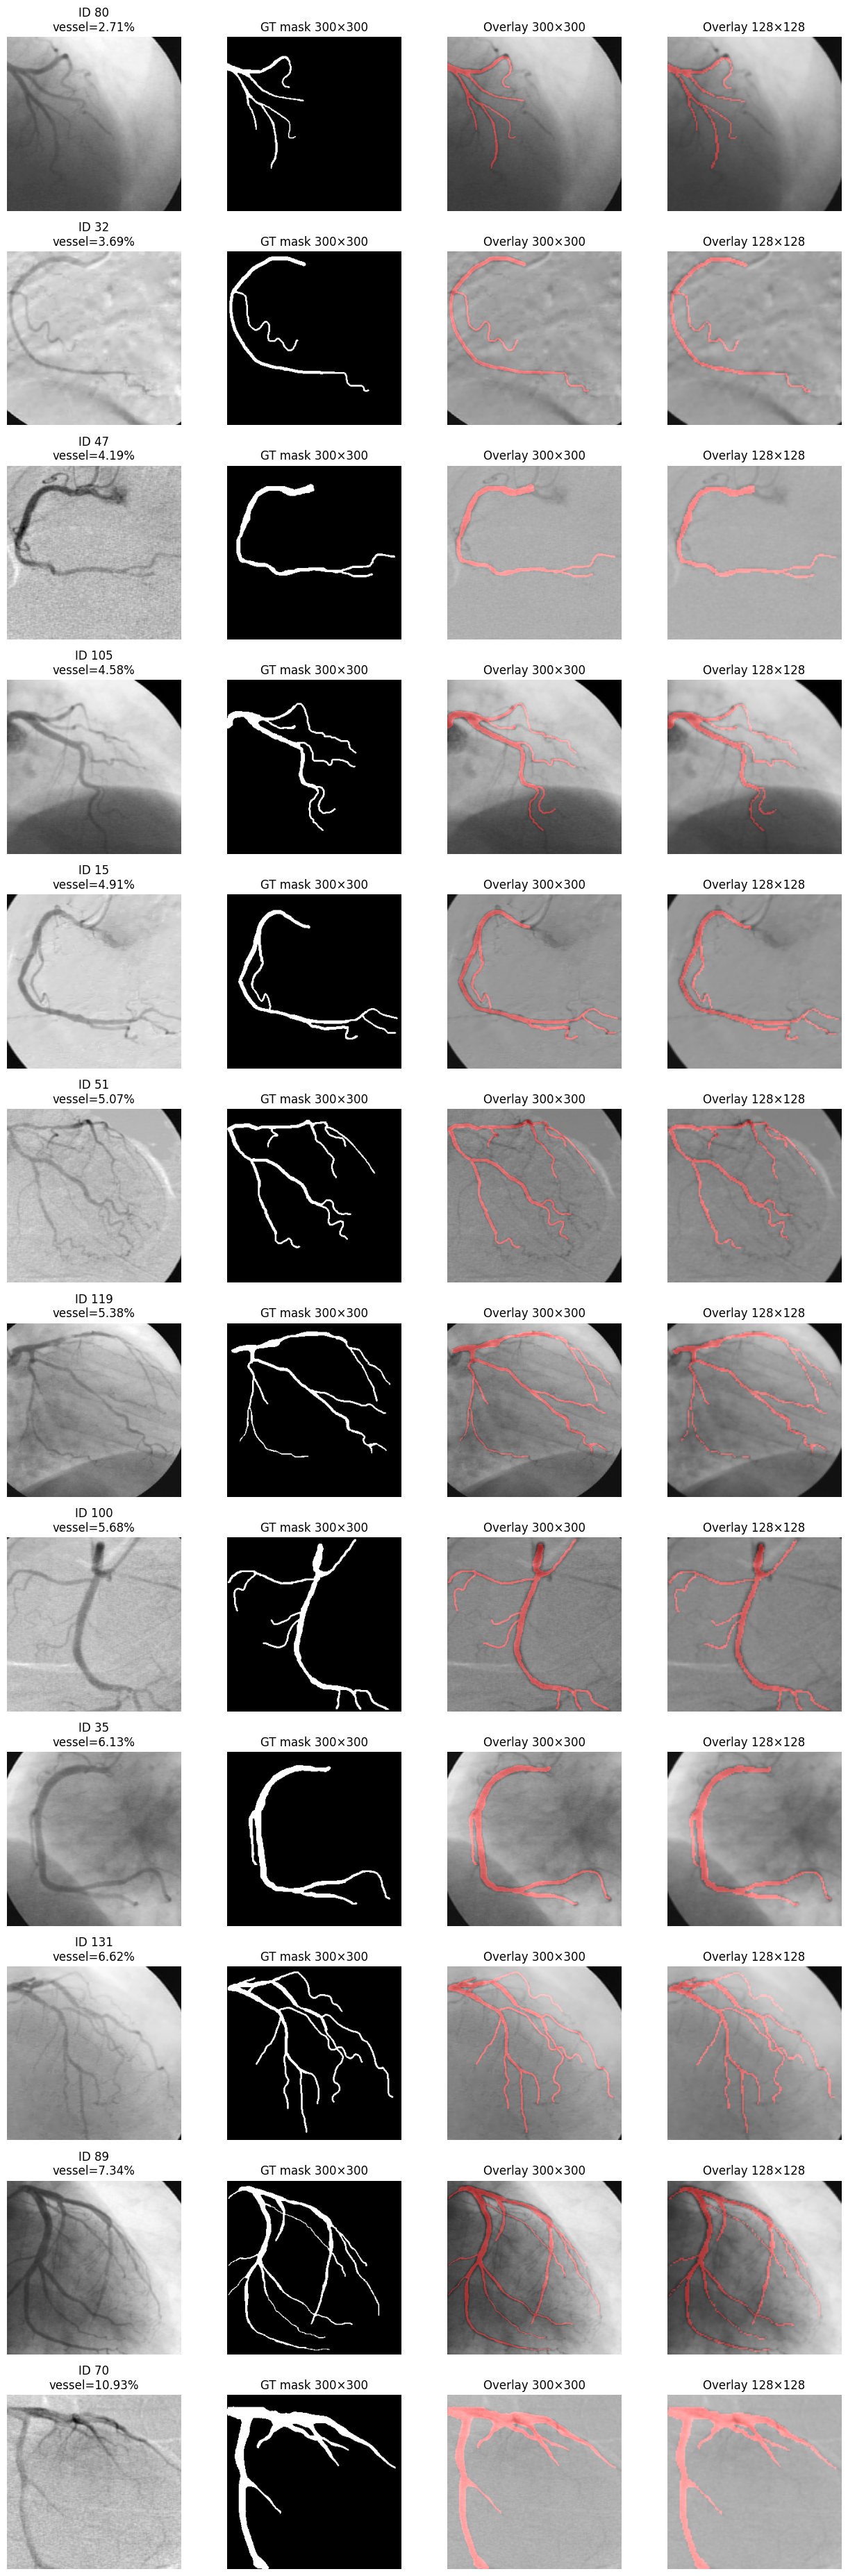

저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/02_dca1_mask_visual_audit.png


In [ ]:
#@title DCA1 마스크 시각 검증

import matplotlib.pyplot as plt
import cv2
import numpy as np

sorted_dca1_df = (
    dca1_manifest_df
    .sort_values("vessel_pixel_rate")
    .reset_index(drop=True)
)

# 혈관 비율 전체 범위에서 12장 선택
visual_positions = np.linspace(
    0,
    len(sorted_dca1_df) - 1,
    12,
    dtype=int,
)

dca1_visual_sample_df = (
    sorted_dca1_df.iloc[
        visual_positions
    ]
    .reset_index(drop=True)
)


def create_mask_overlay(
    image,
    binary_mask,
    alpha=0.45,
):
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_GRAY2RGB,
    )

    color_mask = np.zeros_like(
        image_rgb
    )

    # 혈관을 빨간색으로 표시
    color_mask[
        binary_mask > 0
    ] = [255, 0, 0]

    overlay = cv2.addWeighted(
        image_rgb,
        1.0,
        color_mask,
        alpha,
        0,
    )

    return overlay


n_rows = len(dca1_visual_sample_df)

fig, axes = plt.subplots(
    n_rows,
    4,
    figsize=(13, 3.1 * n_rows),
)

for row_index, row in enumerate(
    dca1_visual_sample_df.itertuples(index=False)
):
    image = cv2.imread(
        row.image_path,
        cv2.IMREAD_GRAYSCALE,
    )

    mask = cv2.imread(
        row.mask_path,
        cv2.IMREAD_GRAYSCALE,
    )

    binary_mask = (
        mask > 0
    ).astype(np.uint8)

    image_128 = cv2.resize(
        image,
        (128, 128),
        interpolation=cv2.INTER_AREA,
    )

    mask_128 = cv2.resize(
        binary_mask,
        (128, 128),
        interpolation=cv2.INTER_NEAREST,
    )

    overlay = create_mask_overlay(
        image,
        binary_mask,
    )

    overlay_128 = create_mask_overlay(
        image_128,
        mask_128,
    )

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
    )
    axes[row_index, 0].set_title(
        f"ID {row.sample_id}\n"
        f"vessel={row.vessel_pixel_rate:.2%}"
    )

    axes[row_index, 1].imshow(
        binary_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 1].set_title(
        "GT mask 300×300"
    )

    axes[row_index, 2].imshow(
        overlay
    )
    axes[row_index, 2].set_title(
        "Overlay 300×300"
    )

    axes[row_index, 3].imshow(
        overlay_128
    )
    axes[row_index, 3].set_title(
        "Overlay 128×128"
    )

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()

DCA1_VISUAL_PATH = (
    DCA1_RESULT_DIR
    / "02_dca1_mask_visual_audit.png"
)

plt.savefig(
    DCA1_VISUAL_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("저장:", DCA1_VISUAL_PATH)

In [ ]:
#@title DCA1 128×128 resize 전체 검사

resize_audit_records = []

for row in dca1_manifest_df.itertuples(
    index=False
):
    image = cv2.imread(
        row.image_path,
        cv2.IMREAD_GRAYSCALE,
    )

    mask = cv2.imread(
        row.mask_path,
        cv2.IMREAD_GRAYSCALE,
    )

    mask_binary = (
        mask > 0
    ).astype(np.uint8)

    image_128 = cv2.resize(
        image,
        (128, 128),
        interpolation=cv2.INTER_AREA,
    )

    mask_128 = cv2.resize(
        mask_binary,
        (128, 128),
        interpolation=cv2.INTER_NEAREST,
    )

    original_component_count = (
        cv2.connectedComponents(
            mask_binary,
            connectivity=8,
        )[0]
        - 1
    )

    resized_component_count = (
        cv2.connectedComponents(
            mask_128,
            connectivity=8,
        )[0]
        - 1
    )

    original_rate = float(
        mask_binary.mean()
    )

    resized_rate = float(
        mask_128.mean()
    )

    resize_audit_records.append({
        "sample_id": row.sample_id,
        "image_shape_valid": (
            image_128.shape == (128, 128)
        ),
        "mask_shape_valid": (
            mask_128.shape == (128, 128)
        ),
        "image_dtype": str(
            image_128.dtype
        ),
        "mask_unique_values": ",".join(
            map(
                str,
                np.unique(mask_128).tolist(),
            )
        ),
        "original_vessel_rate": original_rate,
        "resized_vessel_rate": resized_rate,
        "vessel_rate_relative_change": (
            (resized_rate - original_rate)
            / original_rate
        ),
        "original_component_count": (
            original_component_count
        ),
        "resized_component_count": (
            resized_component_count
        ),
        "empty_mask_after_resize": (
            mask_128.sum() == 0
        ),
        "image_path": row.image_path,
        "mask_path": row.mask_path,
    })

dca1_resize_audit_df = pd.DataFrame(
    resize_audit_records
)

print(
    "축소 후 빈 마스크:",
    dca1_resize_audit_df[
        "empty_mask_after_resize"
    ].sum(),
)

print(
    "비정상 image shape:",
    (
        ~dca1_resize_audit_df[
            "image_shape_valid"
        ]
    ).sum(),
)

print(
    "비정상 mask shape:",
    (
        ~dca1_resize_audit_df[
            "mask_shape_valid"
        ]
    ).sum(),
)

print("\n혈관 비율 상대 변화")

display(
    dca1_resize_audit_df[
        "vessel_rate_relative_change"
    ].describe()
)

print("\nConnected component 변화")

display(
    dca1_resize_audit_df[
        [
            "original_component_count",
            "resized_component_count",
        ]
    ].describe()
)

assert not dca1_resize_audit_df[
    "empty_mask_after_resize"
].any()

assert dca1_resize_audit_df[
    "image_shape_valid"
].all()

assert dca1_resize_audit_df[
    "mask_shape_valid"
].all()

assert dca1_resize_audit_df[
    "mask_unique_values"
].isin(["0,1"]).all()

DCA1_RESIZE_AUDIT_PATH = (
    DCA1_RESULT_DIR
    / "03_dca1_resize_audit.csv"
)

dca1_resize_audit_df.to_csv(
    DCA1_RESIZE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("✅ DCA1 128×128 resize Gate 통과")
print("저장:", DCA1_RESIZE_AUDIT_PATH)

축소 후 빈 마스크: 0
비정상 image shape: 0
비정상 mask shape: 0

혈관 비율 상대 변화


,vessel_rate_relative_change
count,134.000000
mean,0.003589
std,0.012956
min,-0.031535
25%,-0.004660
50%,0.004548
75%,0.012280
max,0.039989



Connected component 변화


,original_component_count,resized_component_count
count,134.000000,134.000000
mean,1.052239,2.634328
std,0.308213,4.360694
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,4.000000,30.000000


✅ DCA1 128×128 resize Gate 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/03_dca1_resize_audit.csv


DCA1 5-fold 생성

</br>DCA1에는 환자 ID가 제공되지 않으므로 AngioCAD처럼 환자 단위 그룹 분할을 할 수 없음. 이 제한은 보고서에 명시할 것

</br>
혈관 면적이 큰 영상과 작은 영상이 각 fold에 골고루 들어가도록 혈관 비율을 5개 구간으로 나눈 뒤 stratification

In [ ]:
#@title DCA1 5-fold segmentation CV

from sklearn.model_selection import (
    StratifiedKFold,
)

DCA1_RANDOM_STATE = 42
DCA1_N_SPLITS = 5

dca1_cv_manifest_df = (
    dca1_manifest_df.copy()
)

# 같은 값이 있어도 균등한 5개 bin을 만들기 위해 rank 사용
vessel_rate_rank = (
    dca1_cv_manifest_df[
        "vessel_pixel_rate"
    ]
    .rank(
        method="first"
    )
)

dca1_cv_manifest_df[
    "vessel_rate_bin"
] = pd.qcut(
    vessel_rate_rank,
    q=5,
    labels=False,
).astype(int)

dca1_cv_manifest_df[
    "cv_fold"
] = -1

skf = StratifiedKFold(
    n_splits=DCA1_N_SPLITS,
    shuffle=True,
    random_state=DCA1_RANDOM_STATE,
)

dummy_x = np.zeros(
    len(dca1_cv_manifest_df)
)

stratification_y = (
    dca1_cv_manifest_df[
        "vessel_rate_bin"
    ].to_numpy()
)

for fold, (_, validation_indices) in enumerate(
    skf.split(
        dummy_x,
        stratification_y,
    )
):
    dca1_cv_manifest_df.loc[
        validation_indices,
        "cv_fold",
    ] = fold

dca1_cv_manifest_df[
    "cv_fold"
] = dca1_cv_manifest_df[
    "cv_fold"
].astype(int)

dca1_cv_distribution_df = (
    dca1_cv_manifest_df.groupby(
        "cv_fold"
    )
    .agg(
        sample_count=(
            "sample_id",
            "size",
        ),
        mean_vessel_rate=(
            "vessel_pixel_rate",
            "mean",
        ),
        std_vessel_rate=(
            "vessel_pixel_rate",
            "std",
        ),
        min_vessel_rate=(
            "vessel_pixel_rate",
            "min",
        ),
        max_vessel_rate=(
            "vessel_pixel_rate",
            "max",
        ),
    )
    .reset_index()
)

display(dca1_cv_distribution_df)

print("\n=== Fold별 vessel-rate bin 분포 ===")

fold_bin_table = pd.crosstab(
    dca1_cv_manifest_df["cv_fold"],
    dca1_cv_manifest_df[
        "vessel_rate_bin"
    ],
)

display(fold_bin_table)

assert len(dca1_cv_manifest_df) == 134
assert set(
    dca1_cv_manifest_df["cv_fold"]
) == {0, 1, 2, 3, 4}

assert (
    dca1_cv_distribution_df[
        "sample_count"
    ].max()
    - dca1_cv_distribution_df[
        "sample_count"
    ].min()
    <= 1
)

assert (fold_bin_table > 0).all().all()

DCA1_CV_MANIFEST_PATH = (
    DCA1_RESULT_DIR
    / "04_dca1_cv_manifest.csv"
)

DCA1_CV_DISTRIBUTION_PATH = (
    DCA1_RESULT_DIR
    / "05_dca1_cv_distribution.csv"
)

dca1_cv_manifest_df.to_csv(
    DCA1_CV_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig",
)

dca1_cv_distribution_df.to_csv(
    DCA1_CV_DISTRIBUTION_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("✅ DCA1 5-fold 생성 완료")
print("저장:", DCA1_CV_MANIFEST_PATH)
print("저장:", DCA1_CV_DISTRIBUTION_PATH)

,cv_fold,sample_count,mean_vessel_rate,std_vessel_rate,min_vessel_rate,max_vessel_rate
0,0,27,0.056149,0.016794,0.032100,0.109322
1,1,27,0.054811,0.014046,0.036167,0.081867
2,2,27,0.053838,0.012319,0.032589,0.083500
3,3,27,0.053792,0.012779,0.027544,0.081100
4,4,26,0.053754,0.015191,0.027067,0.094011



=== Fold별 vessel-rate bin 분포 ===


vessel_rate_bin,0,1,2,3,4
cv_fold,,,,,
0,6,5,5,5,6
1,6,5,5,5,6
2,5,6,5,6,5
3,5,6,5,6,5
4,5,5,6,5,5


✅ DCA1 5-fold 생성 완료
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/04_dca1_cv_manifest.csv
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/05_dca1_cv_distribution.csv


In [ ]:
#@title DCA1 해상도별 혈관 topology 감사

import cv2
import numpy as np
import pandas as pd

RESOLUTION_CANDIDATES = [
    128,
    256,
]

MIN_COMPONENT_FRACTION = 0.0005


def calculate_component_metrics(
    binary_mask,
):
    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)

    height, width = binary_mask.shape

    minimum_significant_area = max(
        1,
        round(
            height
            * width
            * MIN_COMPONENT_FRACTION
        ),
    )

    (
        component_count_with_background,
        component_labels,
        component_stats,
        _,
    ) = cv2.connectedComponentsWithStats(
        binary_mask,
        connectivity=8,
    )

    component_areas = (
        component_stats[
            1:,
            cv2.CC_STAT_AREA,
        ]
    )

    raw_component_count = len(
        component_areas
    )

    if len(component_areas) == 0:
        return {
            "raw_component_count": 0,
            "significant_component_count": 0,
            "tiny_component_count": 0,
            "largest_component_coverage": 0.0,
            "fragment_pixel_rate": 1.0,
            "minimum_significant_area": (
                minimum_significant_area
            ),
        }

    total_vessel_pixels = int(
        component_areas.sum()
    )

    largest_component_area = int(
        component_areas.max()
    )

    significant_component_count = int(
        (
            component_areas
            >= minimum_significant_area
        ).sum()
    )

    tiny_component_count = int(
        (
            component_areas
            < minimum_significant_area
        ).sum()
    )

    largest_component_coverage = (
        largest_component_area
        / total_vessel_pixels
    )

    fragment_pixel_rate = (
        1.0
        - largest_component_coverage
    )

    return {
        "raw_component_count": (
            raw_component_count
        ),
        "significant_component_count": (
            significant_component_count
        ),
        "tiny_component_count": (
            tiny_component_count
        ),
        "largest_component_coverage": (
            largest_component_coverage
        ),
        "fragment_pixel_rate": (
            fragment_pixel_rate
        ),
        "minimum_significant_area": (
            minimum_significant_area
        ),
    }


topology_records = []

for row in dca1_manifest_df.itertuples(
    index=False
):
    original_mask = cv2.imread(
        row.mask_path,
        cv2.IMREAD_GRAYSCALE,
    )

    original_binary = (
        original_mask > 0
    ).astype(np.uint8)

    original_metrics = (
        calculate_component_metrics(
            original_binary
        )
    )

    for resolution in RESOLUTION_CANDIDATES:
        resized_mask = cv2.resize(
            original_binary,
            (
                resolution,
                resolution,
            ),
            interpolation=cv2.INTER_NEAREST,
        )

        resized_metrics = (
            calculate_component_metrics(
                resized_mask
            )
        )

        topology_records.append({
            "sample_id": row.sample_id,
            "resolution": resolution,
            "original_vessel_rate": float(
                original_binary.mean()
            ),
            "resized_vessel_rate": float(
                resized_mask.mean()
            ),
            "vessel_rate_relative_change": (
                (
                    resized_mask.mean()
                    - original_binary.mean()
                )
                / original_binary.mean()
            ),
            "original_raw_component_count": (
                original_metrics[
                    "raw_component_count"
                ]
            ),
            "resized_raw_component_count": (
                resized_metrics[
                    "raw_component_count"
                ]
            ),
            "original_significant_components": (
                original_metrics[
                    "significant_component_count"
                ]
            ),
            "resized_significant_components": (
                resized_metrics[
                    "significant_component_count"
                ]
            ),
            "tiny_component_count": (
                resized_metrics[
                    "tiny_component_count"
                ]
            ),
            "largest_component_coverage": (
                resized_metrics[
                    "largest_component_coverage"
                ]
            ),
            "fragment_pixel_rate": (
                resized_metrics[
                    "fragment_pixel_rate"
                ]
            ),
            "topology_warning": (
                resized_metrics[
                    "significant_component_count"
                ] > 1
                or resized_metrics[
                    "largest_component_coverage"
                ] < 0.95
            ),
        })

dca1_topology_audit_df = pd.DataFrame(
    topology_records
)

topology_summary_df = (
    dca1_topology_audit_df.groupby(
        "resolution"
    )
    .agg(
        sample_count=(
            "sample_id",
            "size",
        ),
        mean_raw_components=(
            "resized_raw_component_count",
            "mean",
        ),
        mean_significant_components=(
            "resized_significant_components",
            "mean",
        ),
        mean_tiny_components=(
            "tiny_component_count",
            "mean",
        ),
        mean_largest_component_coverage=(
            "largest_component_coverage",
            "mean",
        ),
        median_largest_component_coverage=(
            "largest_component_coverage",
            "median",
        ),
        mean_fragment_pixel_rate=(
            "fragment_pixel_rate",
            "mean",
        ),
        topology_warning_count=(
            "topology_warning",
            "sum",
        ),
        mean_vessel_rate_change=(
            "vessel_rate_relative_change",
            "mean",
        ),
    )
    .reset_index()
)

display(topology_summary_df)

print("\n=== 128×128 fragmentation 상위 영상 ===")

worst_128_topology_df = (
    dca1_topology_audit_df.loc[
        dca1_topology_audit_df[
            "resolution"
        ].eq(128)
    ]
    .sort_values(
        "largest_component_coverage",
        ascending=True,
    )
    .head(15)
)

display(worst_128_topology_df)

TOPOLOGY_AUDIT_PATH = (
    DCA1_RESULT_DIR
    / "03B_dca1_resolution_topology_audit.csv"
)

TOPOLOGY_SUMMARY_PATH = (
    DCA1_RESULT_DIR
    / "03C_dca1_resolution_topology_summary.csv"
)

dca1_topology_audit_df.to_csv(
    TOPOLOGY_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

topology_summary_df.to_csv(
    TOPOLOGY_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장:", TOPOLOGY_AUDIT_PATH)
print("저장:", TOPOLOGY_SUMMARY_PATH)

,resolution,sample_count,mean_raw_components,mean_significant_components,mean_tiny_components,mean_largest_component_coverage,median_largest_component_coverage,mean_fragment_pixel_rate,topology_warning_count,mean_vessel_rate_change
0,128,134,2.634328,1.440299,1.19403,0.985443,1.0,0.014557,24,0.003589
1,256,134,1.313433,1.119403,0.19403,0.995783,1.0,0.004217,10,0.001755



=== 128×128 fragmentation 상위 영상 ===


,sample_id,resolution,original_vessel_rate,resized_vessel_rate,vessel_rate_relative_change,original_raw_component_count,resized_raw_component_count,original_significant_components,resized_significant_components,tiny_component_count,largest_component_coverage,fragment_pixel_rate,topology_warning
188,95,128,0.027544,0.027893,0.012657,1,23,1,5,18,0.722101,0.277899,True
176,89,128,0.073367,0.074768,0.019101,1,30,1,5,25,0.880816,0.119184,True
106,54,128,0.032589,0.033447,0.026340,1,10,1,4,6,0.883212,0.116788,True
186,94,128,0.043422,0.043945,0.012047,1,6,1,4,2,0.888889,0.111111,True
236,119,128,0.053844,0.052917,-0.017216,1,12,1,5,7,0.896194,0.103806,True
110,56,128,0.050944,0.051025,0.001589,1,15,1,5,10,0.899522,0.100478,True
86,44,128,0.036467,0.036621,0.004235,1,10,1,4,6,0.910000,0.090000,True
194,98,128,0.037422,0.037964,0.014474,1,9,1,3,6,0.914791,0.085209,True
122,62,128,0.037467,0.037415,-0.001391,1,18,1,2,16,0.915171,0.084829,True
126,64,128,0.055267,0.054443,-0.014897,1,6,1,5,1,0.919283,0.080717,True


저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/03B_dca1_resolution_topology_audit.csv
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/03C_dca1_resolution_topology_summary.csv


# DCA1 5-fold 확정 → Dataset/모델/loss smoke test → 4장 과적합 테스트

In [ ]:
#@title DCA1 5-fold manifest 확인

DCA1_CV_MANIFEST_PATH = (
    DCA1_RESULT_DIR
    / "04_dca1_cv_manifest.csv"
)

assert DCA1_CV_MANIFEST_PATH.exists(), (
    "DCA1 5-fold 생성 셀을 먼저 실행해주세요."
)

dca1_cv_manifest_df = pd.read_csv(
    DCA1_CV_MANIFEST_PATH
)

dca1_cv_manifest_df["cv_fold"] = (
    pd.to_numeric(
        dca1_cv_manifest_df["cv_fold"],
        errors="raise",
    ).astype(int)
)

print("DCA1 rows:", len(dca1_cv_manifest_df))

display(
    dca1_cv_manifest_df[
        "cv_fold"
    ]
    .value_counts()
    .sort_index()
    .rename("sample_count")
    .to_frame()
)

assert len(dca1_cv_manifest_df) == 134
assert set(dca1_cv_manifest_df["cv_fold"]) == {
    0, 1, 2, 3, 4
}

print("✅ DCA1 5-fold manifest 확인 완료")

DCA1 rows: 134


,sample_count
cv_fold,
0,27
1,27
2,27
3,27
4,26


✅ DCA1 5-fold manifest 확인 완료


In [ ]:
#@title PyTorch 환경 및 재현성 설정

import os
import random
import torch
import numpy as np
import pandas as pd

SEED = 42


def set_global_seed(seed):
    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )
else:
    print(
        "⚠️ CPU 런타임입니다. "
        "전체 학습 전 GPU로 변경해야 합니다."
    )

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA 사용 가능: True
GPU: Tesla T4


In [ ]:
#@title 04 DCA1 학습 세션 복구

from google.colab import drive
from pathlib import Path

import zipfile
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold

drive.mount(
    "/content/drive",
    force_remount=False,
)

PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

DCA1_SOURCE_DIR = (
    PROJECT_DIR
    / "external_data"
    / "DCA1"
)

DCA1_RESULT_DIR = (
    PROJECT_DIR
    / "dca1_results"
)

DCA1_ZIP_PATH = (
    DCA1_SOURCE_DIR
    / "DB_Angiograms_134.zip"
)

DCA1_EXTRACT_ROOT = Path(
    "/content/DCA1"
)

DCA1_MANIFEST_PATH = (
    DCA1_RESULT_DIR
    / "01_dca1_manifest.csv"
)

DCA1_CV_MANIFEST_PATH = (
    DCA1_RESULT_DIR
    / "04_dca1_cv_manifest.csv"
)

assert DCA1_ZIP_PATH.exists(), (
    f"DCA1 ZIP이 없습니다: {DCA1_ZIP_PATH}"
)

assert DCA1_MANIFEST_PATH.exists(), (
    f"DCA1 manifest가 없습니다: {DCA1_MANIFEST_PATH}"
)

# ---------------------------------------------------------
# Colab 로컬 데이터가 사라졌다면 ZIP만 재해제
# ---------------------------------------------------------
current_pgm_count = len(
    list(
        DCA1_EXTRACT_ROOT.rglob("*.pgm")
    )
)

if current_pgm_count != 268:
    print(
        "DCA1 로컬 파일이 없어 압축을 다시 풉니다."
    )

    DCA1_EXTRACT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(
        DCA1_ZIP_PATH,
        "r",
    ) as zip_file:
        zip_file.extractall(
            DCA1_EXTRACT_ROOT
        )

current_pgm_count = len(
    list(
        DCA1_EXTRACT_ROOT.rglob("*.pgm")
    )
)

assert current_pgm_count == 268

print("DCA1 PGM:", current_pgm_count)

# ---------------------------------------------------------
# 기존 CV manifest가 있으면 불러오기
# ---------------------------------------------------------
if DCA1_CV_MANIFEST_PATH.exists():
    dca1_cv_manifest_df = pd.read_csv(
        DCA1_CV_MANIFEST_PATH
    )

    print("기존 5-fold manifest를 불러왔습니다.")

else:
    # 없으면 저장된 DCA1 manifest로 재생성
    dca1_manifest_df = pd.read_csv(
        DCA1_MANIFEST_PATH
    )

    dca1_cv_manifest_df = (
        dca1_manifest_df.copy()
    )

    vessel_rate_rank = (
        dca1_cv_manifest_df[
            "vessel_pixel_rate"
        ]
        .rank(method="first")
    )

    dca1_cv_manifest_df[
        "vessel_rate_bin"
    ] = pd.qcut(
        vessel_rate_rank,
        q=5,
        labels=False,
    ).astype(int)

    dca1_cv_manifest_df[
        "cv_fold"
    ] = -1

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    dummy_x = np.zeros(
        len(dca1_cv_manifest_df)
    )

    for fold, (_, validation_indices) in enumerate(
        skf.split(
            dummy_x,
            dca1_cv_manifest_df[
                "vessel_rate_bin"
            ],
        )
    ):
        dca1_cv_manifest_df.loc[
            validation_indices,
            "cv_fold",
        ] = fold

    dca1_cv_manifest_df.to_csv(
        DCA1_CV_MANIFEST_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    print("5-fold manifest를 새로 생성했습니다.")

# ---------------------------------------------------------
# 자료형 및 경로 검증
# ---------------------------------------------------------
dca1_cv_manifest_df["cv_fold"] = (
    pd.to_numeric(
        dca1_cv_manifest_df["cv_fold"],
        errors="raise",
    ).astype(int)
)

missing_image_count = (
    ~dca1_cv_manifest_df[
        "image_path"
    ].map(lambda path: Path(path).exists())
).sum()

missing_mask_count = (
    ~dca1_cv_manifest_df[
        "mask_path"
    ].map(lambda path: Path(path).exists())
).sum()

print("\nFold 분포")

display(
    dca1_cv_manifest_df[
        "cv_fold"
    ]
    .value_counts()
    .sort_index()
    .rename("sample_count")
    .to_frame()
)

print("없는 image path:", missing_image_count)
print("없는 mask path:", missing_mask_count)

assert len(dca1_cv_manifest_df) == 134
assert set(
    dca1_cv_manifest_df["cv_fold"]
) == {0, 1, 2, 3, 4}

assert missing_image_count == 0
assert missing_mask_count == 0

print("\n✅ DCA1 학습 세션 복구 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DCA1 PGM: 268
기존 5-fold manifest를 불러왔습니다.

Fold 분포


,sample_count
cv_fold,
0,27
1,27
2,27
3,27
4,26


없는 image path: 0
없는 mask path: 0

✅ DCA1 학습 세션 복구 완료


In [ ]:
#@title DCA1 Dataset 클래스

#@title DCA1 PyTorch Dataset

import cv2

from torch.utils.data import (
    Dataset,
    DataLoader,
)


class DCA1SegmentationDataset(Dataset):
    def __init__(
        self,
        dataframe,
        resolution,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.resolution = int(resolution)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        mask_path = Path(row["mask_path"])

        if not image_path.exists():
            raise FileNotFoundError(
                f"DCA1 image 없음: {image_path}"
            )

        if not mask_path.exists():
            raise FileNotFoundError(
                f"DCA1 mask 없음: {mask_path}"
            )

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE,
        )

        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE,
        )

        if image is None or mask is None:
            raise ValueError(
                f"DCA1 읽기 실패: {row['sample_id']}"
            )

        image = cv2.resize(
            image,
            (
                self.resolution,
                self.resolution,
            ),
            interpolation=cv2.INTER_AREA,
        )

        mask = cv2.resize(
            (mask > 0).astype(np.uint8),
            (
                self.resolution,
                self.resolution,
            ),
            interpolation=cv2.INTER_NEAREST,
        )

        image = (
            image.astype(np.float32)
            / 255.0
        )

        mask = mask.astype(np.float32)

        # [H,W] → [1,H,W]
        image_tensor = torch.from_numpy(
            image[None, ...]
        )

        mask_tensor = torch.from_numpy(
            mask[None, ...]
        )

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "sample_id": str(
                row["sample_id"]
            ),
        }

In [ ]:
#@title Fold 0 DataLoader 검증

#@title Fold 0 DataLoader 검증

VALIDATION_FOLD = 0
SMOKE_RESOLUTION = 128

fold0_train_df = (
    dca1_cv_manifest_df.loc[
        dca1_cv_manifest_df[
            "cv_fold"
        ].ne(VALIDATION_FOLD)
    ]
    .reset_index(drop=True)
)

fold0_validation_df = (
    dca1_cv_manifest_df.loc[
        dca1_cv_manifest_df[
            "cv_fold"
        ].eq(VALIDATION_FOLD)
    ]
    .reset_index(drop=True)
)

train_dataset = DCA1SegmentationDataset(
    fold0_train_df,
    resolution=SMOKE_RESOLUTION,
)

validation_dataset = (
    DCA1SegmentationDataset(
        fold0_validation_df,
        resolution=SMOKE_RESOLUTION,
    )
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]

print("Train samples:", len(train_dataset))
print(
    "Validation samples:",
    len(validation_dataset),
)
print("Image batch:", images.shape)
print("Mask batch:", masks.shape)
print(
    "Image range:",
    float(images.min()),
    float(images.max()),
)
print(
    "Mask unique:",
    torch.unique(masks),
)

assert images.shape == (
    8, 1, 128, 128
)

assert masks.shape == (
    8, 1, 128, 128
)

assert images.dtype == torch.float32
assert masks.dtype == torch.float32
assert torch.isfinite(images).all()
assert torch.isfinite(masks).all()

assert set(
    torch.unique(masks).tolist()
).issubset({0.0, 1.0})

print("✅ Fold 0 DataLoader 검증 통과")

Train samples: 107
Validation samples: 27
Image batch: torch.Size([8, 1, 128, 128])
Mask batch: torch.Size([8, 1, 128, 128])
Image range: 0.0 0.9607843160629272
Mask unique: tensor([0., 1.])
✅ Fold 0 DataLoader 검증 통과


In [ ]:
#@title Standard U-Net 정의

import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=32,
    ):
        super().__init__()

        c1 = base_channels
        c2 = c1 * 2
        c3 = c2 * 2
        c4 = c3 * 2
        c5 = c4 * 2

        self.encoder1 = DoubleConv(
            in_channels,
            c1,
        )
        self.encoder2 = DoubleConv(c1, c2)
        self.encoder3 = DoubleConv(c2, c3)
        self.encoder4 = DoubleConv(c3, c4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(
            c4,
            c5,
        )

        self.up4 = nn.ConvTranspose2d(
            c5,
            c4,
            kernel_size=2,
            stride=2,
        )
        self.decoder4 = DoubleConv(
            c4 + c4,
            c4,
        )

        self.up3 = nn.ConvTranspose2d(
            c4,
            c3,
            kernel_size=2,
            stride=2,
        )
        self.decoder3 = DoubleConv(
            c3 + c3,
            c3,
        )

        self.up2 = nn.ConvTranspose2d(
            c3,
            c2,
            kernel_size=2,
            stride=2,
        )
        self.decoder2 = DoubleConv(
            c2 + c2,
            c2,
        )

        self.up1 = nn.ConvTranspose2d(
            c2,
            c1,
            kernel_size=2,
            stride=2,
        )
        self.decoder1 = DoubleConv(
            c1 + c1,
            c1,
        )

        self.output = nn.Conv2d(
            c1,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        e1 = self.encoder1(x)

        e2 = self.encoder2(
            self.pool(e1)
        )

        e3 = self.encoder3(
            self.pool(e2)
        )

        e4 = self.encoder4(
            self.pool(e3)
        )

        bottleneck = self.bottleneck(
            self.pool(e4)
        )

        d4 = self.up4(bottleneck)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.decoder4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.decoder3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.decoder2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.decoder1(d1)

        return self.output(d1)

In [ ]:
#@title Focal Tversky와 segmentation metric

class FocalTverskyLoss(nn.Module):
    def __init__(
        self,
        alpha=0.3,
        beta=0.7,
        gamma=0.75,
        smooth=1e-6,
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(
        self,
        logits,
        targets,
    ):
        probabilities = torch.sigmoid(
            logits
        )

        dimensions = (1, 2, 3)

        true_positive = torch.sum(
            probabilities * targets,
            dim=dimensions,
        )

        false_positive = torch.sum(
            probabilities * (1 - targets),
            dim=dimensions,
        )

        false_negative = torch.sum(
            (1 - probabilities) * targets,
            dim=dimensions,
        )

        tversky_index = (
            true_positive + self.smooth
        ) / (
            true_positive
            + self.alpha * false_positive
            + self.beta * false_negative
            + self.smooth
        )

        loss = torch.pow(
            1 - tversky_index,
            self.gamma,
        )

        return loss.mean()


@torch.no_grad()
def calculate_segmentation_metrics(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6,
):
    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= threshold
    ).float()

    dimensions = (1, 2, 3)

    tp = torch.sum(
        predictions * targets,
        dim=dimensions,
    )

    fp = torch.sum(
        predictions * (1 - targets),
        dim=dimensions,
    )

    fn = torch.sum(
        (1 - predictions) * targets,
        dim=dimensions,
    )

    tn = torch.sum(
        (1 - predictions)
        * (1 - targets),
        dim=dimensions,
    )

    dice = (
        2 * tp + smooth
    ) / (
        2 * tp + fp + fn + smooth
    )

    iou = (
        tp + smooth
    ) / (
        tp + fp + fn + smooth
    )

    precision = (
        tp + smooth
    ) / (
        tp + fp + smooth
    )

    recall = (
        tp + smooth
    ) / (
        tp + fn + smooth
    )

    specificity = (
        tn + smooth
    ) / (
        tn + fp + smooth
    )

    return {
        "dice": float(dice.mean()),
        "iou": float(iou.mean()),
        "precision": float(
            precision.mean()
        ),
        "recall": float(recall.mean()),
        "specificity": float(
            specificity.mean()
        ),
    }

In [ ]:
#@title U-Net forward/backward smoke test

model = UNet(
    in_channels=1,
    out_channels=1,
    base_channels=32,
).to(DEVICE)

criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

images_device = images.to(DEVICE)
masks_device = masks.to(DEVICE)

model.train()

logits = model(images_device)
loss = criterion(
    logits,
    masks_device,
)

loss.backward()

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

gradient_finite = all(
    parameter.grad is None
    or torch.isfinite(
        parameter.grad
    ).all()
    for parameter in model.parameters()
)

print("Logits shape:", logits.shape)
print("Initial loss:", float(loss))
print(
    "Parameters:",
    f"{parameter_count:,}",
)
print("Gradient finite:", gradient_finite)

assert logits.shape == masks_device.shape
assert torch.isfinite(logits).all()
assert torch.isfinite(loss)
assert gradient_finite

print("✅ U-Net forward/backward 검증 통과")

Logits shape: torch.Size([8, 1, 128, 128])
Initial loss: 0.8882213234901428
Parameters: 7,762,465
Gradient finite: True
✅ U-Net forward/backward 검증 통과


/tmp/ipykernel_1160/4071737778.py:42: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Initial loss:", float(loss))


In [ ]:
#@title 4장 과적합 테스트

set_global_seed(SEED)

tiny_df = (
    fold0_train_df
    .head(4)
    .reset_index(drop=True)
)

tiny_dataset = DCA1SegmentationDataset(
    tiny_df,
    resolution=128,
)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

tiny_batch = next(
    iter(tiny_loader)
)

tiny_images = tiny_batch[
    "image"
].to(DEVICE)

tiny_masks = tiny_batch[
    "mask"
].to(DEVICE)

tiny_model = UNet(
    in_channels=1,
    out_channels=1,
    base_channels=32,
).to(DEVICE)

tiny_criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

tiny_optimizer = torch.optim.Adam(
    tiny_model.parameters(),
    lr=1e-3,
)

initial_loss = None

for step in range(200):
    tiny_model.train()

    tiny_optimizer.zero_grad(
        set_to_none=True
    )

    tiny_logits = tiny_model(
        tiny_images
    )

    tiny_loss = tiny_criterion(
        tiny_logits,
        tiny_masks,
    )

    tiny_loss.backward()
    tiny_optimizer.step()

    if initial_loss is None:
        initial_loss = float(tiny_loss)

    if (step + 1) % 50 == 0:
        print(
            f"step={step + 1:03d}, "
            f"loss={float(tiny_loss):.6f}"
        )

tiny_model.eval()

with torch.no_grad():
    final_logits = tiny_model(
        tiny_images
    )

    final_loss = float(
        tiny_criterion(
            final_logits,
            tiny_masks,
        )
    )

    tiny_metrics = (
        calculate_segmentation_metrics(
            final_logits,
            tiny_masks,
            threshold=0.5,
        )
    )

print("\nInitial loss:", initial_loss)
print("Final loss:", final_loss)
print("Tiny metrics:", tiny_metrics)

assert np.isfinite(final_loss)
assert final_loss < initial_loss

if tiny_metrics["dice"] >= 0.70:
    print("✅ 4장 과적합 테스트 통과")
else:
    print(
        "⚠️ Dice가 0.70 미만입니다. "
        "전체 학습 전에 결과를 확인해야 합니다."
    )

step=050, loss=0.764363
step=100, loss=0.683335
step=150, loss=0.562587
step=200, loss=0.390299

Initial loss: 0.9037797451019287
Final loss: 0.7641113996505737
Tiny metrics: {'dice': 0.5653960108757019, 'iou': 0.41118156909942627, 'precision': 0.41922444105148315, 'recall': 0.9651533365249634, 'specificity': 0.9141560196876526}
⚠️ Dice가 0.70 미만입니다. 전체 학습 전에 결과를 확인해야 합니다.


In [ ]:
#@title Tiny overfit 재검증 — 고정 4장, stale logits 방지

import copy
import numpy as np
import pandas as pd
import torch

# 실행 장치 복구
if "device" not in globals():
    if "DEVICE" in globals():
        device = torch.device(DEVICE)
    else:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

print("사용 장치:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ CUDA를 사용할 수 없어 CPU로 실행됩니다.")

# Dataset에서 4개 샘플을 한 번만 읽어서 고정
tiny_samples = [
    tiny_source_dataset[index]
    for index in range(4)
]

print("Sample type:", type(tiny_samples[0]))

if isinstance(tiny_samples[0], dict):
    print("Sample keys:", tiny_samples[0].keys())


def extract_image_and_mask(sample):
    """tuple/list 또는 dict 형식 Dataset을 모두 지원합니다."""

    if isinstance(sample, dict):
        if "image" not in sample:
            raise KeyError(
                f"'image' key가 없습니다. 현재 keys: {list(sample.keys())}"
            )

        if "mask" not in sample:
            raise KeyError(
                f"'mask' key가 없습니다. 현재 keys: {list(sample.keys())}"
            )

        image = sample["image"]
        mask = sample["mask"]

    elif isinstance(sample, (tuple, list)):
        if len(sample) < 2:
            raise ValueError(
                f"Dataset 반환값 길이가 2 미만입니다: {len(sample)}"
            )

        image = sample[0]
        mask = sample[1]

    else:
        raise TypeError(
            f"지원하지 않는 Dataset 반환 형식: {type(sample)}"
        )

    # numpy 배열이면 Tensor로 변환
    if not torch.is_tensor(image):
        image = torch.as_tensor(image)

    if not torch.is_tensor(mask):
        mask = torch.as_tensor(mask)

    # [H, W] → [1, H, W]
    if image.ndim == 2:
        image = image.unsqueeze(0)

    if mask.ndim == 2:
        mask = mask.unsqueeze(0)

    image = image.float()
    mask = mask.float()

    return image, mask


tiny_pairs = [
    extract_image_and_mask(sample)
    for sample in tiny_samples
]

tiny_images = torch.stack(
    [image for image, _ in tiny_pairs]
).to(device)

tiny_masks = torch.stack(
    [mask for _, mask in tiny_pairs]
).to(device)

print("Tiny images:", tiny_images.shape)
print("Tiny masks:", tiny_masks.shape)
print(
    "Image range:",
    tiny_images.min().item(),
    tiny_images.max().item(),
)
print("Mask unique:", torch.unique(tiny_masks))

assert tiny_images.shape == (4, 1, 128, 128), (
    f"비정상 image shape: {tiny_images.shape}"
)

assert tiny_masks.shape == (4, 1, 128, 128), (
    f"비정상 mask shape: {tiny_masks.shape}"
)

assert set(
    torch.unique(tiny_masks).detach().cpu().tolist()
).issubset({0.0, 1.0}), "마스크가 이진 값이 아닙니다."

print("✅ Tiny overfit 고정 샘플 생성 완료")

# --------------------------------------------------
# 2. 검증을 통과했던 U-Net을 독립적으로 복사
# --------------------------------------------------
if "model" not in globals():
    raise NameError(
        "model이 없습니다. U-Net 생성 셀부터 다시 실행하세요."
    )

tiny_model = copy.deepcopy(model).to(device)
tiny_model.zero_grad(set_to_none=True)

tiny_loss_fn = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

tiny_optimizer = torch.optim.Adam(
    tiny_model.parameters(),
    lr=1e-3,
)


# --------------------------------------------------
# 3. 지표 함수
# --------------------------------------------------
def calculate_binary_metrics(
    probabilities,
    targets,
    threshold=0.5,
    eps=1e-7,
):
    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    tp = (predictions * targets).sum()
    fp = (predictions * (1 - targets)).sum()
    fn = ((1 - predictions) * targets).sum()
    tn = ((1 - predictions) * (1 - targets)).sum()

    dice = (2 * tp + eps) / (
        2 * tp + fp + fn + eps
    )
    iou = (tp + eps) / (
        tp + fp + fn + eps
    )
    precision = (tp + eps) / (
        tp + fp + eps
    )
    recall = (tp + eps) / (
        tp + fn + eps
    )
    specificity = (tn + eps) / (
        tn + fp + eps
    )

    return {
        "dice": dice.detach().item(),
        "iou": iou.detach().item(),
        "precision": precision.detach().item(),
        "recall": recall.detach().item(),
        "specificity": specificity.detach().item(),
    }


# --------------------------------------------------
# 4. 학습 전 평가
# --------------------------------------------------
tiny_model.eval()

with torch.no_grad():
    initial_logits = tiny_model(tiny_images)
    initial_loss = tiny_loss_fn(
        initial_logits,
        tiny_masks,
    ).detach().item()

print(f"Initial loss: {initial_loss:.6f}")


# --------------------------------------------------
# 5. 고정된 4장 반복 학습
# --------------------------------------------------
history = []
max_steps = 1000

for step in range(1, max_steps + 1):
    tiny_model.train()

    tiny_optimizer.zero_grad(set_to_none=True)

    logits = tiny_model(tiny_images)
    loss = tiny_loss_fn(logits, tiny_masks)

    loss.backward()
    tiny_optimizer.step()

    if step % 50 == 0 or step == 1:
        # 반드시 업데이트 후 logits를 새로 계산
        tiny_model.eval()

        with torch.no_grad():
            evaluation_logits = tiny_model(tiny_images)
            evaluation_loss = tiny_loss_fn(
                evaluation_logits,
                tiny_masks,
            ).detach().item()

            evaluation_probabilities = torch.sigmoid(
                evaluation_logits
            )

            metrics = calculate_binary_metrics(
                evaluation_probabilities,
                tiny_masks,
                threshold=0.5,
            )

        history.append({
            "step": step,
            "loss": evaluation_loss,
            **metrics,
        })

        print(
            f"step={step:04d} "
            f"loss={evaluation_loss:.6f} "
            f"dice={metrics['dice']:.4f} "
            f"precision={metrics['precision']:.4f} "
            f"recall={metrics['recall']:.4f}"
        )

        # 충분한 overfit에 도달하면 조기 종료
        if step >= 200 and metrics["dice"] >= 0.90:
            print("Tiny overfit 조기 종료 조건에 도달했습니다.")
            break


# --------------------------------------------------
# 6. 최종 결과 — 현재 모델의 logits를 다시 계산
# --------------------------------------------------
tiny_model.eval()

with torch.no_grad():
    final_logits = tiny_model(tiny_images)
    final_probabilities = torch.sigmoid(final_logits)

    final_loss = tiny_loss_fn(
        final_logits,
        tiny_masks,
    ).detach().item()

final_metrics = calculate_binary_metrics(
    final_probabilities,
    tiny_masks,
    threshold=0.5,
)

print("\n=== Tiny overfit 최종 결과 ===")
print("Initial loss:", initial_loss)
print("Final loss:", final_loss)
print("Threshold 0.5 metrics:", final_metrics)


# --------------------------------------------------
# 7. Threshold sweep — 원인 진단용
# 최종 모델 threshold를 여기서 결정하면 안 됨
# --------------------------------------------------
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    metrics = calculate_binary_metrics(
        final_probabilities,
        tiny_masks,
        threshold=float(threshold),
    )

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        **metrics,
    })

threshold_audit_df = pd.DataFrame(threshold_rows)

best_threshold_row = (
    threshold_audit_df
    .sort_values(
        ["dice", "iou"],
        ascending=False,
    )
    .iloc[0]
)

print("\n=== Tiny sample threshold 진단 ===")
display(
    threshold_audit_df.sort_values(
        "dice",
        ascending=False,
    ).head(10)
)

print(
    "진단상 최고 threshold:",
    best_threshold_row["threshold"],
)
print(
    "진단상 최고 Dice:",
    best_threshold_row["dice"],
)


# --------------------------------------------------
# 8. Gate 판정
# --------------------------------------------------
fixed_dice = final_metrics["dice"]
best_dice = float(best_threshold_row["dice"])

if fixed_dice >= 0.70:
    gate_status = "PASS"
    print(
        "\n✅ Tiny overfit Gate 통과:",
        f"threshold 0.5 Dice={fixed_dice:.4f}",
    )

elif best_dice >= 0.70:
    gate_status = "PASS_WITH_THRESHOLD_WARNING"
    print(
        "\n⚠️ 학습 능력은 확인됐지만 출력 calibration 검토 필요:",
        f"threshold 0.5 Dice={fixed_dice:.4f},",
        f"best Dice={best_dice:.4f}",
    )

else:
    gate_status = "FAIL"
    print(
        "\n❌ Tiny overfit Gate 미통과:",
        "전체 5-fold 학습을 시작하지 않습니다."
    )


# --------------------------------------------------
# 9. 감사 결과 저장
# --------------------------------------------------
tiny_overfit_history_df = pd.DataFrame(history)

tiny_overfit_history_df["gate_status"] = gate_status
tiny_overfit_history_df["initial_loss"] = initial_loss
tiny_overfit_history_df["final_loss"] = final_loss
tiny_overfit_history_df["best_threshold"] = float(
    best_threshold_row["threshold"]
)
tiny_overfit_history_df["best_threshold_dice"] = best_dice

history_path = (
    DCA1_RESULT_DIR
    / "06_dca1_tiny_overfit_audit.csv"
)

threshold_path = (
    DCA1_RESULT_DIR
    / "07_dca1_tiny_overfit_threshold_audit.csv"
)

tiny_overfit_history_df.to_csv(
    history_path,
    index=False,
)

threshold_audit_df.to_csv(
    threshold_path,
    index=False,
)

print("\n저장 완료:")
print(history_path)
print(threshold_path)

사용 장치: cuda
GPU: Tesla T4
Sample type: <class 'dict'>
Sample keys: dict_keys(['image', 'mask', 'sample_id'])
Tiny images: torch.Size([4, 1, 128, 128])
Tiny masks: torch.Size([4, 1, 128, 128])
Image range: 0.027450980618596077 0.95686274766922
Mask unique: tensor([0., 1.], device='cuda:0')
✅ Tiny overfit 고정 샘플 생성 완료
Initial loss: 0.908080
step=0001 loss=0.907951 dice=0.0000 precision=1.0000 recall=0.0000
step=0050 loss=0.841292 dice=0.5412 precision=0.6954 recall=0.4429
step=0100 loss=0.662672 dice=0.8607 precision=0.7555 recall=1.0000
step=0150 loss=0.741655 dice=0.2708 precision=0.1578 recall=0.9533
step=0200 loss=0.381281 dice=0.9835 precision=0.9675 recall=1.0000
Tiny overfit 조기 종료 조건에 도달했습니다.

=== Tiny overfit 최종 결과 ===
Initial loss: 0.9080798625946045
Final loss: 0.3812810182571411
Threshold 0.5 metrics: {'dice': 0.9835062026977539, 'iou': 0.9675476551055908, 'precision': 0.9675476551055908, 'recall': 1.0, 'specificity': 0.9984515905380249}

=== Tiny sample threshold 진단 ===


,threshold,dice,iou,precision,recall,specificity
16,0.90,0.983673,0.967871,0.967871,1.0,0.998468
15,0.85,0.983673,0.967871,0.967871,1.0,0.998468
14,0.80,0.983673,0.967871,0.967871,1.0,0.998468
12,0.70,0.983506,0.967548,0.967548,1.0,0.998452
4,0.30,0.983506,0.967548,0.967548,1.0,0.998452
8,0.50,0.983506,0.967548,0.967548,1.0,0.998452
7,0.45,0.983506,0.967548,0.967548,1.0,0.998452
6,0.40,0.983506,0.967548,0.967548,1.0,0.998452
5,0.35,0.983506,0.967548,0.967548,1.0,0.998452
13,0.75,0.983506,0.967548,0.967548,1.0,0.998452


진단상 최고 threshold: 0.8
진단상 최고 Dice: 0.9836734533309937

✅ Tiny overfit Gate 통과: threshold 0.5 Dice=0.9835

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/06_dca1_tiny_overfit_audit.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/07_dca1_tiny_overfit_threshold_audit.csv


In [ ]:
#@title U-Net-128 Fold 0 Pilot Training — resume 지원

import copy
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader


# ==================================================
# 1. 실험 설정
# ==================================================
PILOT_CONFIG = {
    "experiment": "UNET128_FOLD0_PILOT",
    "seed": 42,
    "fold": 0,
    "image_size": 128,
    "batch_size": 8,
    "learning_rate": 1e-4,
    "weight_decay": 0.0,
    "max_epochs": 100,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 1e-4,
    "monitor": "validation_loss",
    "monitoring_threshold": 0.5,
    "augmentation": False,
    "loss": "FocalTverskyLoss",
    "loss_alpha": 0.3,
    "loss_beta": 0.7,
    "loss_gamma": 0.75,
}

RESUME_PILOT = True


# ==================================================
# 2. 실행 환경 복구
# ==================================================
if "device" not in globals():
    if "DEVICE" in globals():
        device = torch.device(DEVICE)
    else:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

if "DCA1_RESULT_DIR" not in globals():
    PROJECT_DIR = Path(
        "/content/drive/MyDrive/"
        "[MacGyver]최종프로젝트/"
        "03_data/AngioCAD"
    )
    DCA1_RESULT_DIR = PROJECT_DIR / "dca1_results"

DCA1_RESULT_DIR = Path(DCA1_RESULT_DIR)

PILOT_DIR = (
    DCA1_RESULT_DIR
    / "unet128_fold0_pilot"
)
PILOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONFIG_PATH = (
    PILOT_DIR
    / "01_unet128_fold0_pilot_config.json"
)
HISTORY_PATH = (
    PILOT_DIR
    / "02_unet128_fold0_pilot_history.csv"
)
BEST_CHECKPOINT_PATH = (
    PILOT_DIR
    / "03_unet128_fold0_pilot_best.pt"
)
LAST_CHECKPOINT_PATH = (
    PILOT_DIR
    / "04_unet128_fold0_pilot_last.pt"
)

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        PILOT_CONFIG,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Device:", device)
print("Pilot directory:", PILOT_DIR)


# ==================================================
# 3. 재현성 설정
# ==================================================
def set_reproducibility(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_reproducibility(
    PILOT_CONFIG["seed"]
)


# ==================================================
# 4. Fold 0 Dataset 자동 탐색
# ==================================================
def is_segmentation_dataset(dataset):
    try:
        if len(dataset) == 0:
            return False

        sample = dataset[0]

        if isinstance(sample, dict):
            return (
                "image" in sample
                and "mask" in sample
            )

        if isinstance(sample, (tuple, list)):
            return len(sample) >= 2

        return False

    except Exception:
        return False


def find_dataset_by_size(
    expected_size,
    preferred_role,
):
    candidates = []
    checked_object_ids = set()

    # 1. 현재 세션의 모든 DataLoader 안 Dataset 검사
    for variable_name, variable_value in list(
        globals().items()
    ):
        if isinstance(
            variable_value,
            DataLoader,
        ):
            dataset = variable_value.dataset

            if id(dataset) in checked_object_ids:
                continue

            checked_object_ids.add(id(dataset))

            if (
                len(dataset) == expected_size
                and is_segmentation_dataset(dataset)
            ):
                candidates.append({
                    "name": (
                        f"{variable_name}.dataset"
                    ),
                    "dataset": dataset,
                })

    # 2. Dataset 이름을 가진 일반 변수 검사
    for variable_name, variable_value in list(
        globals().items()
    ):
        if "dataset" not in variable_name.lower():
            continue

        if id(variable_value) in checked_object_ids:
            continue

        if isinstance(
            variable_value,
            DataLoader,
        ):
            continue

        try:
            dataset_size = len(variable_value)
        except Exception:
            continue

        if (
            dataset_size == expected_size
            and is_segmentation_dataset(
                variable_value
            )
        ):
            checked_object_ids.add(
                id(variable_value)
            )

            candidates.append({
                "name": variable_name,
                "dataset": variable_value,
            })

    if not candidates:
        available_dataset_names = [
            name
            for name in globals()
            if (
                "dataset" in name.lower()
                or "loader" in name.lower()
            )
        ]

        raise NameError(
            f"{preferred_role} Dataset "
            f"({expected_size}장)을 찾지 못했습니다.\n"
            f"현재 관련 변수: "
            f"{available_dataset_names}"
        )

    # 변수명에 train/val이 포함된 후보 우선
    if preferred_role == "TRAIN":
        preferred_words = [
            "fold0_train",
            "train",
        ]
    else:
        preferred_words = [
            "fold0_val",
            "fold0_valid",
            "fold0_validation",
            "validation",
            "valid",
            "val",
        ]

    def candidate_priority(candidate):
        candidate_name = (
            candidate["name"].lower()
        )

        for priority, word in enumerate(
            preferred_words
        ):
            if word in candidate_name:
                return priority

        return len(preferred_words)

    candidates = sorted(
        candidates,
        key=candidate_priority,
    )

    selected = candidates[0]

    print(
        f"{preferred_role} Dataset 선택:",
        selected["name"],
        f"({len(selected['dataset'])}장)",
    )

    if len(candidates) > 1:
        print(
            f"{preferred_role} 후보:",
            [
                candidate["name"]
                for candidate in candidates
            ],
        )

    return selected["dataset"]


pilot_train_dataset = find_dataset_by_size(
    expected_size=107,
    preferred_role="TRAIN",
)

pilot_val_dataset = find_dataset_by_size(
    expected_size=27,
    preferred_role="VALIDATION",
)

assert len(pilot_train_dataset) == 107
assert len(pilot_val_dataset) == 27

# train/validation이 같은 객체가 아닌지 확인
assert (
    id(pilot_train_dataset)
    != id(pilot_val_dataset)
), "Train과 validation Dataset이 동일합니다."

print("✅ Fold 0 train/validation Dataset 연결 완료")

# ==================================================
# 5. DataLoader 재생성
# ==================================================
def seed_worker(worker_id):
    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(
    PILOT_CONFIG["seed"]
)

pilot_train_loader = DataLoader(
    pilot_train_dataset,
    batch_size=PILOT_CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)

pilot_val_loader = DataLoader(
    pilot_val_dataset,
    batch_size=PILOT_CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False,
    worker_init_fn=seed_worker,
)

print(
    "Pilot train samples:",
    len(pilot_train_dataset),
)
print(
    "Pilot validation samples:",
    len(pilot_val_dataset),
)
print(
    "Train batches:",
    len(pilot_train_loader),
)
print(
    "Validation batches:",
    len(pilot_val_loader),
)


# ==================================================
# 6. Batch 해석 함수
# ==================================================
def extract_batch(batch):
    if isinstance(batch, dict):
        images = batch["image"]
        masks = batch["mask"]

    elif isinstance(batch, (tuple, list)):
        images = batch[0]
        masks = batch[1]

    else:
        raise TypeError(
            f"지원하지 않는 batch 형식: "
            f"{type(batch)}"
        )

    images = images.to(
        device,
        dtype=torch.float32,
        non_blocking=True,
    )

    masks = masks.to(
        device,
        dtype=torch.float32,
        non_blocking=True,
    )

    return images, masks


# ==================================================
# 7. 누적 segmentation metric
# ==================================================
def initialize_metric_counts():
    return {
        "tp": 0.0,
        "fp": 0.0,
        "fn": 0.0,
        "tn": 0.0,
    }


def update_metric_counts(
    counts,
    probabilities,
    targets,
    threshold=0.5,
):
    predictions = (
        probabilities >= threshold
    ).float()

    targets = (
        targets >= 0.5
    ).float()

    counts["tp"] += (
        predictions * targets
    ).sum().detach().item()

    counts["fp"] += (
        predictions * (1 - targets)
    ).sum().detach().item()

    counts["fn"] += (
        (1 - predictions) * targets
    ).sum().detach().item()

    counts["tn"] += (
        (1 - predictions) * (1 - targets)
    ).sum().detach().item()


def finalize_metric_counts(
    counts,
    eps=1e-7,
):
    tp = counts["tp"]
    fp = counts["fp"]
    fn = counts["fn"]
    tn = counts["tn"]

    return {
        "dice": (
            (2 * tp + eps)
            / (2 * tp + fp + fn + eps)
        ),
        "iou": (
            (tp + eps)
            / (tp + fp + fn + eps)
        ),
        "precision": (
            (tp + eps)
            / (tp + fp + eps)
        ),
        "recall": (
            (tp + eps)
            / (tp + fn + eps)
        ),
        "specificity": (
            (tn + eps)
            / (tn + fp + eps)
        ),
    }


# ==================================================
# 8. 한 epoch 학습
# ==================================================
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    metric_counts = (
        initialize_metric_counts()
    )

    for batch in data_loader:
        images, masks = extract_batch(batch)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = loss_function(
            logits,
            masks,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                "학습 loss가 NaN 또는 Inf입니다."
            )

        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]

        total_loss += (
            loss.detach().item()
            * batch_size
        )
        total_samples += batch_size

        with torch.no_grad():
            probabilities = torch.sigmoid(
                logits
            )

            update_metric_counts(
                metric_counts,
                probabilities,
                masks,
                threshold=PILOT_CONFIG[
                    "monitoring_threshold"
                ],
            )

    metrics = finalize_metric_counts(
        metric_counts
    )

    return {
        "loss": total_loss / total_samples,
        **metrics,
    }


# ==================================================
# 9. Validation
# ==================================================
@torch.no_grad()
def validate_one_epoch(
    model,
    data_loader,
    loss_function,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    metric_counts = (
        initialize_metric_counts()
    )

    for batch in data_loader:
        images, masks = extract_batch(batch)

        logits = model(images)

        loss = loss_function(
            logits,
            masks,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                "validation loss가 "
                "NaN 또는 Inf입니다."
            )

        batch_size = images.shape[0]

        total_loss += (
            loss.detach().item()
            * batch_size
        )
        total_samples += batch_size

        probabilities = torch.sigmoid(
            logits
        )

        update_metric_counts(
            metric_counts,
            probabilities,
            masks,
            threshold=PILOT_CONFIG[
                "monitoring_threshold"
            ],
        )

    metrics = finalize_metric_counts(
        metric_counts
    )

    return {
        "loss": total_loss / total_samples,
        **metrics,
    }


# ==================================================
# 10. Pilot 모델 및 optimizer
# ==================================================
if "model" not in globals():
    raise NameError(
        "검증된 U-Net model이 없습니다. "
        "U-Net 생성 셀부터 실행하세요."
    )

# Tiny overfit에서는 tiny_model만 학습했으므로
# 기존 model의 가중치는 업데이트되지 않았습니다.
pilot_model = copy.deepcopy(model).to(device)

# Smoke test에서 변경된 BN 통계만 초기화
for module in pilot_model.modules():
    if hasattr(
        module,
        "reset_running_stats",
    ):
        module.reset_running_stats()

pilot_model.zero_grad(
    set_to_none=True
)

pilot_loss_fn = FocalTverskyLoss(
    alpha=PILOT_CONFIG["loss_alpha"],
    beta=PILOT_CONFIG["loss_beta"],
    gamma=PILOT_CONFIG["loss_gamma"],
)

pilot_optimizer = torch.optim.Adam(
    pilot_model.parameters(),
    lr=PILOT_CONFIG["learning_rate"],
    weight_decay=PILOT_CONFIG[
        "weight_decay"
    ],
)


# ==================================================
# 11. Resume 또는 새 학습
# ==================================================
start_epoch = 1
best_val_loss = float("inf")
best_val_dice = 0.0
epochs_without_improvement = 0
history = []

if (
    RESUME_PILOT
    and LAST_CHECKPOINT_PATH.exists()
):
    checkpoint = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=device,
        weights_only=False,
    )

    pilot_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    pilot_optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    start_epoch = (
        int(checkpoint["epoch"]) + 1
    )

    best_val_loss = float(
        checkpoint["best_val_loss"]
    )

    best_val_dice = float(
        checkpoint["best_val_dice"]
    )

    epochs_without_improvement = int(
        checkpoint[
            "epochs_without_improvement"
        ]
    )

    history = checkpoint.get(
        "history",
        [],
    )

    print(
        f"✅ Epoch {start_epoch - 1}에서 "
        "학습을 재개합니다."
    )

else:
    print("✅ Fold 0 pilot 새 학습 시작")


# ==================================================
# 12. Fold 0 Pilot 학습
# ==================================================
training_started_at = time.time()

for epoch in range(
    start_epoch,
    PILOT_CONFIG["max_epochs"] + 1,
):
    epoch_started_at = time.time()

    train_metrics = train_one_epoch(
        pilot_model,
        pilot_train_loader,
        pilot_loss_fn,
        pilot_optimizer,
    )

    val_metrics = validate_one_epoch(
        pilot_model,
        pilot_val_loader,
        pilot_loss_fn,
    )

    epoch_seconds = (
        time.time() - epoch_started_at
    )

    history_row = {
        "epoch": epoch,
        "learning_rate": (
            pilot_optimizer
            .param_groups[0]["lr"]
        ),
        "train_loss": (
            train_metrics["loss"]
        ),
        "train_dice": (
            train_metrics["dice"]
        ),
        "train_iou": (
            train_metrics["iou"]
        ),
        "train_precision": (
            train_metrics["precision"]
        ),
        "train_recall": (
            train_metrics["recall"]
        ),
        "train_specificity": (
            train_metrics["specificity"]
        ),
        "val_loss": (
            val_metrics["loss"]
        ),
        "val_dice_at_0_5": (
            val_metrics["dice"]
        ),
        "val_iou_at_0_5": (
            val_metrics["iou"]
        ),
        "val_precision_at_0_5": (
            val_metrics["precision"]
        ),
        "val_recall_at_0_5": (
            val_metrics["recall"]
        ),
        "val_specificity_at_0_5": (
            val_metrics["specificity"]
        ),
        "epoch_seconds": epoch_seconds,
    }

    history.append(history_row)

    # Validation loss를 primary monitor로 사용
    improved = (
        val_metrics["loss"]
        < (
            best_val_loss
            - PILOT_CONFIG[
                "early_stopping_min_delta"
            ]
        )
    )

    if improved:
        best_val_loss = val_metrics["loss"]
        best_val_dice = val_metrics["dice"]
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": (
                    pilot_model.state_dict()
                ),
                "validation_loss": (
                    val_metrics["loss"]
                ),
                "validation_dice_at_0_5": (
                    val_metrics["dice"]
                ),
                "config": PILOT_CONFIG,
            },
            BEST_CHECKPOINT_PATH,
        )

        best_marker = " ← BEST"

    else:
        epochs_without_improvement += 1
        best_marker = ""

    # 마지막 상태 저장: 런타임 중단 복구용
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": (
                pilot_model.state_dict()
            ),
            "optimizer_state_dict": (
                pilot_optimizer.state_dict()
            ),
            "best_val_loss": (
                best_val_loss
            ),
            "best_val_dice": (
                best_val_dice
            ),
            "epochs_without_improvement": (
                epochs_without_improvement
            ),
            "history": history,
            "config": PILOT_CONFIG,
        },
        LAST_CHECKPOINT_PATH,
    )

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_metrics['loss']:.4f} "
        f"dice={train_metrics['dice']:.4f} | "
        f"val loss={val_metrics['loss']:.4f} "
        f"dice={val_metrics['dice']:.4f} "
        f"precision={val_metrics['precision']:.4f} "
        f"recall={val_metrics['recall']:.4f} | "
        f"patience="
        f"{epochs_without_improvement}/"
        f"{PILOT_CONFIG['early_stopping_patience']}"
        f"{best_marker}"
    )

    if (
        epochs_without_improvement
        >= PILOT_CONFIG[
            "early_stopping_patience"
        ]
    ):
        print(
            "\n✅ Early stopping:",
            f"epoch {epoch}",
        )
        break


# ==================================================
# 13. 학습 완료 요약
# ==================================================
total_training_seconds = (
    time.time() - training_started_at
)

history_df = pd.DataFrame(history)

best_history_row = (
    history_df
    .sort_values(
        ["val_loss", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

print("\n=== Fold 0 Pilot 학습 완료 ===")
print(
    "실행 epoch:",
    len(history_df),
)
print(
    "Best epoch:",
    int(best_history_row["epoch"]),
)
print(
    "Best validation loss:",
    best_history_row["val_loss"],
)
print(
    "Best epoch Dice@0.5:",
    best_history_row[
        "val_dice_at_0_5"
    ],
)
print(
    "전체 실행 시간(분):",
    total_training_seconds / 60,
)

print("\n저장 완료:")
print(CONFIG_PATH)
print(HISTORY_PATH)
print(BEST_CHECKPOINT_PATH)
print(LAST_CHECKPOINT_PATH)

assert BEST_CHECKPOINT_PATH.exists()
assert HISTORY_PATH.exists()

print(
    "\n✅ Fold 0 best checkpoint와 "
    "학습 history 저장 완료"
)

Device: cuda
Pilot directory: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot
TRAIN Dataset 선택: train_loader.dataset (107장)
VALIDATION Dataset 선택: validation_loader.dataset (27장)
✅ Fold 0 train/validation Dataset 연결 완료
Pilot train samples: 107
Pilot validation samples: 27
Train batches: 14
Validation batches: 4
✅ Fold 0 pilot 새 학습 시작
Epoch 001 | train loss=0.8528 dice=0.1278 | val loss=0.8886 dice=0.0021 precision=0.0038 recall=0.0015 | patience=0/15 ← BEST
Epoch 002 | train loss=0.8145 dice=0.2004 | val loss=0.8855 dice=0.1549 precision=0.1150 recall=0.2369 | patience=0/15 ← BEST
Epoch 003 | train loss=0.7969 dice=0.2743 | val loss=0.8303 dice=0.1684 precision=0.0925 recall=0.9356 | patience=0/15 ← BEST
Epoch 004 | train loss=0.7846 dice=0.3305 | val loss=0.8042 dice=0.2898 precision=0.1737 recall=0.8750 | patience=0/15 ← BEST
Epoch 005 | train loss=0.7750 dice=0.3773 | val loss=0.7687 dice=0.4407 precision=0.2871 recall=0.9486 | patie

best checkpoint를 기준으로 Fold 0을 제대로 검증</br>

- 학습곡선 저장
- threshold 0.5의 공식 pilot 성능
- threshold sweep은 진단용으로만 계산
- 이미지별 Dice와 혈관 면적·connected component 검사
- best/median/worst overlay 생성
- Fold 0 pilot Gate 판정

Device: cuda
Pilot directory: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot
Loss 기준 best epoch: 100
Dice 기준 best epoch: 98


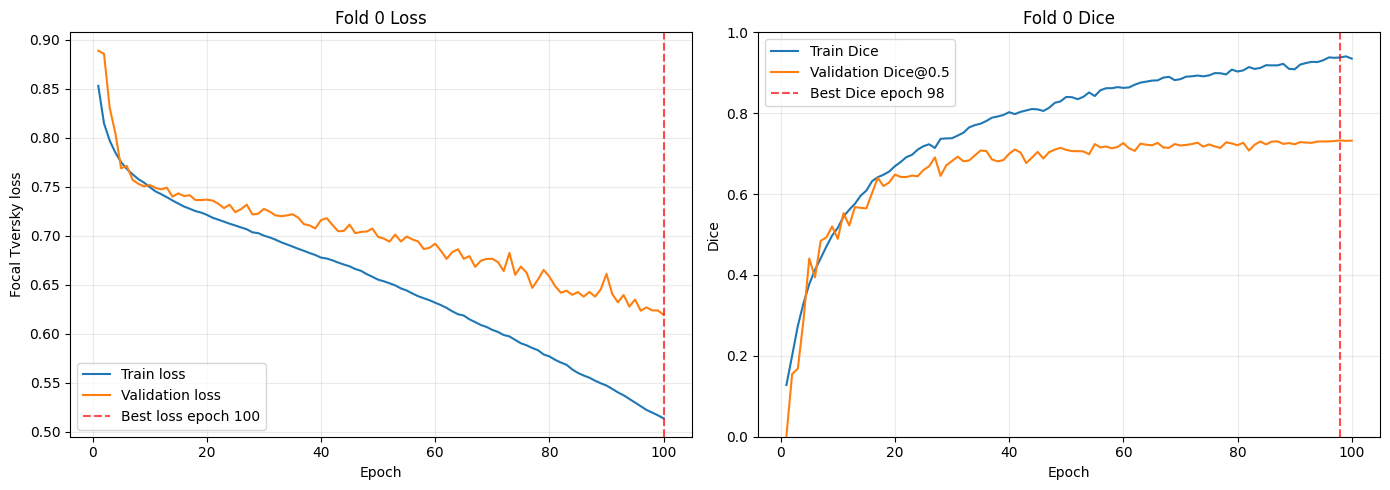

학습곡선 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/05_unet128_fold0_training_curves.png
Validation samples: 27
불러온 checkpoint epoch: 100
저장된 validation loss: 0.6193940220055757
Validation prediction shape: (27, 128, 128)
Probability range: 0.033327322 1.0
✅ Best checkpoint 예측 수집 완료

=== Threshold 0.5 공식 Pilot 결과 ===


,threshold,pooled_dice,pooled_iou,pooled_precision,pooled_recall,pooled_specificity,pooled_accuracy,predicted_vessel_rate,target_vessel_rate,macro_mean_dice,macro_median_dice,macro_std_dice
45,0.5,0.732168,0.577496,0.701233,0.765958,0.980619,0.968585,0.061234,0.05606,0.727964,0.73185,0.066688



=== 진단용 최고 Threshold ===


,threshold,pooled_dice,pooled_iou,pooled_precision,pooled_recall,pooled_specificity,pooled_accuracy,predicted_vessel_rate,target_vessel_rate,macro_mean_dice,macro_median_dice,macro_std_dice
61,0.66,0.732825,0.578314,0.719622,0.746522,0.982726,0.969485,0.058155,0.05606,0.728887,0.730088,0.067439


※ 진단용 최고 threshold는 최종 CV 점수 산정에 사용하지 않습니다.

=== 이미지별 Dice@0.5 분포 ===


,dice_at_0_5
count,27.000000
mean,0.727964
std,0.067958
min,0.508740
25%,0.697597
50%,0.731850
75%,0.776019
max,0.816022



=== 성능이 낮은 5개 영상 ===


,array_index,sample_id,dice_at_0_5,iou_at_0_5,precision_at_0_5,recall_at_0_5,specificity_at_0_5,target_vessel_rate,prediction_vessel_rate_at_0_5,vessel_rate_absolute_error,dice_at_diagnostic_threshold,diagnostic_threshold,gt_component_count,prediction_component_count,prediction_largest_component_coverage,empty_prediction
2,2,11,0.508740,0.341148,0.418651,0.648233,0.962753,0.039734,0.061523,0.021790,0.509804,0.66,1,21,0.593254,0
10,10,39,0.588978,0.417413,0.460503,0.816879,0.961856,0.038330,0.067993,0.029663,0.597510,0.66,1,26,0.608618,0
16,16,70,0.653750,0.485608,0.929592,0.504151,0.995267,0.110291,0.059814,0.050476,0.637893,0.66,1,13,0.389796,0
8,8,30,0.683112,0.518732,0.649819,0.720000,0.981387,0.045776,0.050720,0.004944,0.678100,0.66,1,19,0.842359,0
19,19,90,0.691067,0.527962,0.695381,0.686806,0.984332,0.049500,0.048889,0.000610,0.688691,0.66,1,18,0.857678,0


빈 예측 마스크: 0


/tmp/ipykernel_1160/2477231182.py:995: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


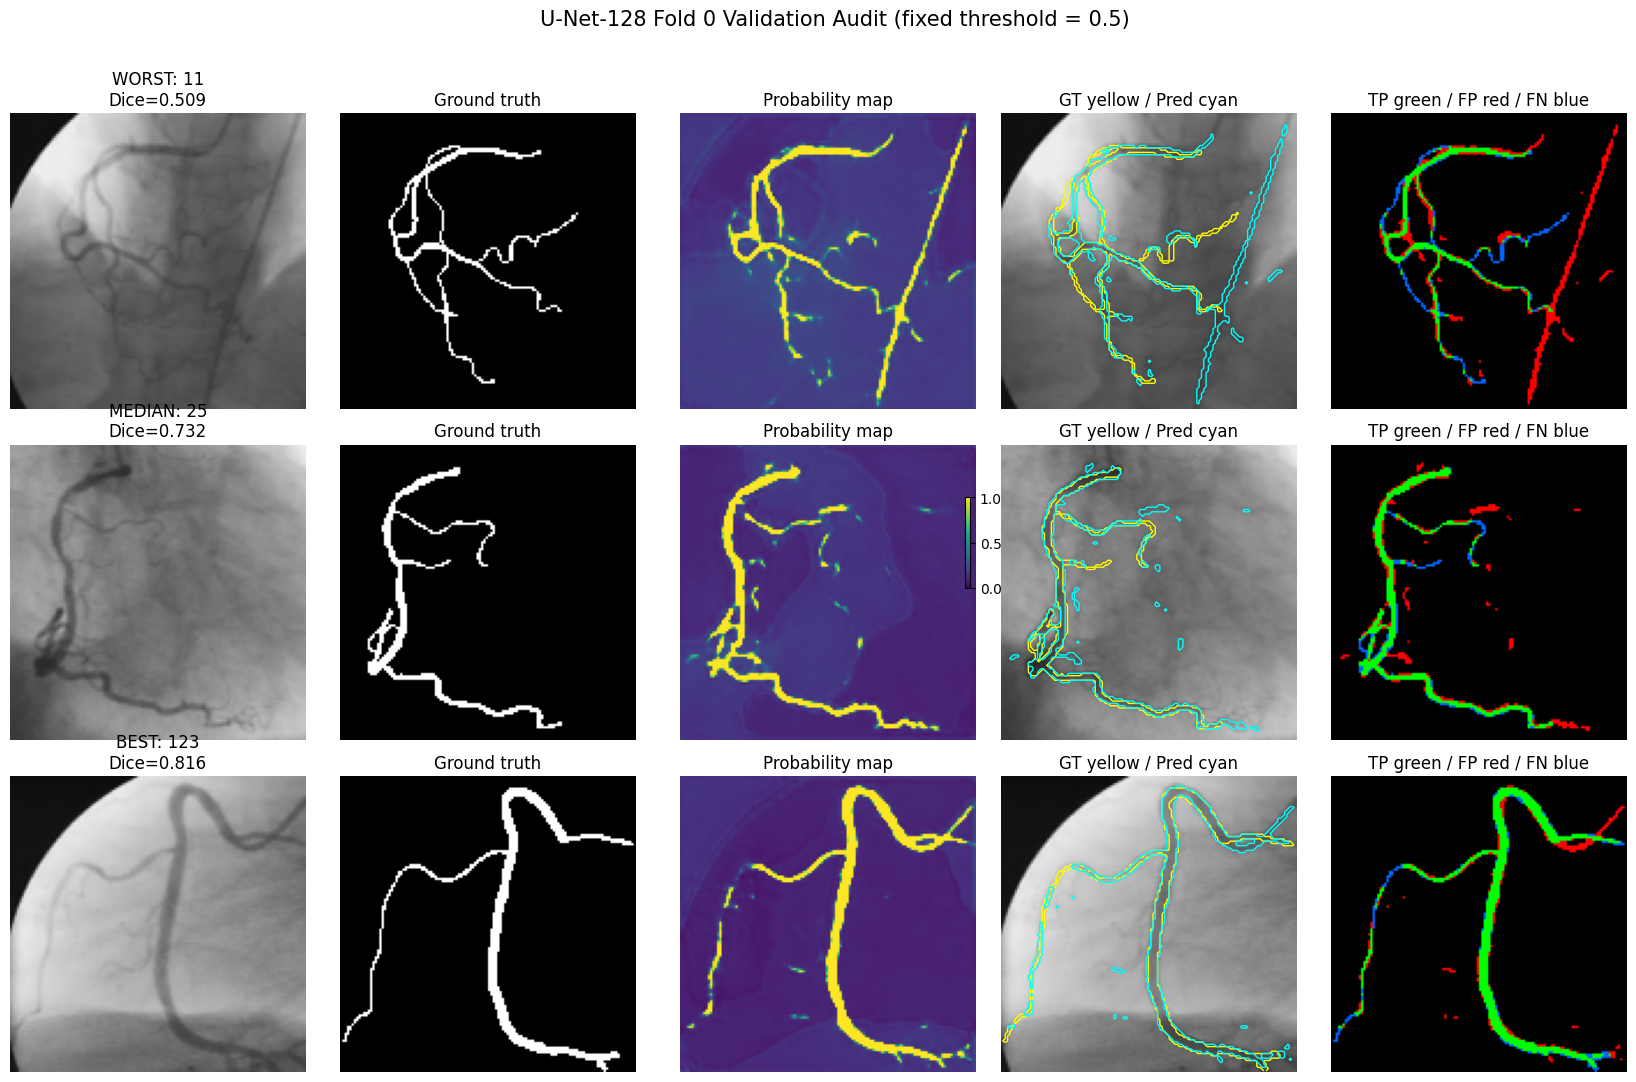

Overlay 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/08_unet128_fold0_prediction_overlay.png


,check,observed,expected,status
0,best_checkpoint_exists,1.000000,1,PASS
1,nonfinite_probability_count,0.000000,0,PASS
2,pooled_dice_at_0_5,0.732168,>= 0.70,PASS
3,macro_median_dice_at_0_5,0.731850,>= 0.60,PASS
4,empty_prediction_count,0.000000,0,PASS
5,diagnostic_threshold_shift,0.160000,<= 0.20 (diagnostic),PASS



=== Fold 0 Pilot 최종 판정 ===
✅ Fold 0 Pilot Gate 통과
Fixed threshold 0.5 pooled Dice: 0.7321679804195036
Diagnostic best threshold: 0.66
Diagnostic best pooled Dice: 0.7328253339936015

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/05_unet128_fold0_training_curves.png
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/06_unet128_fold0_threshold_audit.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/07_unet128_fold0_per_image_metrics.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/08_unet128_fold0_prediction_overlay.png
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_fold0_pilot/09_unet128_fold0_validation_gate.csv


In [ ]:
#@title U-Net-128 Fold 0 - 정량, 정성 검증 및 Gate

import copy
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# ==================================================
# 1. 경로 및 실행 환경 복구
# ==================================================
if "device" not in globals():
    if "DEVICE" in globas():
        device = torch.device(DEVICE)

    else :
        device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "cpu"
        )

if "PILOT_DIR" not in globals():
    if "DCA1_RESULT_DIR" not in globals():
        PROJECT_DIR = PATH(
            "/content/drive/MyDrive/"
            "[MacGyver]최종프로젝트/"
            "03_data/AngioCAD"
        )
        DCA1_RESULT_DIR = (
            PROJECT_DIR / "dca1_results"
        )

    PILOT_DIR = (
        Path(DCA1_RESULT_DIR)
        / "unet128_fold0_pilot"
    )

PILOT_DIR = Path(PILOT_DIR)

CONFIG_PATH = (
    PILOT_DIR
    / "01_unet128_fold0_pilot_config.json"
)
HISTORY_PATH = (
    PILOT_DIR
    / "02_unet128_fold0_pilot_history.csv"
)
BEST_CHECKPOINT_PATH = (
    PILOT_DIR
    / "03_unet128_fold0_pilot_best.pt"
)

TRAINING_CURVE_PATH = (
    PILOT_DIR
    / "05_unet128_fold0_training_curves.png"
)
THRESHOLD_AUDIT_PATH = (
    PILOT_DIR
    / "06_unet128_fold0_threshold_audit.csv"
)
PER_IMAGE_AUDIT_PATH = (
    PILOT_DIR
    / "07_unet128_fold0_per_image_metrics.csv"
)
OVERLAY_PATH = (
    PILOT_DIR
    / "08_unet128_fold0_prediction_overlay.png"
)
GATE_PATH = (
    PILOT_DIR
    / "09_unet128_fold0_validation_gate.csv"
)

assert CONFIG_PATH.exists()
assert HISTORY_PATH.exists()
assert BEST_CHECKPOINT_PATH.exists()

print("Device:", device)
print("Pilot directory:", PILOT_DIR)


# ==================================================
# 2. 설정과 학습 기록 불러오기
# ==================================================
with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    pilot_config = json.load(file)

history_df = pd.read_csv(HISTORY_PATH)

assert len(history_df) > 0
assert history_df["epoch"].is_unique

best_loss_row = (
    history_df
    .sort_values(
        ["val_loss", "epoch"],
        ascending=[True, True],
    )
    .iloc[0]
)

best_dice_row = (
    history_df
    .sort_values(
        ["val_dice_at_0_5", "epoch"],
        ascending=[False, True],
    )
    .iloc[0]
)

print(
    "Loss 기준 best epoch:",
    int(best_loss_row["epoch"]),
)
print(
    "Dice 기준 best epoch:",
    int(best_dice_row["epoch"]),
)


# ==================================================
# 3. 학습 곡선 생성
# ==================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss",
)
axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss",
)
axes[0].axvline(
    best_loss_row["epoch"],
    color="red",
    linestyle="--",
    alpha=0.7,
    label=(
        f"Best loss epoch "
        f"{int(best_loss_row['epoch'])}"
    ),
)
axes[0].set_title("Fold 0 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Tversky loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_dice"],
    label="Train Dice",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_dice_at_0_5"],
    label="Validation Dice@0.5",
)
axes[1].axvline(
    best_dice_row["epoch"],
    color="red",
    linestyle="--",
    alpha=0.7,
    label=(
        f"Best Dice epoch "
        f"{int(best_dice_row['epoch'])}"
    ),
)
axes[1].set_title("Fold 0 Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    TRAINING_CURVE_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("학습곡선 저장:", TRAINING_CURVE_PATH)


# ==================================================
# 4. Validation loader 복구
# ==================================================
if "pilot_val_loader" in globals():
    evaluation_loader = pilot_val_loader

elif "validation_loader" in globals():
    evaluation_loader = validation_loader

elif "fold0_val_loader" in globals():
    evaluation_loader = fold0_val_loader

elif "fold0_valid_loader" in globals():
    evaluation_loader = fold0_valid_loader

elif "pilot_val_dataset" in globals():
    evaluation_loader = DataLoader(
        pilot_val_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=False,
    )

else:
    raise NameError(
        "Fold 0 validation loader 또는 "
        "Dataset을 찾지 못했습니다."
    )

assert len(evaluation_loader.dataset) == 27

print(
    "Validation samples:",
    len(evaluation_loader.dataset),
)


# ==================================================
# 5. Best checkpoint 모델 복구
# ==================================================
if "pilot_model" in globals():
    evaluation_model = copy.deepcopy(
        pilot_model
    )
elif "model" in globals():
    evaluation_model = copy.deepcopy(model)
else:
    raise NameError(
        "U-Net 모델 객체가 없습니다."
    )

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

evaluation_model.load_state_dict(
    checkpoint["model_state_dict"]
)
evaluation_model = evaluation_model.to(device)
evaluation_model.eval()

print(
    "불러온 checkpoint epoch:",
    checkpoint["epoch"],
)
print(
    "저장된 validation loss:",
    checkpoint["validation_loss"],
)


# ==================================================
# 6. Validation 예측 수집
# ==================================================
def normalize_sample_ids(
    sample_ids,
    batch_size,
    start_index,
):
    if sample_ids is None:
        return [
            f"fold0_val_{start_index + index:03d}"
            for index in range(batch_size)
        ]

    if torch.is_tensor(sample_ids):
        sample_ids = (
            sample_ids
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
            .tolist()
        )

    elif isinstance(sample_ids, np.ndarray):
        sample_ids = (
            sample_ids
            .reshape(-1)
            .tolist()
        )

    elif isinstance(sample_ids, str):
        sample_ids = [sample_ids]

    else:
        sample_ids = list(sample_ids)

    return [
        str(sample_id)
        for sample_id in sample_ids
    ]


validation_images = []
validation_masks = []
validation_probabilities = []
validation_sample_ids = []

running_index = 0

with torch.no_grad():
    for batch in evaluation_loader:
        if isinstance(batch, dict):
            images = batch["image"]
            masks = batch["mask"]
            raw_sample_ids = batch.get(
                "sample_id"
            )
        else:
            images = batch[0]
            masks = batch[1]
            raw_sample_ids = None

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True,
        )
        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True,
        )

        logits = evaluation_model(images)
        probabilities = torch.sigmoid(logits)

        batch_size = images.shape[0]

        sample_ids = normalize_sample_ids(
            raw_sample_ids,
            batch_size=batch_size,
            start_index=running_index,
        )

        validation_images.append(
            images.detach().cpu().numpy()
        )
        validation_masks.append(
            masks.detach().cpu().numpy()
        )
        validation_probabilities.append(
            probabilities.detach().cpu().numpy()
        )
        validation_sample_ids.extend(
            sample_ids
        )

        running_index += batch_size

validation_images = np.concatenate(
    validation_images,
    axis=0,
)[:, 0]

validation_masks = np.concatenate(
    validation_masks,
    axis=0,
)[:, 0]

validation_probabilities = np.concatenate(
    validation_probabilities,
    axis=0,
)[:, 0]

assert validation_images.shape == (
    27,
    128,
    128,
)
assert validation_masks.shape == (
    27,
    128,
    128,
)
assert validation_probabilities.shape == (
    27,
    128,
    128,
)
assert len(validation_sample_ids) == 27

nonfinite_probability_count = int(
    (~np.isfinite(
        validation_probabilities
    )).sum()
)

assert nonfinite_probability_count == 0

print(
    "Validation prediction shape:",
    validation_probabilities.shape,
)
print(
    "Probability range:",
    validation_probabilities.min(),
    validation_probabilities.max(),
)
print("✅ Best checkpoint 예측 수집 완료")


# ==================================================
# 7. Metric 함수
# ==================================================
def calculate_numpy_metrics(
    probabilities,
    targets,
    threshold,
    eps=1e-7,
):
    predictions = (
        probabilities >= threshold
    ).astype(np.uint8)

    targets = (
        targets >= 0.5
    ).astype(np.uint8)

    tp = float(
        np.logical_and(
            predictions == 1,
            targets == 1,
        ).sum()
    )
    fp = float(
        np.logical_and(
            predictions == 1,
            targets == 0,
        ).sum()
    )
    fn = float(
        np.logical_and(
            predictions == 0,
            targets == 1,
        ).sum()
    )
    tn = float(
        np.logical_and(
            predictions == 0,
            targets == 0,
        ).sum()
    )

    return {
        "dice": (
            (2 * tp + eps)
            / (2 * tp + fp + fn + eps)
        ),
        "iou": (
            (tp + eps)
            / (tp + fp + fn + eps)
        ),
        "precision": (
            (tp + eps)
            / (tp + fp + eps)
        ),
        "recall": (
            (tp + eps)
            / (tp + fn + eps)
        ),
        "specificity": (
            (tn + eps)
            / (tn + fp + eps)
        ),
        "accuracy": (
            (tp + tn + eps)
            / (tp + fp + fn + tn + eps)
        ),
        "predicted_vessel_rate": (
            predictions.mean()
        ),
        "target_vessel_rate": (
            targets.mean()
        ),
    }


# ==================================================
# 8. Threshold sweep
# 진단용이며 최종 CV 성능으로 사용하지 않음
# ==================================================
threshold_rows = []

threshold_values = np.round(
    np.arange(0.05, 0.951, 0.01),
    2,
)

for threshold in threshold_values:
    pooled_metrics = (
        calculate_numpy_metrics(
            validation_probabilities,
            validation_masks,
            threshold=float(threshold),
        )
    )

    per_image_dice = []

    for image_index in range(
        len(validation_masks)
    ):
        image_metrics = (
            calculate_numpy_metrics(
                validation_probabilities[
                    image_index
                ],
                validation_masks[
                    image_index
                ],
                threshold=float(threshold),
            )
        )

        per_image_dice.append(
            image_metrics["dice"]
        )

    threshold_rows.append({
        "threshold": float(threshold),
        "pooled_dice": (
            pooled_metrics["dice"]
        ),
        "pooled_iou": (
            pooled_metrics["iou"]
        ),
        "pooled_precision": (
            pooled_metrics["precision"]
        ),
        "pooled_recall": (
            pooled_metrics["recall"]
        ),
        "pooled_specificity": (
            pooled_metrics["specificity"]
        ),
        "pooled_accuracy": (
            pooled_metrics["accuracy"]
        ),
        "predicted_vessel_rate": (
            pooled_metrics[
                "predicted_vessel_rate"
            ]
        ),
        "target_vessel_rate": (
            pooled_metrics[
                "target_vessel_rate"
            ]
        ),
        "macro_mean_dice": float(
            np.mean(per_image_dice)
        ),
        "macro_median_dice": float(
            np.median(per_image_dice)
        ),
        "macro_std_dice": float(
            np.std(per_image_dice)
        ),
    })

threshold_audit_df = pd.DataFrame(
    threshold_rows
)

threshold_audit_df.to_csv(
    THRESHOLD_AUDIT_PATH,
    index=False,
)

fixed_threshold_row = (
    threshold_audit_df.loc[
        np.isclose(
            threshold_audit_df["threshold"],
            0.50,
        )
    ]
    .iloc[0]
)

diagnostic_best_row = (
    threshold_audit_df
    .sort_values(
        [
            "pooled_dice",
            "macro_mean_dice",
        ],
        ascending=False,
    )
    .iloc[0]
)

print("\n=== Threshold 0.5 공식 Pilot 결과 ===")
display(
    fixed_threshold_row.to_frame().T
)

print("\n=== 진단용 최고 Threshold ===")
display(
    diagnostic_best_row.to_frame().T
)

print(
    "※ 진단용 최고 threshold는 "
    "최종 CV 점수 산정에 사용하지 않습니다."
)


# ==================================================
# 9. Connected component 함수
# ==================================================
def calculate_component_statistics(
    binary_mask,
):
    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)

    component_count, labels = (
        cv2.connectedComponents(
            binary_mask,
            connectivity=8,
        )
    )

    foreground_component_count = (
        component_count - 1
    )

    if foreground_component_count == 0:
        return {
            "component_count": 0,
            "largest_component_coverage": 0.0,
        }

    component_sizes = np.bincount(
        labels.reshape(-1)
    )[1:]

    total_foreground = (
        component_sizes.sum()
    )

    largest_component_coverage = (
        component_sizes.max()
        / max(total_foreground, 1)
    )

    return {
        "component_count": int(
            foreground_component_count
        ),
        "largest_component_coverage": float(
            largest_component_coverage
        ),
    }


# ==================================================
# 10. 이미지별 metric
# Primary threshold는 0.5
# ==================================================
FIXED_THRESHOLD = 0.5
DIAGNOSTIC_THRESHOLD = float(
    diagnostic_best_row["threshold"]
)

per_image_rows = []

for image_index in range(
    len(validation_masks)
):
    probability = (
        validation_probabilities[
            image_index
        ]
    )
    target = validation_masks[
        image_index
    ]

    fixed_metrics = (
        calculate_numpy_metrics(
            probability,
            target,
            threshold=FIXED_THRESHOLD,
        )
    )

    diagnostic_metrics = (
        calculate_numpy_metrics(
            probability,
            target,
            threshold=DIAGNOSTIC_THRESHOLD,
        )
    )

    fixed_prediction = (
        probability >= FIXED_THRESHOLD
    ).astype(np.uint8)

    target_binary = (
        target >= 0.5
    ).astype(np.uint8)

    target_components = (
        calculate_component_statistics(
            target_binary
        )
    )

    prediction_components = (
        calculate_component_statistics(
            fixed_prediction
        )
    )

    per_image_rows.append({
        "array_index": image_index,
        "sample_id": (
            validation_sample_ids[
                image_index
            ]
        ),
        "dice_at_0_5": (
            fixed_metrics["dice"]
        ),
        "iou_at_0_5": (
            fixed_metrics["iou"]
        ),
        "precision_at_0_5": (
            fixed_metrics["precision"]
        ),
        "recall_at_0_5": (
            fixed_metrics["recall"]
        ),
        "specificity_at_0_5": (
            fixed_metrics["specificity"]
        ),
        "target_vessel_rate": (
            fixed_metrics[
                "target_vessel_rate"
            ]
        ),
        "prediction_vessel_rate_at_0_5": (
            fixed_metrics[
                "predicted_vessel_rate"
            ]
        ),
        "vessel_rate_absolute_error": abs(
            fixed_metrics[
                "predicted_vessel_rate"
            ]
            - fixed_metrics[
                "target_vessel_rate"
            ]
        ),
        "dice_at_diagnostic_threshold": (
            diagnostic_metrics["dice"]
        ),
        "diagnostic_threshold": (
            DIAGNOSTIC_THRESHOLD
        ),
        "gt_component_count": (
            target_components[
                "component_count"
            ]
        ),
        "prediction_component_count": (
            prediction_components[
                "component_count"
            ]
        ),
        "prediction_largest_component_coverage": (
            prediction_components[
                "largest_component_coverage"
            ]
        ),
        "empty_prediction": int(
            fixed_prediction.sum() == 0
        ),
    })

per_image_audit_df = pd.DataFrame(
    per_image_rows
)

per_image_audit_df.to_csv(
    PER_IMAGE_AUDIT_PATH,
    index=False,
)

print("\n=== 이미지별 Dice@0.5 분포 ===")
display(
    per_image_audit_df[
        "dice_at_0_5"
    ].describe().to_frame()
)

print("\n=== 성능이 낮은 5개 영상 ===")
display(
    per_image_audit_df
    .sort_values("dice_at_0_5")
    .head(5)
)

print(
    "빈 예측 마스크:",
    per_image_audit_df[
        "empty_prediction"
    ].sum(),
)


# ==================================================
# 11. Best / Median / Worst 선정
# ==================================================
sorted_per_image_df = (
    per_image_audit_df
    .sort_values("dice_at_0_5")
    .reset_index(drop=True)
)

case_rows = {
    "WORST": sorted_per_image_df.iloc[0],
    "MEDIAN": sorted_per_image_df.iloc[
        len(sorted_per_image_df) // 2
    ],
    "BEST": sorted_per_image_df.iloc[-1],
}


# ==================================================
# 12. Prediction overlay
# ==================================================
fig, axes = plt.subplots(
    3,
    5,
    figsize=(17, 11),
)

for row_index, (
    case_name,
    case_row,
) in enumerate(case_rows.items()):
    image_index = int(
        case_row["array_index"]
    )

    image = validation_images[
        image_index
    ]
    target = (
        validation_masks[
            image_index
        ] >= 0.5
    )
    probability = (
        validation_probabilities[
            image_index
        ]
    )
    prediction = (
        probability >= FIXED_THRESHOLD
    )

    tp = np.logical_and(
        prediction,
        target,
    )
    fp = np.logical_and(
        prediction,
        ~target,
    )
    fn = np.logical_and(
        ~prediction,
        target,
    )

    error_map = np.zeros(
        (*target.shape, 3),
        dtype=np.float32,
    )

    # TP=green, FP=red, FN=blue
    error_map[tp] = [0.0, 1.0, 0.0]
    error_map[fp] = [1.0, 0.0, 0.0]
    error_map[fn] = [0.0, 0.4, 1.0]

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 0].set_title(
        f"{case_name}: "
        f"{case_row['sample_id']}\n"
        f"Dice={case_row['dice_at_0_5']:.3f}"
    )

    axes[row_index, 1].imshow(
        target,
        cmap="gray",
    )
    axes[row_index, 1].set_title("Ground truth")

    probability_plot = axes[
        row_index,
        2
    ].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 2].set_title(
        "Probability map"
    )

    axes[row_index, 3].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 3].contour(
        target.astype(np.uint8),
        levels=[0.5],
        colors=["yellow"],
        linewidths=1.0,
    )
    axes[row_index, 3].contour(
        prediction.astype(np.uint8),
        levels=[0.5],
        colors=["cyan"],
        linewidths=1.0,
    )
    axes[row_index, 3].set_title(
        "GT yellow / Pred cyan"
    )

    axes[row_index, 4].imshow(
        error_map
    )
    axes[row_index, 4].set_title(
        "TP green / FP red / FN blue"
    )

    for column_index in range(5):
        axes[
            row_index,
            column_index
        ].axis("off")

fig.colorbar(
    probability_plot,
    ax=axes[:, 2],
    fraction=0.02,
    pad=0.02,
)

plt.suptitle(
    "U-Net-128 Fold 0 Validation Audit "
    "(fixed threshold = 0.5)",
    fontsize=15,
)

plt.tight_layout(
    rect=[0, 0, 0.98, 0.96]
)

plt.savefig(
    OVERLAY_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Overlay 저장:", OVERLAY_PATH)


# ==================================================
# 13. Pilot Gate
# ==================================================
fixed_pooled_dice = float(
    fixed_threshold_row["pooled_dice"]
)
fixed_macro_median_dice = float(
    fixed_threshold_row[
        "macro_median_dice"
    ]
)
empty_prediction_count = int(
    per_image_audit_df[
        "empty_prediction"
    ].sum()
)
threshold_shift = abs(
    DIAGNOSTIC_THRESHOLD - 0.5
)

gate_rows = [
    {
        "check": "best_checkpoint_exists",
        "observed": int(
            BEST_CHECKPOINT_PATH.exists()
        ),
        "expected": 1,
        "status": (
            "PASS"
            if BEST_CHECKPOINT_PATH.exists()
            else "FAIL"
        ),
    },
    {
        "check": "nonfinite_probability_count",
        "observed": (
            nonfinite_probability_count
        ),
        "expected": 0,
        "status": (
            "PASS"
            if nonfinite_probability_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "pooled_dice_at_0_5",
        "observed": fixed_pooled_dice,
        "expected": ">= 0.70",
        "status": (
            "PASS"
            if fixed_pooled_dice >= 0.70
            else "FAIL"
        ),
    },
    {
        "check": "macro_median_dice_at_0_5",
        "observed": (
            fixed_macro_median_dice
        ),
        "expected": ">= 0.60",
        "status": (
            "PASS"
            if fixed_macro_median_dice >= 0.60
            else "FAIL"
        ),
    },
    {
        "check": "empty_prediction_count",
        "observed": (
            empty_prediction_count
        ),
        "expected": 0,
        "status": (
            "PASS"
            if empty_prediction_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "diagnostic_threshold_shift",
        "observed": threshold_shift,
        "expected": "<= 0.20 (diagnostic)",
        "status": (
            "PASS"
            if threshold_shift <= 0.20
            else "WARNING"
        ),
    },
]

gate_df = pd.DataFrame(gate_rows)

gate_df.to_csv(
    GATE_PATH,
    index=False,
)

display(gate_df)

failed_gate_count = int(
    (gate_df["status"] == "FAIL").sum()
)
warning_gate_count = int(
    (gate_df["status"] == "WARNING").sum()
)

print("\n=== Fold 0 Pilot 최종 판정 ===")

if failed_gate_count > 0:
    pilot_gate_status = "FAIL"

    print(
        "❌ Fold 0 Pilot Gate 미통과"
    )

elif warning_gate_count > 0:
    pilot_gate_status = (
        "PASS_WITH_WARNING"
    )

    print(
        "⚠️ Fold 0 Pilot Gate 통과 "
        "(threshold calibration 검토 필요)"
    )

else:
    pilot_gate_status = "PASS"

    print(
        "✅ Fold 0 Pilot Gate 통과"
    )

print(
    "Fixed threshold 0.5 pooled Dice:",
    fixed_pooled_dice,
)
print(
    "Diagnostic best threshold:",
    DIAGNOSTIC_THRESHOLD,
)
print(
    "Diagnostic best pooled Dice:",
    float(
        diagnostic_best_row[
            "pooled_dice"
        ]
    ),
)

print("\n저장 완료:")
print(TRAINING_CURVE_PATH)
print(THRESHOLD_AUDIT_PATH)
print(PER_IMAGE_AUDIT_PATH)
print(OVERLAY_PATH)
print(GATE_PATH)

In [ ]:
#@title U-Net-128 전체 5-Fold 입력 Gate

import copy
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import ConcatDataset


# ==================================================
# 1. 경로 및 설정
# ==================================================
if "DCA1_RESULT_DIR" not in globals():
    PROJECT_DIR = Path(
        "/content/drive/MyDrive/"
        "[MacGyver]최종프로젝트/"
        "03_data/AngioCAD"
    )
    DCA1_RESULT_DIR = (
        PROJECT_DIR / "dca1_results"
    )

DCA1_RESULT_DIR = Path(DCA1_RESULT_DIR)

FIVEFOLD_DIR = (
    DCA1_RESULT_DIR
    / "unet128_5fold_raw"
)
FIVEFOLD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CV_MANIFEST_PATH = (
    DCA1_RESULT_DIR
    / "04_dca1_cv_manifest.csv"
)

INPUT_GATE_PATH = (
    FIVEFOLD_DIR
    / "00_unet128_5fold_input_gate.csv"
)
INDEX_MANIFEST_PATH = (
    FIVEFOLD_DIR
    / "01_unet128_5fold_sample_index.csv"
)
FINAL_CONFIG_PATH = (
    FIVEFOLD_DIR
    / "02_unet128_5fold_config.json"
)

FINAL_CONFIG = {
    "experiment": "UNET128_5FOLD_RAW",
    "input_size": 128,
    "fold_count": 5,
    "seed": 42,
    "fold_seed_rule": "42 + fold",
    "batch_size": 8,
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "weight_decay": 0.0,
    "loss": "FocalTverskyLoss",
    "loss_alpha": 0.3,
    "loss_beta": 0.7,
    "loss_gamma": 0.75,
    "max_epochs": 100,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 1e-4,
    "model_selection": "minimum_validation_loss",
    "primary_threshold": 0.5,
    "augmentation": False,
    "postprocessing": False,
    "pilot_fold0_used_for_engineering_check": True,
}

assert CV_MANIFEST_PATH.exists(), (
    f"CV manifest가 없습니다: "
    f"{CV_MANIFEST_PATH}"
)

print("5-Fold directory:", FIVEFOLD_DIR)


# ==================================================
# 2. Fold 0에서 검증된 Dataset 확인
# ==================================================
if "pilot_train_dataset" not in globals():
    raise NameError(
        "pilot_train_dataset이 없습니다. "
        "Fold 0 Pilot 셀을 먼저 실행하세요."
    )

if "pilot_val_dataset" not in globals():
    raise NameError(
        "pilot_val_dataset이 없습니다. "
        "Fold 0 Pilot 셀을 먼저 실행하세요."
    )

print(
    "Pilot train dataset:",
    len(pilot_train_dataset),
)
print(
    "Pilot validation dataset:",
    len(pilot_val_dataset),
)

assert len(pilot_train_dataset) == 107
assert len(pilot_val_dataset) == 27


# ==================================================
# 3. 두 Dataset을 합쳐 134장 전체 구성
# ==================================================
dca1_full_dataset = ConcatDataset([
    pilot_train_dataset,
    pilot_val_dataset,
])

assert len(dca1_full_dataset) == 134

print(
    "Combined full dataset:",
    len(dca1_full_dataset),
)


# ==================================================
# 4. CV manifest 읽기
# ==================================================
dca1_cv_manifest_df = pd.read_csv(
    CV_MANIFEST_PATH
)

dca1_cv_manifest_df.columns = [
    column.strip()
    if isinstance(column, str)
    else column
    for column in dca1_cv_manifest_df.columns
]

required_columns = {
    "sample_id",
    "cv_fold",
}

missing_columns = (
    required_columns
    - set(dca1_cv_manifest_df.columns)
)

assert not missing_columns, (
    f"CV manifest 필수 열 누락: "
    f"{missing_columns}"
)

dca1_cv_manifest_df["sample_id"] = (
    dca1_cv_manifest_df["sample_id"]
    .astype(str)
)

dca1_cv_manifest_df["cv_fold"] = (
    pd.to_numeric(
        dca1_cv_manifest_df["cv_fold"],
        errors="raise",
    )
    .astype(int)
)

assert len(dca1_cv_manifest_df) == 134
assert (
    dca1_cv_manifest_df["sample_id"]
    .duplicated()
    .sum()
    == 0
)
assert set(
    dca1_cv_manifest_df["cv_fold"]
) == {0, 1, 2, 3, 4}

fold_by_sample_id = dict(
    zip(
        dca1_cv_manifest_df["sample_id"],
        dca1_cv_manifest_df["cv_fold"],
    )
)


# ==================================================
# 5. 전체 Dataset 실제 샘플 검사
# ==================================================
sample_rows = []
seen_sample_ids = []

abnormal_image_shape_count = 0
abnormal_mask_shape_count = 0
nonfinite_image_count = 0
nonfinite_mask_count = 0
nonbinary_mask_count = 0
empty_mask_count = 0

for dataset_index in range(
    len(dca1_full_dataset)
):
    sample = dca1_full_dataset[
        dataset_index
    ]

    assert isinstance(sample, dict), (
        f"Dataset index {dataset_index}: "
        "dict 형식이 아닙니다."
    )

    assert "image" in sample
    assert "mask" in sample
    assert "sample_id" in sample

    image = sample["image"]
    mask = sample["mask"]
    sample_id = str(sample["sample_id"])

    if not torch.is_tensor(image):
        image = torch.as_tensor(image)

    if not torch.is_tensor(mask):
        mask = torch.as_tensor(mask)

    if tuple(image.shape) != (
        1,
        128,
        128,
    ):
        abnormal_image_shape_count += 1

    if tuple(mask.shape) != (
        1,
        128,
        128,
    ):
        abnormal_mask_shape_count += 1

    if not torch.isfinite(image).all():
        nonfinite_image_count += 1

    if not torch.isfinite(mask).all():
        nonfinite_mask_count += 1

    mask_unique = set(
        torch.unique(mask)
        .detach()
        .cpu()
        .tolist()
    )

    if not mask_unique.issubset(
        {0.0, 1.0}
    ):
        nonbinary_mask_count += 1

    if float(mask.sum()) == 0:
        empty_mask_count += 1

    if sample_id not in fold_by_sample_id:
        cv_fold = None
    else:
        cv_fold = int(
            fold_by_sample_id[sample_id]
        )

    seen_sample_ids.append(sample_id)

    sample_rows.append({
        "dataset_index": dataset_index,
        "sample_id": sample_id,
        "cv_fold": cv_fold,
        "image_shape": (
            "x".join(
                map(str, image.shape)
            )
        ),
        "mask_shape": (
            "x".join(
                map(str, mask.shape)
            )
        ),
        "image_min": float(
            image.min()
        ),
        "image_max": float(
            image.max()
        ),
        "mask_pixel_rate": float(
            mask.float().mean()
        ),
    })

full_sample_index_df = pd.DataFrame(
    sample_rows
)


# ==================================================
# 6. ID 및 fold 연결 검증
# ==================================================
dataset_id_set = set(
    seen_sample_ids
)
manifest_id_set = set(
    dca1_cv_manifest_df["sample_id"]
)

duplicate_dataset_id_count = int(
    pd.Series(seen_sample_ids)
    .duplicated()
    .sum()
)

dataset_missing_from_manifest = sorted(
    dataset_id_set - manifest_id_set
)

manifest_missing_from_dataset = sorted(
    manifest_id_set - dataset_id_set
)

null_fold_count = int(
    full_sample_index_df[
        "cv_fold"
    ].isna().sum()
)

fold_distribution_df = (
    full_sample_index_df
    .groupby("cv_fold")
    .agg(
        validation_sample_count=(
            "sample_id",
            "count",
        ),
        mean_vessel_rate=(
            "mask_pixel_rate",
            "mean",
        ),
        min_vessel_rate=(
            "mask_pixel_rate",
            "min",
        ),
        max_vessel_rate=(
            "mask_pixel_rate",
            "max",
        ),
    )
    .reset_index()
)

fold_distribution_df[
    "training_sample_count"
] = (
    len(full_sample_index_df)
    - fold_distribution_df[
        "validation_sample_count"
    ]
)

print("\n=== 전체 Fold 분포 ===")
display(fold_distribution_df)


# ==================================================
# 7. 모델 구조 Gate
# ==================================================
if "model" not in globals():
    raise NameError(
        "검증된 U-Net model 객체가 없습니다."
    )

unet128_model_template = copy.deepcopy(
    model
).cpu()

# Smoke test로 변경된 BN running statistics 초기화
for module in (
    unet128_model_template.modules()
):
    if hasattr(
        module,
        "reset_running_stats",
    ):
        module.reset_running_stats()

unet128_model_template.zero_grad(
    set_to_none=True
)

parameter_count = sum(
    parameter.numel()
    for parameter
    in unet128_model_template.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in unet128_model_template.parameters()
    if parameter.requires_grad
)

print(
    "전체 parameter:",
    parameter_count,
)
print(
    "학습 parameter:",
    trainable_parameter_count,
)

assert parameter_count == 7_762_465, (
    "Pilot과 U-Net parameter 수가 다릅니다."
)


# ==================================================
# 8. 재현성 hash 생성
# ==================================================
hash_source_df = (
    full_sample_index_df[
        [
            "sample_id",
            "cv_fold",
            "mask_pixel_rate",
        ]
    ]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

input_manifest_sha256 = hashlib.sha256(
    hash_source_df.to_csv(
        index=False
    ).encode("utf-8")
).hexdigest()

FINAL_CONFIG[
    "sample_count"
] = len(full_sample_index_df)

FINAL_CONFIG[
    "parameter_count"
] = parameter_count

FINAL_CONFIG[
    "input_manifest_sha256"
] = input_manifest_sha256


# ==================================================
# 9. Gate 표 작성
# ==================================================
gate_rows = [
    {
        "check": "full_dataset_sample_count",
        "observed": (
            len(dca1_full_dataset)
        ),
        "expected": 134,
    },
    {
        "check": "duplicate_dataset_id",
        "observed": (
            duplicate_dataset_id_count
        ),
        "expected": 0,
    },
    {
        "check": "dataset_missing_from_manifest",
        "observed": len(
            dataset_missing_from_manifest
        ),
        "expected": 0,
    },
    {
        "check": "manifest_missing_from_dataset",
        "observed": len(
            manifest_missing_from_dataset
        ),
        "expected": 0,
    },
    {
        "check": "null_cv_fold",
        "observed": null_fold_count,
        "expected": 0,
    },
    {
        "check": "abnormal_image_shape",
        "observed": (
            abnormal_image_shape_count
        ),
        "expected": 0,
    },
    {
        "check": "abnormal_mask_shape",
        "observed": (
            abnormal_mask_shape_count
        ),
        "expected": 0,
    },
    {
        "check": "nonfinite_image",
        "observed": nonfinite_image_count,
        "expected": 0,
    },
    {
        "check": "nonfinite_mask",
        "observed": nonfinite_mask_count,
        "expected": 0,
    },
    {
        "check": "nonbinary_mask",
        "observed": nonbinary_mask_count,
        "expected": 0,
    },
    {
        "check": "empty_mask",
        "observed": empty_mask_count,
        "expected": 0,
    },
    {
        "check": "model_parameter_count",
        "observed": parameter_count,
        "expected": 7_762_465,
    },
]

input_gate_df = pd.DataFrame(gate_rows)

input_gate_df["status"] = np.where(
    input_gate_df["observed"]
    == input_gate_df["expected"],
    "PASS",
    "FAIL",
)

display(input_gate_df)


# ==================================================
# 10. 저장
# ==================================================
full_sample_index_df.to_csv(
    INDEX_MANIFEST_PATH,
    index=False,
)

input_gate_df.to_csv(
    INPUT_GATE_PATH,
    index=False,
)

with open(
    FINAL_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FINAL_CONFIG,
        file,
        ensure_ascii=False,
        indent=2,
    )

failed_count = int(
    (input_gate_df["status"] == "FAIL")
    .sum()
)

if failed_count > 0:
    raise AssertionError(
        f"5-Fold 입력 Gate 실패: "
        f"{failed_count}개"
    )

print("\n✅ U-Net-128 전체 5-Fold 입력 Gate 통과")
print("Input SHA-256:", input_manifest_sha256)

print("\n저장 완료:")
print(INPUT_GATE_PATH)
print(INDEX_MANIFEST_PATH)
print(FINAL_CONFIG_PATH)

5-Fold directory: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw
Pilot train dataset: 107
Pilot validation dataset: 27
Combined full dataset: 134

=== 전체 Fold 분포 ===


,cv_fold,validation_sample_count,mean_vessel_rate,min_vessel_rate,max_vessel_rate,training_sample_count
0,0,27,0.056060,0.032288,0.110291,107
1,1,27,0.055160,0.037292,0.083374,107
2,2,27,0.054168,0.033447,0.084412,107
3,3,27,0.053987,0.027893,0.081604,107
4,4,26,0.053894,0.027527,0.094788,108


전체 parameter: 7762465
학습 parameter: 7762465


,check,observed,expected,status
0,full_dataset_sample_count,134,134,PASS
1,duplicate_dataset_id,0,0,PASS
2,dataset_missing_from_manifest,0,0,PASS
3,manifest_missing_from_dataset,0,0,PASS
4,null_cv_fold,0,0,PASS
5,abnormal_image_shape,0,0,PASS
6,abnormal_mask_shape,0,0,PASS
7,nonfinite_image,0,0,PASS
8,nonfinite_mask,0,0,PASS
9,nonbinary_mask,0,0,PASS



✅ U-Net-128 전체 5-Fold 입력 Gate 통과
Input SHA-256: 405ac0db7d05e4ac366c401e693ffc0db22bb0439fbb2552cf22eb6c9f907b84

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/00_unet128_5fold_input_gate.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/01_unet128_5fold_sample_index.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/02_unet128_5fold_config.json


In [ ]:
#@title U-Net-128 전체 5-Fold Raw Baseline 학습

import copy
import gc
import hashlib
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset


# ==================================================
# 1. 실행 설정
# ==================================================
RESUME_5FOLD = True

required_global_variables = [
    "dca1_full_dataset",
    "full_sample_index_df",
    "unet128_model_template",
    "FIVEFOLD_DIR",
    "FINAL_CONFIG",
    "FocalTverskyLoss",
]

missing_global_variables = [
    variable_name
    for variable_name
    in required_global_variables
    if variable_name not in globals()
]

if missing_global_variables:
    raise NameError(
        "5-Fold 입력 Gate 셀을 먼저 실행하세요. "
        f"누락 변수: {missing_global_variables}"
    )

if "device" not in globals():
    if "DEVICE" in globals():
        device = torch.device(DEVICE)
    else:
        device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "cpu"
        )

FIVEFOLD_DIR = Path(FIVEFOLD_DIR)

assert len(dca1_full_dataset) == 134
assert len(full_sample_index_df) == 134
assert device.type == "cuda", (
    "전체 5-fold 학습은 GPU 런타임에서 "
    "진행하는 것을 권장합니다."
)

FINAL_CONFIG[
    "model_initialization"
] = (
    "same_verified_template_weights_"
    "for_all_folds"
)

FINAL_CONFIG[
    "fold_seed_usage"
] = (
    "data_loader_order_and_runtime_"
    "reproducibility"
)


# ==================================================
# 2. 모델 template hash
# ==================================================
def calculate_model_state_sha256(model):
    sha256 = hashlib.sha256()

    for parameter_name, tensor in sorted(
        model.state_dict().items()
    ):
        sha256.update(
            parameter_name.encode("utf-8")
        )
        sha256.update(
            tensor.detach()
            .cpu()
            .contiguous()
            .numpy()
            .tobytes()
        )

    return sha256.hexdigest()


model_template_sha256 = (
    calculate_model_state_sha256(
        unet128_model_template
    )
)

FINAL_CONFIG[
    "model_template_sha256"
] = model_template_sha256

with open(
    FIVEFOLD_DIR
    / "02_unet128_5fold_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FINAL_CONFIG,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Device:", device)
print(
    "Model template SHA-256:",
    model_template_sha256,
)


# ==================================================
# 3. 재현성
# ==================================================
def set_fold_reproducibility(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


# ==================================================
# 4. Batch 처리
# ==================================================
def extract_segmentation_batch(batch):
    if isinstance(batch, dict):
        images = batch["image"]
        masks = batch["mask"]

    elif isinstance(batch, (tuple, list)):
        images = batch[0]
        masks = batch[1]

    else:
        raise TypeError(
            f"지원하지 않는 batch 형식: "
            f"{type(batch)}"
        )

    images = images.to(
        device,
        dtype=torch.float32,
        non_blocking=True,
    )

    masks = masks.to(
        device,
        dtype=torch.float32,
        non_blocking=True,
    )

    return images, masks


# ==================================================
# 5. 누적 metric
# ==================================================
def initialize_counts():
    return {
        "tp": 0.0,
        "fp": 0.0,
        "fn": 0.0,
        "tn": 0.0,
    }


def update_counts(
    counts,
    probabilities,
    targets,
    threshold=0.5,
):
    predictions = (
        probabilities >= threshold
    ).float()

    targets = (
        targets >= 0.5
    ).float()

    counts["tp"] += float(
        (
            predictions * targets
        ).sum().detach().item()
    )
    counts["fp"] += float(
        (
            predictions * (1 - targets)
        ).sum().detach().item()
    )
    counts["fn"] += float(
        (
            (1 - predictions) * targets
        ).sum().detach().item()
    )
    counts["tn"] += float(
        (
            (1 - predictions)
            * (1 - targets)
        ).sum().detach().item()
    )


def finalize_counts(
    counts,
    eps=1e-7,
):
    tp = counts["tp"]
    fp = counts["fp"]
    fn = counts["fn"]
    tn = counts["tn"]

    return {
        "dice": (
            (2 * tp + eps)
            / (2 * tp + fp + fn + eps)
        ),
        "iou": (
            (tp + eps)
            / (tp + fp + fn + eps)
        ),
        "precision": (
            (tp + eps)
            / (tp + fp + eps)
        ),
        "recall": (
            (tp + eps)
            / (tp + fn + eps)
        ),
        "specificity": (
            (tn + eps)
            / (tn + fp + eps)
        ),
    }


# ==================================================
# 6. Epoch 함수
# ==================================================
def run_training_epoch(
    fold_model,
    data_loader,
    loss_function,
    optimizer,
):
    fold_model.train()

    total_loss = 0.0
    total_samples = 0
    counts = initialize_counts()

    for batch in data_loader:
        images, masks = (
            extract_segmentation_batch(batch)
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = fold_model(images)

        loss = loss_function(
            logits,
            masks,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                "Train loss가 NaN/Inf입니다."
            )

        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]

        total_loss += (
            loss.detach().item()
            * batch_size
        )
        total_samples += batch_size

        with torch.no_grad():
            update_counts(
                counts,
                torch.sigmoid(logits),
                masks,
                threshold=0.5,
            )

    return {
        "loss": total_loss / total_samples,
        **finalize_counts(counts),
    }


@torch.no_grad()
def run_validation_epoch(
    fold_model,
    data_loader,
    loss_function,
):
    fold_model.eval()

    total_loss = 0.0
    total_samples = 0
    counts = initialize_counts()

    for batch in data_loader:
        images, masks = (
            extract_segmentation_batch(batch)
        )

        logits = fold_model(images)

        loss = loss_function(
            logits,
            masks,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                "Validation loss가 "
                "NaN/Inf입니다."
            )

        batch_size = images.shape[0]

        total_loss += (
            loss.detach().item()
            * batch_size
        )
        total_samples += batch_size

        update_counts(
            counts,
            torch.sigmoid(logits),
            masks,
            threshold=0.5,
        )

    return {
        "loss": total_loss / total_samples,
        **finalize_counts(counts),
    }


# ==================================================
# 7. RNG 상태 저장/복원
# ==================================================
def capture_rng_state():
    state = {
        "python_rng_state": (
            random.getstate()
        ),
        "numpy_rng_state": (
            np.random.get_state()
        ),
        "torch_rng_state": (
            torch.get_rng_state()
        ),
    }

    if torch.cuda.is_available():
        state["cuda_rng_state_all"] = (
            torch.cuda.get_rng_state_all()
        )

    return state


def restore_rng_state(checkpoint):
    if "python_rng_state" in checkpoint:
        random.setstate(
            checkpoint["python_rng_state"]
        )

    if "numpy_rng_state" in checkpoint:
        np.random.set_state(
            checkpoint["numpy_rng_state"]
        )

    if "torch_rng_state" in checkpoint:
        torch.set_rng_state(
            checkpoint["torch_rng_state"]
        )

    if (
        torch.cuda.is_available()
        and "cuda_rng_state_all"
        in checkpoint
    ):
        torch.cuda.set_rng_state_all(
            checkpoint[
                "cuda_rng_state_all"
            ]
        )


# ==================================================
# 8. Fold 학습
# ==================================================
fold_summary_rows = []

total_started_at = time.time()

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"Fold {fold} 시작")
    print("=" * 70)

    fold_dir = (
        FIVEFOLD_DIR
        / f"fold_{fold}"
    )
    fold_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    history_path = (
        fold_dir
        / f"fold_{fold}_history.csv"
    )
    best_checkpoint_path = (
        fold_dir
        / f"fold_{fold}_best.pt"
    )
    last_checkpoint_path = (
        fold_dir
        / f"fold_{fold}_last.pt"
    )
    completion_path = (
        fold_dir
        / f"fold_{fold}_completion.json"
    )

    # 이미 완료된 fold는 건너뜀
    if (
        RESUME_5FOLD
        and completion_path.exists()
    ):
        with open(
            completion_path,
            "r",
            encoding="utf-8",
        ) as file:
            fold_summary = json.load(file)

        assert best_checkpoint_path.exists()
        assert history_path.exists()

        fold_summary_rows.append(
            fold_summary
        )

        print(
            f"✅ Fold {fold}는 이미 완료됨 — "
            "건너뜁니다."
        )
        continue

    fold_seed = (
        int(FINAL_CONFIG["seed"])
        + fold
    )

    set_fold_reproducibility(
        fold_seed
    )

    validation_indices = (
        full_sample_index_df.loc[
            full_sample_index_df[
                "cv_fold"
            ] == fold,
            "dataset_index",
        ]
        .astype(int)
        .tolist()
    )

    training_indices = (
        full_sample_index_df.loc[
            full_sample_index_df[
                "cv_fold"
            ] != fold,
            "dataset_index",
        ]
        .astype(int)
        .tolist()
    )

    train_subset = Subset(
        dca1_full_dataset,
        training_indices,
    )
    validation_subset = Subset(
        dca1_full_dataset,
        validation_indices,
    )

    expected_validation_count = (
        26 if fold == 4 else 27
    )
    expected_training_count = (
        108 if fold == 4 else 107
    )

    assert (
        len(train_subset)
        == expected_training_count
    )
    assert (
        len(validation_subset)
        == expected_validation_count
    )
    assert not (
        set(training_indices)
        & set(validation_indices)
    )

    train_generator = (
        torch.Generator()
    )
    train_generator.manual_seed(
        fold_seed
    )

    train_loader_5fold = DataLoader(
        train_subset,
        batch_size=FINAL_CONFIG[
            "batch_size"
        ],
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=train_generator,
    )

    validation_loader_5fold = DataLoader(
        validation_subset,
        batch_size=FINAL_CONFIG[
            "batch_size"
        ],
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=False,
        worker_init_fn=seed_worker,
    )

    # 모든 fold가 동일한 검증된 초기 가중치 사용
    fold_model = copy.deepcopy(
        unet128_model_template
    ).to(device)

    fold_model.zero_grad(
        set_to_none=True
    )

    loss_function = FocalTverskyLoss(
        alpha=FINAL_CONFIG[
            "loss_alpha"
        ],
        beta=FINAL_CONFIG[
            "loss_beta"
        ],
        gamma=FINAL_CONFIG[
            "loss_gamma"
        ],
    )

    optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=FINAL_CONFIG[
            "learning_rate"
        ],
        weight_decay=FINAL_CONFIG[
            "weight_decay"
        ],
    )

    start_epoch = 1
    best_val_loss = float("inf")
    best_val_dice = 0.0
    best_epoch = None
    epochs_without_improvement = 0
    history = []

    # 중단된 fold 재개
    if (
        RESUME_5FOLD
        and last_checkpoint_path.exists()
    ):
        checkpoint = torch.load(
            last_checkpoint_path,
            map_location=device,
            weights_only=False,
        )

        assert (
            checkpoint["fold"] == fold
        )

        fold_model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )
        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

        start_epoch = (
            int(checkpoint["epoch"]) + 1
        )
        best_val_loss = float(
            checkpoint["best_val_loss"]
        )
        best_val_dice = float(
            checkpoint["best_val_dice"]
        )
        best_epoch = checkpoint[
            "best_epoch"
        ]
        epochs_without_improvement = int(
            checkpoint[
                "epochs_without_improvement"
            ]
        )
        history = checkpoint.get(
            "history",
            [],
        )

        if (
            "loader_generator_state"
            in checkpoint
        ):
            train_generator.set_state(
                checkpoint[
                    "loader_generator_state"
                ]
            )

        restore_rng_state(checkpoint)

        print(
            f"✅ Fold {fold}: "
            f"epoch {start_epoch - 1}부터 재개"
        )

    else:
        print(
            f"Fold {fold}: 새 학습 | "
            f"Train={len(train_subset)}, "
            f"Validation="
            f"{len(validation_subset)}"
        )

    fold_started_at = time.time()
    stop_reason = "MAX_EPOCHS"

    for epoch in range(
        start_epoch,
        FINAL_CONFIG["max_epochs"] + 1,
    ):
        epoch_started_at = time.time()

        train_metrics = (
            run_training_epoch(
                fold_model,
                train_loader_5fold,
                loss_function,
                optimizer,
            )
        )

        validation_metrics = (
            run_validation_epoch(
                fold_model,
                validation_loader_5fold,
                loss_function,
            )
        )

        epoch_seconds = (
            time.time() - epoch_started_at
        )

        history_row = {
            "fold": fold,
            "epoch": epoch,
            "train_loss": (
                train_metrics["loss"]
            ),
            "train_dice": (
                train_metrics["dice"]
            ),
            "train_iou": (
                train_metrics["iou"]
            ),
            "train_precision": (
                train_metrics["precision"]
            ),
            "train_recall": (
                train_metrics["recall"]
            ),
            "train_specificity": (
                train_metrics["specificity"]
            ),
            "val_loss": (
                validation_metrics["loss"]
            ),
            "val_dice_at_0_5": (
                validation_metrics["dice"]
            ),
            "val_iou_at_0_5": (
                validation_metrics["iou"]
            ),
            "val_precision_at_0_5": (
                validation_metrics[
                    "precision"
                ]
            ),
            "val_recall_at_0_5": (
                validation_metrics["recall"]
            ),
            "val_specificity_at_0_5": (
                validation_metrics[
                    "specificity"
                ]
            ),
            "learning_rate": (
                optimizer.param_groups[0][
                    "lr"
                ]
            ),
            "epoch_seconds": (
                epoch_seconds
            ),
        }

        history.append(history_row)

        improved = (
            validation_metrics["loss"]
            < (
                best_val_loss
                - FINAL_CONFIG[
                    "early_stopping_min_delta"
                ]
            )
        )

        if improved:
            best_val_loss = (
                validation_metrics["loss"]
            )
            best_val_dice = (
                validation_metrics["dice"]
            )
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "fold": fold,
                    "epoch": epoch,
                    "model_state_dict": (
                        fold_model.state_dict()
                    ),
                    "validation_loss": (
                        validation_metrics[
                            "loss"
                        ]
                    ),
                    "validation_dice_at_0_5": (
                        validation_metrics[
                            "dice"
                        ]
                    ),
                    "config": FINAL_CONFIG,
                    "model_template_sha256": (
                        model_template_sha256
                    ),
                },
                best_checkpoint_path,
            )

            best_marker = " ← BEST"

        else:
            epochs_without_improvement += 1
            best_marker = ""

        # history를 매 epoch Drive에 저장
        pd.DataFrame(history).to_csv(
            history_path,
            index=False,
        )

        rng_state = capture_rng_state()

        # 중단 복구 checkpoint
        torch.save(
            {
                "fold": fold,
                "epoch": epoch,
                "model_state_dict": (
                    fold_model.state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),
                "best_val_loss": (
                    best_val_loss
                ),
                "best_val_dice": (
                    best_val_dice
                ),
                "best_epoch": best_epoch,
                "epochs_without_improvement": (
                    epochs_without_improvement
                ),
                "history": history,
                "loader_generator_state": (
                    train_generator.get_state()
                ),
                **rng_state,
            },
            last_checkpoint_path,
        )

        # 개선 epoch 및 5 epoch마다 출력
        if (
            epoch == 1
            or epoch % 5 == 0
            or improved
        ):
            print(
                f"Fold {fold} | "
                f"Epoch {epoch:03d} | "
                f"train loss="
                f"{train_metrics['loss']:.4f} "
                f"dice="
                f"{train_metrics['dice']:.4f} | "
                f"val loss="
                f"{validation_metrics['loss']:.4f} "
                f"dice="
                f"{validation_metrics['dice']:.4f} "
                f"P="
                f"{validation_metrics['precision']:.4f} "
                f"R="
                f"{validation_metrics['recall']:.4f} | "
                f"patience="
                f"{epochs_without_improvement}/"
                f"{FINAL_CONFIG['early_stopping_patience']}"
                f"{best_marker}"
            )

        if (
            epochs_without_improvement
            >= FINAL_CONFIG[
                "early_stopping_patience"
            ]
        ):
            stop_reason = "EARLY_STOPPING"

            print(
                f"✅ Fold {fold} early stopping: "
                f"epoch {epoch}"
            )
            break

    history_df = pd.DataFrame(history)

    if len(history_df) == 0:
        raise RuntimeError(
            f"Fold {fold} history가 없습니다."
        )

    max_dice_row = (
        history_df
        .sort_values(
            [
                "val_dice_at_0_5",
                "epoch",
            ],
            ascending=[False, True],
        )
        .iloc[0]
    )

    fold_training_seconds = (
        time.time() - fold_started_at
    )

    fold_summary = {
        "fold": int(fold),
        "train_sample_count": int(
            len(train_subset)
        ),
        "validation_sample_count": int(
            len(validation_subset)
        ),
        "trained_epoch_count": int(
            history_df["epoch"].max()
        ),
        "stop_reason": stop_reason,
        "best_loss_epoch": int(
            best_epoch
        ),
        "best_validation_loss": float(
            best_val_loss
        ),
        "dice_at_best_loss_epoch": float(
            best_val_dice
        ),
        "maximum_validation_dice": float(
            max_dice_row[
                "val_dice_at_0_5"
            ]
        ),
        "maximum_dice_epoch": int(
            max_dice_row["epoch"]
        ),
        "fold_training_minutes": float(
            fold_training_seconds / 60
        ),
        "model_template_sha256": (
            model_template_sha256
        ),
        "status": "COMPLETE",
    }

    with open(
        completion_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            fold_summary,
            file,
            ensure_ascii=False,
            indent=2,
        )

    fold_summary_rows.append(
        fold_summary
    )

    print(
        f"\n✅ Fold {fold} 완료 | "
        f"best loss epoch={best_epoch}, "
        f"Dice@best loss={best_val_dice:.4f}, "
        f"max Dice="
        f"{max_dice_row['val_dice_at_0_5']:.4f}"
    )

    del fold_model
    del optimizer
    del train_loader_5fold
    del validation_loader_5fold

    gc.collect()
    torch.cuda.empty_cache()


# ==================================================
# 9. 전체 학습 요약 및 Gate
# ==================================================
fold_training_summary_df = (
    pd.DataFrame(fold_summary_rows)
    .sort_values("fold")
    .reset_index(drop=True)
)

SUMMARY_PATH = (
    FIVEFOLD_DIR
    / "03_unet128_5fold_training_summary.csv"
)

TRAINING_GATE_PATH = (
    FIVEFOLD_DIR
    / "04_unet128_5fold_training_gate.csv"
)

fold_training_summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
)

display(fold_training_summary_df)

completed_fold_count = int(
    (
        fold_training_summary_df["status"]
        == "COMPLETE"
    ).sum()
)

best_checkpoint_count = sum(
    (
        FIVEFOLD_DIR
        / f"fold_{fold}"
        / f"fold_{fold}_best.pt"
    ).exists()
    for fold in range(5)
)

history_file_count = sum(
    (
        FIVEFOLD_DIR
        / f"fold_{fold}"
        / f"fold_{fold}_history.csv"
    ).exists()
    for fold in range(5)
)

duplicate_fold_count = int(
    fold_training_summary_df[
        "fold"
    ].duplicated().sum()
)

training_gate_df = pd.DataFrame([
    {
        "check": "completed_fold_count",
        "observed": completed_fold_count,
        "expected": 5,
    },
    {
        "check": "best_checkpoint_count",
        "observed": best_checkpoint_count,
        "expected": 5,
    },
    {
        "check": "history_file_count",
        "observed": history_file_count,
        "expected": 5,
    },
    {
        "check": "duplicate_fold_summary",
        "observed": duplicate_fold_count,
        "expected": 0,
    },
])

training_gate_df["status"] = np.where(
    training_gate_df["observed"]
    == training_gate_df["expected"],
    "PASS",
    "FAIL",
)

training_gate_df.to_csv(
    TRAINING_GATE_PATH,
    index=False,
)

print("\n=== 전체 5-Fold 학습 Gate ===")
display(training_gate_df)

failed_count = int(
    (
        training_gate_df["status"]
        == "FAIL"
    ).sum()
)

total_training_minutes = (
    time.time() - total_started_at
) / 60

if failed_count > 0:
    raise AssertionError(
        f"전체 5-Fold 학습 Gate 실패: "
        f"{failed_count}개"
    )

print("\n✅ U-Net-128 전체 5-Fold 학습 완료")
print(
    "이번 실행 시간(분):",
    total_training_minutes,
)
print("저장 완료:")
print(SUMMARY_PATH)
print(TRAINING_GATE_PATH)

Device: cuda
Model template SHA-256: 90cc3d11706982022bb456bfedc01137a201b4689b8c27c9593b3fd87158033d

Fold 0 시작
Fold 0: 새 학습 | Train=107, Validation=27
Fold 0 | Epoch 001 | train loss=0.8528 dice=0.1278 | val loss=0.8886 dice=0.0021 P=0.0038 R=0.0015 | patience=0/15 ← BEST
Fold 0 | Epoch 002 | train loss=0.8145 dice=0.2004 | val loss=0.8855 dice=0.1549 P=0.1150 R=0.2369 | patience=0/15 ← BEST
Fold 0 | Epoch 003 | train loss=0.7969 dice=0.2743 | val loss=0.8303 dice=0.1684 P=0.0925 R=0.9356 | patience=0/15 ← BEST
Fold 0 | Epoch 004 | train loss=0.7846 dice=0.3305 | val loss=0.8042 dice=0.2898 P=0.1737 R=0.8750 | patience=0/15 ← BEST
Fold 0 | Epoch 005 | train loss=0.7750 dice=0.3773 | val loss=0.7687 dice=0.4407 P=0.2871 R=0.9486 | patience=0/15 ← BEST
Fold 0 | Epoch 007 | train loss=0.7627 dice=0.4412 | val loss=0.7570 dice=0.4845 P=0.3253 R=0.9486 | patience=0/15 ← BEST
Fold 0 | Epoch 008 | train loss=0.7577 dice=0.4703 | val loss=0.7530 dice=0.4929 P=0.3329 R=0.9490 | patience=0/15 

,fold,train_sample_count,validation_sample_count,trained_epoch_count,stop_reason,best_loss_epoch,best_validation_loss,dice_at_best_loss_epoch,maximum_validation_dice,maximum_dice_epoch,fold_training_minutes,model_template_sha256,status
0,0,107,27,100,MAX_EPOCHS,100,0.619394,0.732168,0.732702,98,2.810284,90cc3d11706982022bb456bfedc01137a201b4689b8c27...,COMPLETE
1,1,107,27,100,MAX_EPOCHS,100,0.619495,0.710218,0.721617,96,2.917420,90cc3d11706982022bb456bfedc01137a201b4689b8c27...,COMPLETE
2,2,107,27,98,EARLY_STOPPING,83,0.580726,0.720602,0.729885,92,2.795418,90cc3d11706982022bb456bfedc01137a201b4689b8c27...,COMPLETE
3,3,107,27,100,MAX_EPOCHS,96,0.608372,0.739550,0.744349,95,2.900710,90cc3d11706982022bb456bfedc01137a201b4689b8c27...,COMPLETE
4,4,108,26,100,MAX_EPOCHS,99,0.617978,0.728386,0.731707,100,2.869218,90cc3d11706982022bb456bfedc01137a201b4689b8c27...,COMPLETE



=== 전체 5-Fold 학습 Gate ===


,check,observed,expected,status
0,completed_fold_count,5,5,PASS
1,best_checkpoint_count,5,5,PASS
2,history_file_count,5,5,PASS
3,duplicate_fold_summary,0,0,PASS



✅ U-Net-128 전체 5-Fold 학습 완료
이번 실행 시간(분): 14.359541662534077
저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/03_unet128_5fold_training_summary.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/04_unet128_5fold_training_gate.csv


# OOF 평가 단계

- 5개 best-loss checkpoint 로드
- 134장 OOF 예측
- fold별 기록과 재계산 성능 일치 검사
- 공식 threshold 0.5 성능 산출
- 이미지 단위 bootstrap 95% CI
- best/median/worst 시각화
- 향후 후처리 비교용 확률맵 저장
- 최종 Raw Baseline Gate 판정

Device: cuda
OOF output directory: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw

Fold 0 OOF 예측 중...
✅ Fold 0: 27장, checkpoint epoch 100

Fold 1 OOF 예측 중...
✅ Fold 1: 27장, checkpoint epoch 100

Fold 2 OOF 예측 중...
✅ Fold 2: 27장, checkpoint epoch 83

Fold 3 OOF 예측 중...
✅ Fold 3: 27장, checkpoint epoch 96

Fold 4 OOF 예측 중...
✅ Fold 4: 26장, checkpoint epoch 99

OOF probability range: 0.015279082 1.0

=== Fold별 OOF 재계산 ===


,fold,sample_count,pooled_dice_at_0_5,pooled_iou_at_0_5,pooled_precision_at_0_5,pooled_recall_at_0_5,pooled_specificity_at_0_5,macro_mean_dice_at_0_5,macro_median_dice_at_0_5,recorded_checkpoint_dice,dice_recalculation_difference
0,0,27,0.732168,0.577496,0.701233,0.765958,0.980619,0.727964,0.731850,0.732168,0.0
1,1,27,0.710218,0.550649,0.632318,0.810008,0.972503,0.708989,0.701299,0.710218,0.0
2,2,27,0.720602,0.563235,0.653112,0.803647,0.975555,0.720605,0.721161,0.720602,0.0
3,3,27,0.739550,0.586735,0.682409,0.807135,0.978563,0.735834,0.744486,0.739550,0.0
4,4,26,0.728386,0.572805,0.662998,0.808084,0.976602,0.723235,0.736440,0.728386,0.0



=== 전체 OOF 공식 성능 ===


,metric,value,ci_95_lower,ci_95_upper
0,pooled_dice_at_0_5,0.725928,0.715978,0.735771
1,pooled_iou_at_0_5,0.569770,NaN,NaN
2,pooled_precision_at_0_5,0.665313,NaN,NaN
3,pooled_recall_at_0_5,0.798695,NaN,NaN
4,pooled_specificity_at_0_5,0.976769,NaN,NaN
5,macro_mean_dice_at_0_5,0.723326,0.713383,0.733042
6,macro_median_dice_at_0_5,0.729466,NaN,NaN
7,macro_std_dice_at_0_5,0.058260,NaN,NaN
8,minimum_image_dice_at_0_5,0.508740,NaN,NaN
9,maximum_image_dice_at_0_5,0.823108,NaN,NaN



=== OOF 진단용 최고 threshold ===


,threshold,pooled_dice,pooled_iou,pooled_precision,pooled_recall,macro_mean_dice,macro_median_dice,predicted_vessel_rate,target_vessel_rate
77,0.82,0.734009,0.57979,0.712185,0.757212,0.7311,0.734444,0.058115,0.054659


※ 공식 성능은 threshold 0.5이며, OOF 최적 threshold 성능은 최종 결과로 보고하지 않습니다.


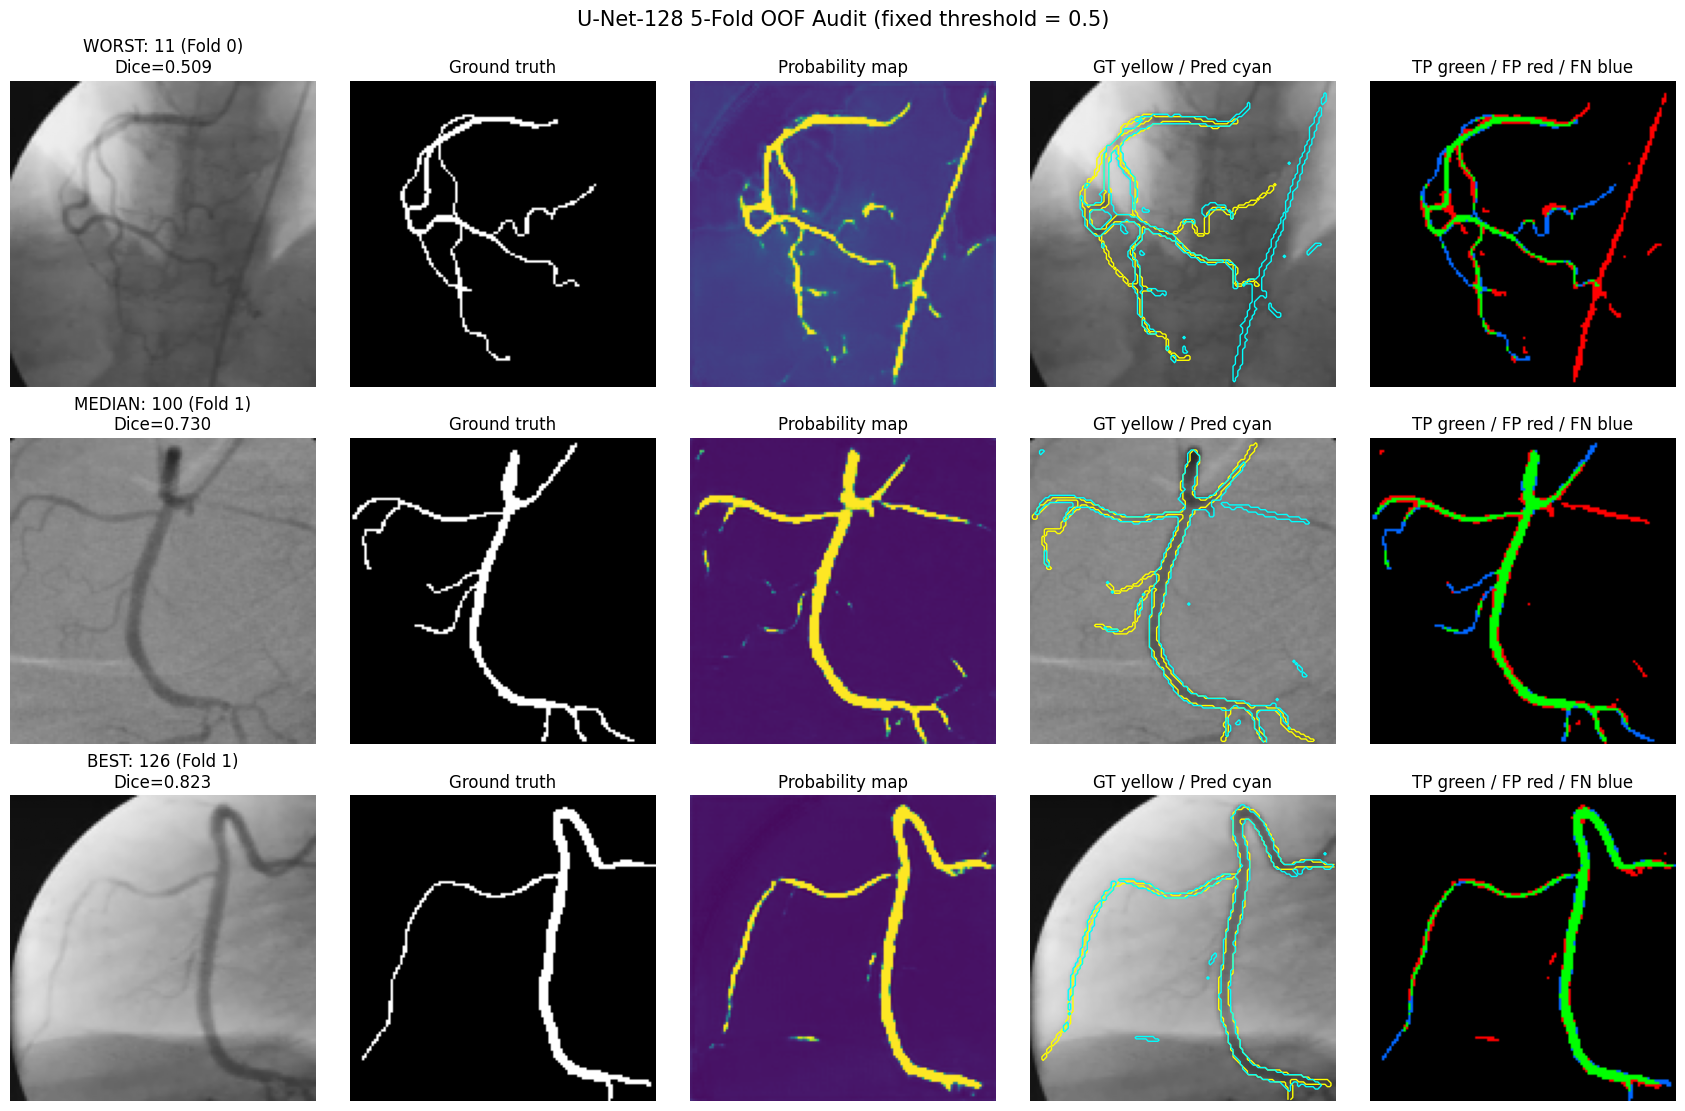


=== OOF 최종 Gate ===


,check,observed,expected,severity,status
0,oof_sample_count,134.000000,134,FAIL,PASS
1,duplicate_dataset_index,0.000000,0,FAIL,PASS
2,duplicate_sample_id,0.000000,0,FAIL,PASS
3,missing_dataset_index,0.000000,0,FAIL,PASS
4,fold_count_mismatch,0.000000,0,FAIL,PASS
5,checkpoint_fold_mismatch,0.000000,0,FAIL,PASS
6,sample_id_mismatch,0.000000,0,FAIL,PASS
7,nonfinite_probability,0.000000,0,FAIL,PASS
8,empty_prediction_count,0.000000,0,FAIL,PASS
9,fold_metric_recalculation,0.000000,<= 1e-6,FAIL,PASS



⚠️ U-Net-128 Raw OOF Gate 통과 (진단 경고 있음)
Official pooled Dice@0.5: 0.7259280017572669
Pooled Dice 95% CI: (np.float64(0.7159778417881352), np.float64(0.7357709256362193))
Macro mean Dice@0.5: 0.723326182996965
Macro Dice 95% CI: (np.float64(0.7133827683853436), np.float64(0.7330424769209376))
Diagnostic best threshold: 0.82

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/05_unet128_oof_predictions.npz
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/06_unet128_oof_per_image_metrics.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/07_unet128_oof_fold_metrics.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/08_unet128_oof_overall_metrics.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/09_unet128_oof_threshold_audit.csv
/content/drive/M

In [ ]:
#@title U-Net-128 전체 OOF 예측 및 Raw Baseline 최종 평가

import copy
import gc
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset


# ==================================================
# 1. 환경 및 경로
# ==================================================
required_variables = [
    "dca1_full_dataset",
    "full_sample_index_df",
    "unet128_model_template",
    "FIVEFOLD_DIR",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise NameError(
        "5-Fold 입력 Gate 셀을 먼저 실행하세요. "
        f"누락 변수: {missing_variables}"
    )

if "device" not in globals():
    if "DEVICE" in globals():
        device = torch.device(DEVICE)
    else:
        device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "cpu"
        )

FIVEFOLD_DIR = Path(FIVEFOLD_DIR)

TRAINING_SUMMARY_PATH = (
    FIVEFOLD_DIR
    / "03_unet128_5fold_training_summary.csv"
)

OOF_NPZ_PATH = (
    FIVEFOLD_DIR
    / "05_unet128_oof_predictions.npz"
)
OOF_PER_IMAGE_PATH = (
    FIVEFOLD_DIR
    / "06_unet128_oof_per_image_metrics.csv"
)
OOF_FOLD_METRICS_PATH = (
    FIVEFOLD_DIR
    / "07_unet128_oof_fold_metrics.csv"
)
OOF_OVERALL_METRICS_PATH = (
    FIVEFOLD_DIR
    / "08_unet128_oof_overall_metrics.csv"
)
OOF_THRESHOLD_AUDIT_PATH = (
    FIVEFOLD_DIR
    / "09_unet128_oof_threshold_audit.csv"
)
OOF_GATE_PATH = (
    FIVEFOLD_DIR
    / "10_unet128_oof_gate.csv"
)
OOF_OVERLAY_PATH = (
    FIVEFOLD_DIR
    / "11_unet128_oof_overlay.png"
)

assert TRAINING_SUMMARY_PATH.exists()
assert len(dca1_full_dataset) == 134

training_summary_df = pd.read_csv(
    TRAINING_SUMMARY_PATH
)

assert len(training_summary_df) == 5

print("Device:", device)
print("OOF output directory:", FIVEFOLD_DIR)


# ==================================================
# 2. 보조 함수
# ==================================================
def normalize_ids(
    sample_ids,
    batch_size,
):
    if sample_ids is None:
        return [None] * batch_size

    if torch.is_tensor(sample_ids):
        sample_ids = (
            sample_ids
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
            .tolist()
        )

    elif isinstance(sample_ids, np.ndarray):
        sample_ids = (
            sample_ids
            .reshape(-1)
            .tolist()
        )

    elif isinstance(sample_ids, str):
        sample_ids = [sample_ids]

    else:
        sample_ids = list(sample_ids)

    return [
        str(sample_id)
        for sample_id in sample_ids
    ]


def calculate_metrics(
    probabilities,
    targets,
    threshold=0.5,
    eps=1e-7,
):
    predictions = (
        probabilities >= threshold
    )
    targets = (
        targets >= 0.5
    )

    tp = float(
        np.logical_and(
            predictions,
            targets,
        ).sum()
    )
    fp = float(
        np.logical_and(
            predictions,
            ~targets,
        ).sum()
    )
    fn = float(
        np.logical_and(
            ~predictions,
            targets,
        ).sum()
    )
    tn = float(
        np.logical_and(
            ~predictions,
            ~targets,
        ).sum()
    )

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "dice": (
            (2 * tp + eps)
            / (2 * tp + fp + fn + eps)
        ),
        "iou": (
            (tp + eps)
            / (tp + fp + fn + eps)
        ),
        "precision": (
            (tp + eps)
            / (tp + fp + eps)
        ),
        "recall": (
            (tp + eps)
            / (tp + fn + eps)
        ),
        "specificity": (
            (tn + eps)
            / (tn + fp + eps)
        ),
        "accuracy": (
            (tp + tn + eps)
            / (tp + fp + fn + tn + eps)
        ),
        "predicted_vessel_rate": float(
            predictions.mean()
        ),
        "target_vessel_rate": float(
            targets.mean()
        ),
    }


def component_statistics(binary_mask):
    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)

    label_count, labels = (
        cv2.connectedComponents(
            binary_mask,
            connectivity=8,
        )
    )

    component_count = label_count - 1

    if component_count <= 0:
        return {
            "component_count": 0,
            "largest_component_coverage": 0.0,
        }

    sizes = np.bincount(
        labels.reshape(-1)
    )[1:]

    return {
        "component_count": int(
            component_count
        ),
        "largest_component_coverage": float(
            sizes.max()
            / max(sizes.sum(), 1)
        ),
    }


# ==================================================
# 3. Dataset index 참조표
# ==================================================
index_reference_df = (
    full_sample_index_df[
        [
            "dataset_index",
            "sample_id",
            "cv_fold",
        ]
    ]
    .copy()
)

index_reference_df[
    "dataset_index"
] = (
    index_reference_df[
        "dataset_index"
    ].astype(int)
)

index_reference_df[
    "sample_id"
] = (
    index_reference_df[
        "sample_id"
    ].astype(str)
)

index_reference_df[
    "cv_fold"
] = (
    index_reference_df[
        "cv_fold"
    ].astype(int)
)

reference_by_index = (
    index_reference_df
    .set_index("dataset_index")
)


# ==================================================
# 4. Fold별 OOF 예측
# ==================================================
oof_dataset_indices = []
oof_sample_ids = []
oof_folds = []
oof_checkpoint_epochs = []

oof_images = []
oof_masks = []
oof_probabilities = []

checkpoint_fold_mismatch_count = 0
sample_id_mismatch_count = 0

for fold in range(5):
    print(f"\nFold {fold} OOF 예측 중...")

    best_checkpoint_path = (
        FIVEFOLD_DIR
        / f"fold_{fold}"
        / f"fold_{fold}_best.pt"
    )

    assert best_checkpoint_path.exists(), (
        f"Fold {fold} best checkpoint 없음"
    )

    checkpoint = torch.load(
        best_checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    if int(checkpoint["fold"]) != fold:
        checkpoint_fold_mismatch_count += 1

    validation_indices = (
        index_reference_df.loc[
            index_reference_df[
                "cv_fold"
            ] == fold,
            "dataset_index",
        ]
        .astype(int)
        .tolist()
    )

    validation_subset = Subset(
        dca1_full_dataset,
        validation_indices,
    )

    validation_loader = DataLoader(
        validation_subset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=False,
    )

    fold_model = copy.deepcopy(
        unet128_model_template
    ).to(device)

    fold_model.load_state_dict(
        checkpoint["model_state_dict"]
    )
    fold_model.eval()

    fold_position = 0

    with torch.no_grad():
        for batch in validation_loader:
            if isinstance(batch, dict):
                images = batch["image"]
                masks = batch["mask"]
                raw_ids = batch.get(
                    "sample_id"
                )
            else:
                images = batch[0]
                masks = batch[1]
                raw_ids = None

            batch_size = images.shape[0]

            batch_dataset_indices = (
                validation_indices[
                    fold_position:
                    fold_position + batch_size
                ]
            )

            batch_ids = normalize_ids(
                raw_ids,
                batch_size,
            )

            expected_ids = [
                str(
                    reference_by_index.loc[
                        dataset_index,
                        "sample_id",
                    ]
                )
                for dataset_index
                in batch_dataset_indices
            ]

            for observed_id, expected_id in zip(
                batch_ids,
                expected_ids,
            ):
                if (
                    observed_id is not None
                    and observed_id
                    != expected_id
                ):
                    sample_id_mismatch_count += 1

            images_device = images.to(
                device,
                dtype=torch.float32,
                non_blocking=True,
            )

            logits = fold_model(
                images_device
            )

            probabilities = torch.sigmoid(
                logits
            )

            oof_dataset_indices.extend(
                batch_dataset_indices
            )
            oof_sample_ids.extend(
                expected_ids
            )
            oof_folds.extend(
                [fold] * batch_size
            )
            oof_checkpoint_epochs.extend(
                [
                    int(checkpoint["epoch"])
                ] * batch_size
            )

            oof_images.append(
                images.detach()
                .cpu()
                .numpy()[:, 0]
            )
            oof_masks.append(
                masks.detach()
                .cpu()
                .numpy()[:, 0]
            )
            oof_probabilities.append(
                probabilities.detach()
                .cpu()
                .numpy()[:, 0]
            )

            fold_position += batch_size

    assert fold_position == len(
        validation_indices
    )

    print(
        f"✅ Fold {fold}: "
        f"{fold_position}장, "
        f"checkpoint epoch "
        f"{checkpoint['epoch']}"
    )

    del fold_model
    del validation_loader

    gc.collect()
    torch.cuda.empty_cache()


# ==================================================
# 5. OOF 배열 병합 및 정렬
# ==================================================
oof_images = np.concatenate(
    oof_images,
    axis=0,
).astype(np.float32)

oof_masks = np.concatenate(
    oof_masks,
    axis=0,
).astype(np.float32)

oof_probabilities = np.concatenate(
    oof_probabilities,
    axis=0,
).astype(np.float32)

oof_dataset_indices = np.asarray(
    oof_dataset_indices,
    dtype=np.int64,
)
oof_sample_ids = np.asarray(
    oof_sample_ids,
    dtype=str,
)
oof_folds = np.asarray(
    oof_folds,
    dtype=np.int64,
)
oof_checkpoint_epochs = np.asarray(
    oof_checkpoint_epochs,
    dtype=np.int64,
)

sort_order = np.argsort(
    oof_dataset_indices
)

oof_dataset_indices = (
    oof_dataset_indices[sort_order]
)
oof_sample_ids = (
    oof_sample_ids[sort_order]
)
oof_folds = oof_folds[sort_order]
oof_checkpoint_epochs = (
    oof_checkpoint_epochs[sort_order]
)

oof_images = oof_images[sort_order]
oof_masks = oof_masks[sort_order]
oof_probabilities = (
    oof_probabilities[sort_order]
)

assert oof_images.shape == (
    134,
    128,
    128,
)
assert oof_masks.shape == (
    134,
    128,
    128,
)
assert oof_probabilities.shape == (
    134,
    128,
    128,
)

print(
    "\nOOF probability range:",
    oof_probabilities.min(),
    oof_probabilities.max(),
)


# ==================================================
# 6. 이미지별 공식 지표 — threshold 0.5
# ==================================================
PRIMARY_THRESHOLD = 0.5

per_image_rows = []

for array_index in range(134):
    probability = (
        oof_probabilities[array_index]
    )
    target = oof_masks[array_index]

    metrics = calculate_metrics(
        probability,
        target,
        threshold=PRIMARY_THRESHOLD,
    )

    prediction = (
        probability >= PRIMARY_THRESHOLD
    ).astype(np.uint8)

    target_binary = (
        target >= 0.5
    ).astype(np.uint8)

    prediction_components = (
        component_statistics(prediction)
    )
    target_components = (
        component_statistics(
            target_binary
        )
    )

    per_image_rows.append({
        "array_index": array_index,
        "dataset_index": int(
            oof_dataset_indices[
                array_index
            ]
        ),
        "sample_id": str(
            oof_sample_ids[array_index]
        ),
        "cv_fold": int(
            oof_folds[array_index]
        ),
        "checkpoint_epoch": int(
            oof_checkpoint_epochs[
                array_index
            ]
        ),
        "dice_at_0_5": metrics["dice"],
        "iou_at_0_5": metrics["iou"],
        "precision_at_0_5": (
            metrics["precision"]
        ),
        "recall_at_0_5": (
            metrics["recall"]
        ),
        "specificity_at_0_5": (
            metrics["specificity"]
        ),
        "accuracy_at_0_5": (
            metrics["accuracy"]
        ),
        "tp": metrics["tp"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tn": metrics["tn"],
        "target_vessel_rate": (
            metrics["target_vessel_rate"]
        ),
        "predicted_vessel_rate": (
            metrics[
                "predicted_vessel_rate"
            ]
        ),
        "vessel_rate_absolute_error": abs(
            metrics[
                "predicted_vessel_rate"
            ]
            - metrics[
                "target_vessel_rate"
            ]
        ),
        "gt_component_count": (
            target_components[
                "component_count"
            ]
        ),
        "prediction_component_count": (
            prediction_components[
                "component_count"
            ]
        ),
        "prediction_largest_component_coverage": (
            prediction_components[
                "largest_component_coverage"
            ]
        ),
        "empty_prediction": int(
            prediction.sum() == 0
        ),
    })

oof_per_image_df = pd.DataFrame(
    per_image_rows
)

oof_per_image_df.to_csv(
    OOF_PER_IMAGE_PATH,
    index=False,
)


# ==================================================
# 7. Fold별 OOF 재계산
# ==================================================
fold_metric_rows = []

for fold in range(5):
    fold_mask = (
        oof_folds == fold
    )

    fold_metrics = calculate_metrics(
        oof_probabilities[fold_mask],
        oof_masks[fold_mask],
        threshold=PRIMARY_THRESHOLD,
    )

    fold_image_metrics = (
        oof_per_image_df.loc[
            oof_per_image_df[
                "cv_fold"
            ] == fold
        ]
    )

    expected_training_row = (
        training_summary_df.loc[
            training_summary_df[
                "fold"
            ] == fold
        ]
        .iloc[0]
    )

    expected_dice = float(
        expected_training_row[
            "dice_at_best_loss_epoch"
        ]
    )

    dice_difference = abs(
        fold_metrics["dice"]
        - expected_dice
    )

    fold_metric_rows.append({
        "fold": fold,
        "sample_count": int(
            fold_mask.sum()
        ),
        "pooled_dice_at_0_5": (
            fold_metrics["dice"]
        ),
        "pooled_iou_at_0_5": (
            fold_metrics["iou"]
        ),
        "pooled_precision_at_0_5": (
            fold_metrics["precision"]
        ),
        "pooled_recall_at_0_5": (
            fold_metrics["recall"]
        ),
        "pooled_specificity_at_0_5": (
            fold_metrics["specificity"]
        ),
        "macro_mean_dice_at_0_5": float(
            fold_image_metrics[
                "dice_at_0_5"
            ].mean()
        ),
        "macro_median_dice_at_0_5": float(
            fold_image_metrics[
                "dice_at_0_5"
            ].median()
        ),
        "recorded_checkpoint_dice": (
            expected_dice
        ),
        "dice_recalculation_difference": (
            dice_difference
        ),
    })

oof_fold_metrics_df = pd.DataFrame(
    fold_metric_rows
)

oof_fold_metrics_df.to_csv(
    OOF_FOLD_METRICS_PATH,
    index=False,
)

print("\n=== Fold별 OOF 재계산 ===")
display(oof_fold_metrics_df)


# ==================================================
# 8. 전체 OOF 공식 성능
# ==================================================
overall_metrics = calculate_metrics(
    oof_probabilities,
    oof_masks,
    threshold=PRIMARY_THRESHOLD,
)

macro_dice_values = (
    oof_per_image_df[
        "dice_at_0_5"
    ].to_numpy()
)


# ==================================================
# 9. 이미지 단위 bootstrap 95% CI
# ==================================================
BOOTSTRAP_REPETITIONS = 10_000
bootstrap_rng = np.random.default_rng(42)

tp_array = (
    oof_per_image_df["tp"].to_numpy()
)
fp_array = (
    oof_per_image_df["fp"].to_numpy()
)
fn_array = (
    oof_per_image_df["fn"].to_numpy()
)

bootstrap_indices = (
    bootstrap_rng.integers(
        low=0,
        high=134,
        size=(
            BOOTSTRAP_REPETITIONS,
            134,
        ),
    )
)

bootstrap_tp = (
    tp_array[bootstrap_indices].sum(
        axis=1
    )
)
bootstrap_fp = (
    fp_array[bootstrap_indices].sum(
        axis=1
    )
)
bootstrap_fn = (
    fn_array[bootstrap_indices].sum(
        axis=1
    )
)

bootstrap_pooled_dice = (
    (2 * bootstrap_tp + 1e-7)
    / (
        2 * bootstrap_tp
        + bootstrap_fp
        + bootstrap_fn
        + 1e-7
    )
)

bootstrap_macro_dice = (
    macro_dice_values[
        bootstrap_indices
    ].mean(axis=1)
)

pooled_dice_ci = np.percentile(
    bootstrap_pooled_dice,
    [2.5, 97.5],
)

macro_dice_ci = np.percentile(
    bootstrap_macro_dice,
    [2.5, 97.5],
)


# ==================================================
# 10. 전체 성능표
# ==================================================
overall_metric_rows = [
    {
        "metric": "pooled_dice_at_0_5",
        "value": overall_metrics["dice"],
        "ci_95_lower": (
            pooled_dice_ci[0]
        ),
        "ci_95_upper": (
            pooled_dice_ci[1]
        ),
    },
    {
        "metric": "pooled_iou_at_0_5",
        "value": overall_metrics["iou"],
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "pooled_precision_at_0_5",
        "value": (
            overall_metrics["precision"]
        ),
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "pooled_recall_at_0_5",
        "value": overall_metrics["recall"],
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "pooled_specificity_at_0_5",
        "value": (
            overall_metrics["specificity"]
        ),
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "macro_mean_dice_at_0_5",
        "value": float(
            macro_dice_values.mean()
        ),
        "ci_95_lower": (
            macro_dice_ci[0]
        ),
        "ci_95_upper": (
            macro_dice_ci[1]
        ),
    },
    {
        "metric": "macro_median_dice_at_0_5",
        "value": float(
            np.median(
                macro_dice_values
            )
        ),
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "macro_std_dice_at_0_5",
        "value": float(
            macro_dice_values.std(
                ddof=1
            )
        ),
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "minimum_image_dice_at_0_5",
        "value": float(
            macro_dice_values.min()
        ),
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
    {
        "metric": "maximum_image_dice_at_0_5",
        "value": float(
            macro_dice_values.max()
        ),
        "ci_95_lower": np.nan,
        "ci_95_upper": np.nan,
    },
]

oof_overall_metrics_df = pd.DataFrame(
    overall_metric_rows
)

oof_overall_metrics_df.to_csv(
    OOF_OVERALL_METRICS_PATH,
    index=False,
)

print("\n=== 전체 OOF 공식 성능 ===")
display(oof_overall_metrics_df)


# ==================================================
# 11. OOF threshold sweep — 진단 전용
# ==================================================
threshold_rows = []

for threshold in np.round(
    np.arange(0.05, 0.951, 0.01),
    2,
):
    pooled_metrics = calculate_metrics(
        oof_probabilities,
        oof_masks,
        threshold=float(threshold),
    )

    image_dice = []

    for image_index in range(134):
        image_metrics = calculate_metrics(
            oof_probabilities[
                image_index
            ],
            oof_masks[image_index],
            threshold=float(threshold),
        )

        image_dice.append(
            image_metrics["dice"]
        )

    threshold_rows.append({
        "threshold": float(threshold),
        "pooled_dice": (
            pooled_metrics["dice"]
        ),
        "pooled_iou": (
            pooled_metrics["iou"]
        ),
        "pooled_precision": (
            pooled_metrics["precision"]
        ),
        "pooled_recall": (
            pooled_metrics["recall"]
        ),
        "macro_mean_dice": float(
            np.mean(image_dice)
        ),
        "macro_median_dice": float(
            np.median(image_dice)
        ),
        "predicted_vessel_rate": (
            pooled_metrics[
                "predicted_vessel_rate"
            ]
        ),
        "target_vessel_rate": (
            pooled_metrics[
                "target_vessel_rate"
            ]
        ),
    })

oof_threshold_audit_df = (
    pd.DataFrame(threshold_rows)
)

oof_threshold_audit_df.to_csv(
    OOF_THRESHOLD_AUDIT_PATH,
    index=False,
)

diagnostic_best_threshold_row = (
    oof_threshold_audit_df
    .sort_values(
        [
            "pooled_dice",
            "macro_mean_dice",
        ],
        ascending=False,
    )
    .iloc[0]
)

print("\n=== OOF 진단용 최고 threshold ===")
display(
    diagnostic_best_threshold_row
    .to_frame()
    .T
)

print(
    "※ 공식 성능은 threshold 0.5이며, "
    "OOF 최적 threshold 성능은 "
    "최종 결과로 보고하지 않습니다."
)


# ==================================================
# 12. OOF 확률맵 저장
# ==================================================
np.savez_compressed(
    OOF_NPZ_PATH,
    dataset_indices=(
        oof_dataset_indices
    ),
    sample_ids=oof_sample_ids,
    cv_folds=oof_folds,
    checkpoint_epochs=(
        oof_checkpoint_epochs
    ),
    images_uint8=np.clip(
        np.rint(oof_images * 255),
        0,
        255,
    ).astype(np.uint8),
    masks_uint8=(
        oof_masks >= 0.5
    ).astype(np.uint8),
    probabilities_float16=(
        oof_probabilities.astype(
            np.float16
        )
    ),
)


# ==================================================
# 13. Best / Median / Worst OOF 시각화
# ==================================================
sorted_image_metrics_df = (
    oof_per_image_df
    .sort_values("dice_at_0_5")
    .reset_index(drop=True)
)

selected_cases = {
    "WORST": (
        sorted_image_metrics_df.iloc[0]
    ),
    "MEDIAN": (
        sorted_image_metrics_df.iloc[
            len(sorted_image_metrics_df)
            // 2
        ]
    ),
    "BEST": (
        sorted_image_metrics_df.iloc[-1]
    ),
}

fig, axes = plt.subplots(
    3,
    5,
    figsize=(17, 11),
    constrained_layout=True,
)

for row_index, (
    case_name,
    case_row,
) in enumerate(selected_cases.items()):
    array_index = int(
        case_row["array_index"]
    )

    image = oof_images[array_index]
    target = (
        oof_masks[array_index] >= 0.5
    )
    probability = (
        oof_probabilities[array_index]
    )
    prediction = (
        probability >= 0.5
    )

    tp = np.logical_and(
        prediction,
        target,
    )
    fp = np.logical_and(
        prediction,
        ~target,
    )
    fn = np.logical_and(
        ~prediction,
        target,
    )

    error_map = np.zeros(
        (*target.shape, 3),
        dtype=np.float32,
    )
    error_map[tp] = [0.0, 1.0, 0.0]
    error_map[fp] = [1.0, 0.0, 0.0]
    error_map[fn] = [0.0, 0.4, 1.0]

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 0].set_title(
        f"{case_name}: "
        f"{case_row['sample_id']} "
        f"(Fold {case_row['cv_fold']})\n"
        f"Dice="
        f"{case_row['dice_at_0_5']:.3f}"
    )

    axes[row_index, 1].imshow(
        target,
        cmap="gray",
    )
    axes[row_index, 1].set_title(
        "Ground truth"
    )

    axes[row_index, 2].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 2].set_title(
        "Probability map"
    )

    axes[row_index, 3].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 3].contour(
        target.astype(np.uint8),
        levels=[0.5],
        colors=["yellow"],
        linewidths=1,
    )
    axes[row_index, 3].contour(
        prediction.astype(np.uint8),
        levels=[0.5],
        colors=["cyan"],
        linewidths=1,
    )
    axes[row_index, 3].set_title(
        "GT yellow / Pred cyan"
    )

    axes[row_index, 4].imshow(
        error_map
    )
    axes[row_index, 4].set_title(
        "TP green / FP red / FN blue"
    )

    for column_index in range(5):
        axes[
            row_index,
            column_index
        ].axis("off")

fig.suptitle(
    "U-Net-128 5-Fold OOF Audit "
    "(fixed threshold = 0.5)",
    fontsize=15,
)

plt.savefig(
    OOF_OVERLAY_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# ==================================================
# 14. 최종 OOF Gate
# ==================================================
duplicate_dataset_index_count = int(
    pd.Series(
        oof_dataset_indices
    ).duplicated().sum()
)

duplicate_sample_id_count = int(
    pd.Series(
        oof_sample_ids
    ).duplicated().sum()
)

missing_dataset_index_count = len(
    set(range(134))
    - set(
        oof_dataset_indices.tolist()
    )
)

nonfinite_probability_count = int(
    (~np.isfinite(
        oof_probabilities
    )).sum()
)

empty_prediction_count = int(
    oof_per_image_df[
        "empty_prediction"
    ].sum()
)

fold_count_mismatch = int(
    not (
        oof_per_image_df
        .groupby("cv_fold")
        .size()
        .to_dict()
        == {
            0: 27,
            1: 27,
            2: 27,
            3: 27,
            4: 26,
        }
    )
)

max_fold_metric_difference = float(
    oof_fold_metrics_df[
        "dice_recalculation_difference"
    ].max()
)

official_pooled_dice = float(
    overall_metrics["dice"]
)

official_macro_median_dice = float(
    np.median(macro_dice_values)
)

diagnostic_threshold = float(
    diagnostic_best_threshold_row[
        "threshold"
    ]
)

threshold_shift = abs(
    diagnostic_threshold - 0.5
)

gate_rows = [
    {
        "check": "oof_sample_count",
        "observed": len(
            oof_sample_ids
        ),
        "expected": 134,
        "severity": "FAIL",
    },
    {
        "check": "duplicate_dataset_index",
        "observed": (
            duplicate_dataset_index_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "duplicate_sample_id",
        "observed": (
            duplicate_sample_id_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "missing_dataset_index",
        "observed": (
            missing_dataset_index_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "fold_count_mismatch",
        "observed": (
            fold_count_mismatch
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "checkpoint_fold_mismatch",
        "observed": (
            checkpoint_fold_mismatch_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "sample_id_mismatch",
        "observed": (
            sample_id_mismatch_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "nonfinite_probability",
        "observed": (
            nonfinite_probability_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "empty_prediction_count",
        "observed": (
            empty_prediction_count
        ),
        "expected": 0,
        "severity": "FAIL",
    },
    {
        "check": "fold_metric_recalculation",
        "observed": (
            max_fold_metric_difference
        ),
        "expected": "<= 1e-6",
        "severity": "FAIL",
    },
    {
        "check": "official_pooled_dice",
        "observed": (
            official_pooled_dice
        ),
        "expected": ">= 0.70",
        "severity": "FAIL",
    },
    {
        "check": "macro_median_dice",
        "observed": (
            official_macro_median_dice
        ),
        "expected": ">= 0.60",
        "severity": "FAIL",
    },
    {
        "check": "diagnostic_threshold_shift",
        "observed": threshold_shift,
        "expected": "<= 0.20",
        "severity": "WARNING",
    },
]

oof_gate_df = pd.DataFrame(
    gate_rows
)


def evaluate_gate_row(row):
    if isinstance(
        row["expected"],
        (int, float, np.integer, np.floating),
    ):
        passed = (
            row["observed"]
            == row["expected"]
        )

    elif row["check"] == (
        "fold_metric_recalculation"
    ):
        passed = (
            row["observed"] <= 1e-6
        )

    elif row["check"] == (
        "official_pooled_dice"
    ):
        passed = (
            row["observed"] >= 0.70
        )

    elif row["check"] == (
        "macro_median_dice"
    ):
        passed = (
            row["observed"] >= 0.60
        )

    elif row["check"] == (
        "diagnostic_threshold_shift"
    ):
        passed = (
            row["observed"] <= 0.20
        )

    else:
        passed = False

    if passed:
        return "PASS"

    return row["severity"]


oof_gate_df["status"] = (
    oof_gate_df.apply(
        evaluate_gate_row,
        axis=1,
    )
)

oof_gate_df.to_csv(
    OOF_GATE_PATH,
    index=False,
)

print("\n=== OOF 최종 Gate ===")
display(oof_gate_df)

failed_gate_count = int(
    (oof_gate_df["status"] == "FAIL")
    .sum()
)
warning_gate_count = int(
    (
        oof_gate_df["status"]
        == "WARNING"
    ).sum()
)

if failed_gate_count > 0:
    print(
        f"\n❌ OOF Gate 실패: "
        f"{failed_gate_count}개"
    )
elif warning_gate_count > 0:
    print(
        "\n⚠️ U-Net-128 Raw OOF Gate 통과 "
        "(진단 경고 있음)"
    )
else:
    print(
        "\n✅ U-Net-128 Raw OOF Gate 통과"
    )

print(
    "Official pooled Dice@0.5:",
    official_pooled_dice,
)
print(
    "Pooled Dice 95% CI:",
    tuple(pooled_dice_ci),
)
print(
    "Macro mean Dice@0.5:",
    macro_dice_values.mean(),
)
print(
    "Macro Dice 95% CI:",
    tuple(macro_dice_ci),
)
print(
    "Diagnostic best threshold:",
    diagnostic_threshold,
)

print("\n저장 완료:")
print(OOF_NPZ_PATH)
print(OOF_PER_IMAGE_PATH)
print(OOF_FOLD_METRICS_PATH)
print(OOF_OVERALL_METRICS_PATH)
print(OOF_THRESHOLD_AUDIT_PATH)
print(OOF_GATE_PATH)
print(OOF_OVERLAY_PATH)

if failed_gate_count > 0:
    raise AssertionError(
        "OOF 예측 또는 평가 Gate를 "
        "통과하지 못했습니다."
    )

# 후처리 실험

- Raw 모델/checkpoint/OOF 결과는 수정하지 않음
- 공식 Raw 성능은 계속 Dice 0.7259
- 후처리는 별도 폴더에 저장
- 우선 작은 connected component 제거만 검사
- 카테터 Hough 제거는 나중에 별도 실험
- GT 마스크는 절대 수정하지 않음

In [ ]:
#@title 후처리 1단계 — Small Component Removal Paired Audit

import hashlib
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd


# ==================================================
# 1. 경로
# ==================================================
if "FIVEFOLD_DIR" not in globals():
    PROJECT_DIR = Path(
        "/content/drive/MyDrive/"
        "[MacGyver]최종프로젝트/"
        "03_data/AngioCAD"
    )

    FIVEFOLD_DIR = (
        PROJECT_DIR
        / "dca1_results"
        / "unet128_5fold_raw"
    )

FIVEFOLD_DIR = Path(FIVEFOLD_DIR)

RAW_NPZ_PATH = (
    FIVEFOLD_DIR
    / "05_unet128_oof_predictions.npz"
)

RAW_OVERALL_METRICS_PATH = (
    FIVEFOLD_DIR
    / "08_unet128_oof_overall_metrics.csv"
)

POSTPROCESS_DIR = (
    FIVEFOLD_DIR
    / "postprocessing_small_components"
)
POSTPROCESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FLOAT32_PROBABILITY_PATH = (
    POSTPROCESS_DIR
    / "00_oof_probabilities_float32.npz"
)
CONFIG_PATH = (
    POSTPROCESS_DIR
    / "01_small_component_config.json"
)
SUMMARY_PATH = (
    POSTPROCESS_DIR
    / "02_small_component_summary.csv"
)
PER_IMAGE_PATH = (
    POSTPROCESS_DIR
    / "03_small_component_per_image.csv"
)
GATE_PATH = (
    POSTPROCESS_DIR
    / "04_small_component_input_gate.csv"
)

assert RAW_NPZ_PATH.exists()
assert RAW_OVERALL_METRICS_PATH.exists()


# ==================================================
# 2. OOF 자료 불러오기
# ==================================================
raw_npz = np.load(
    RAW_NPZ_PATH,
    allow_pickle=False,
)

images_uint8 = raw_npz[
    "images_uint8"
]
masks_uint8 = raw_npz[
    "masks_uint8"
]
sample_ids = raw_npz[
    "sample_ids"
].astype(str)
cv_folds = raw_npz[
    "cv_folds"
].astype(int)
dataset_indices = raw_npz[
    "dataset_indices"
].astype(int)

# 현재 세션의 원본 float32 확률을 우선 사용
if (
    "oof_probabilities" in globals()
    and isinstance(
        oof_probabilities,
        np.ndarray,
    )
    and oof_probabilities.shape
    == (134, 128, 128)
):
    probabilities = (
        oof_probabilities
        .astype(np.float32)
        .copy()
    )

    probability_source = (
        "IN_MEMORY_FLOAT32"
    )
    raw_metric_tolerance = 1e-8

else:
    probabilities = raw_npz[
        "probabilities_float16"
    ].astype(np.float32)

    probability_source = (
        "SAVED_FLOAT16_RECOVERED"
    )
    raw_metric_tolerance = 1e-4

assert images_uint8.shape == (
    134,
    128,
    128,
)
assert masks_uint8.shape == (
    134,
    128,
    128,
)
assert probabilities.shape == (
    134,
    128,
    128,
)

nonfinite_probability_count = int(
    (~np.isfinite(probabilities)).sum()
)

assert nonfinite_probability_count == 0

print(
    "Probability source:",
    probability_source,
)
print(
    "Probability range:",
    probabilities.min(),
    probabilities.max(),
)


# ==================================================
# 3. 원본 float32 확률 장기 저장
# ==================================================
np.savez_compressed(
    FLOAT32_PROBABILITY_PATH,
    probabilities_float32=(
        probabilities.astype(np.float32)
    ),
    sample_ids=sample_ids,
    cv_folds=cv_folds,
    dataset_indices=dataset_indices,
)

probability_sha256 = hashlib.sha256(
    probabilities
    .astype(np.float32)
    .tobytes()
).hexdigest()

print(
    "Float32 probability SHA-256:",
    probability_sha256,
)


# ==================================================
# 4. 실험 설정
# ==================================================
PRIMARY_THRESHOLD = 0.5

# size 미만의 component를 제거
MIN_COMPONENT_SIZES = [
    0,   # Raw: 제거 없음
    2,
    4,
    8,
    16,
    32,
    64,
]

POSTPROCESS_CONFIG = {
    "experiment": (
        "UNET128_OOF_SMALL_COMPONENT_AUDIT"
    ),
    "primary_threshold": (
        PRIMARY_THRESHOLD
    ),
    "connectivity": 8,
    "minimum_component_sizes": (
        MIN_COMPONENT_SIZES
    ),
    "component_rule": (
        "remove components with "
        "pixel area < minimum_component_size"
    ),
    "resolution": "128x128",
    "ground_truth_modified": False,
    "raw_baseline_modified": False,
    "candidate_selection": (
        "diagnostic only; no automatic adoption"
    ),
    "probability_source": (
        probability_source
    ),
    "probability_sha256": (
        probability_sha256
    ),
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        POSTPROCESS_CONFIG,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ==================================================
# 5. Metric 함수
# ==================================================
def calculate_binary_metrics(
    predictions,
    targets,
    eps=1e-7,
):
    predictions = (
        predictions > 0
    )
    targets = (
        targets > 0
    )

    tp = float(
        np.logical_and(
            predictions,
            targets,
        ).sum()
    )
    fp = float(
        np.logical_and(
            predictions,
            ~targets,
        ).sum()
    )
    fn = float(
        np.logical_and(
            ~predictions,
            targets,
        ).sum()
    )
    tn = float(
        np.logical_and(
            ~predictions,
            ~targets,
        ).sum()
    )

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "dice": (
            (2 * tp + eps)
            / (2 * tp + fp + fn + eps)
        ),
        "iou": (
            (tp + eps)
            / (tp + fp + fn + eps)
        ),
        "precision": (
            (tp + eps)
            / (tp + fp + eps)
        ),
        "recall": (
            (tp + eps)
            / (tp + fn + eps)
        ),
        "specificity": (
            (tn + eps)
            / (tn + fp + eps)
        ),
        "predicted_vessel_rate": float(
            predictions.mean()
        ),
        "target_vessel_rate": float(
            targets.mean()
        ),
    }


# ==================================================
# 6. Small component 제거
# ==================================================
def remove_small_components(
    binary_mask,
    minimum_component_size,
):
    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)

    if minimum_component_size <= 1:
        return binary_mask.copy()

    label_count, labels, statistics, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8,
        )
    )

    cleaned_mask = np.zeros_like(
        binary_mask,
        dtype=np.uint8,
    )

    for component_label in range(
        1,
        label_count,
    ):
        component_area = int(
            statistics[
                component_label,
                cv2.CC_STAT_AREA,
            ]
        )

        if (
            component_area
            >= minimum_component_size
        ):
            cleaned_mask[
                labels == component_label
            ] = 1

    return cleaned_mask


def calculate_component_statistics(
    binary_mask,
):
    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)

    label_count, labels = (
        cv2.connectedComponents(
            binary_mask,
            connectivity=8,
        )
    )

    component_count = (
        label_count - 1
    )

    if component_count <= 0:
        return {
            "component_count": 0,
            "largest_component_coverage": 0.0,
        }

    component_sizes = np.bincount(
        labels.reshape(-1)
    )[1:]

    return {
        "component_count": int(
            component_count
        ),
        "largest_component_coverage": float(
            component_sizes.max()
            / max(
                component_sizes.sum(),
                1,
            )
        ),
    }


# ==================================================
# 7. Raw prediction과 후보별 paired audit
# ==================================================
raw_predictions = (
    probabilities >= PRIMARY_THRESHOLD
).astype(np.uint8)

target_masks = (
    masks_uint8 > 0
).astype(np.uint8)

raw_image_dice = []

for image_index in range(134):
    raw_metrics = calculate_binary_metrics(
        raw_predictions[image_index],
        target_masks[image_index],
    )

    raw_image_dice.append(
        raw_metrics["dice"]
    )

raw_image_dice = np.asarray(
    raw_image_dice,
    dtype=np.float64,
)

summary_rows = []
per_image_rows = []

candidate_prediction_arrays = {}

for minimum_component_size in (
    MIN_COMPONENT_SIZES
):
    cleaned_predictions = np.stack([
        remove_small_components(
            raw_predictions[image_index],
            minimum_component_size,
        )
        for image_index in range(134)
    ])

    candidate_prediction_arrays[
        minimum_component_size
    ] = cleaned_predictions

    pooled_metrics = (
        calculate_binary_metrics(
            cleaned_predictions,
            target_masks,
        )
    )

    candidate_image_dice = []
    removed_pixel_counts = []
    component_counts = []
    largest_component_coverages = []
    empty_prediction_count = 0

    for image_index in range(134):
        cleaned_mask = (
            cleaned_predictions[
                image_index
            ]
        )
        raw_mask = (
            raw_predictions[
                image_index
            ]
        )
        target_mask = (
            target_masks[
                image_index
            ]
        )

        image_metrics = (
            calculate_binary_metrics(
                cleaned_mask,
                target_mask,
            )
        )

        component_metrics = (
            calculate_component_statistics(
                cleaned_mask
            )
        )

        image_dice = (
            image_metrics["dice"]
        )
        dice_delta = (
            image_dice
            - raw_image_dice[
                image_index
            ]
        )

        removed_pixel_count = int(
            raw_mask.sum()
            - cleaned_mask.sum()
        )

        candidate_image_dice.append(
            image_dice
        )
        removed_pixel_counts.append(
            removed_pixel_count
        )
        component_counts.append(
            component_metrics[
                "component_count"
            ]
        )
        largest_component_coverages.append(
            component_metrics[
                "largest_component_coverage"
            ]
        )

        if cleaned_mask.sum() == 0:
            empty_prediction_count += 1

        per_image_rows.append({
            "minimum_component_size": (
                minimum_component_size
            ),
            "array_index": image_index,
            "dataset_index": int(
                dataset_indices[
                    image_index
                ]
            ),
            "sample_id": str(
                sample_ids[image_index]
            ),
            "cv_fold": int(
                cv_folds[image_index]
            ),
            "raw_dice_at_0_5": float(
                raw_image_dice[
                    image_index
                ]
            ),
            "postprocessed_dice": float(
                image_dice
            ),
            "dice_delta": float(
                dice_delta
            ),
            "postprocessed_iou": (
                image_metrics["iou"]
            ),
            "postprocessed_precision": (
                image_metrics["precision"]
            ),
            "postprocessed_recall": (
                image_metrics["recall"]
            ),
            "removed_pixel_count": (
                removed_pixel_count
            ),
            "component_count": (
                component_metrics[
                    "component_count"
                ]
            ),
            "largest_component_coverage": (
                component_metrics[
                    "largest_component_coverage"
                ]
            ),
            "empty_prediction": int(
                cleaned_mask.sum() == 0
            ),
        })

    candidate_image_dice = np.asarray(
        candidate_image_dice,
        dtype=np.float64,
    )

    dice_delta_array = (
        candidate_image_dice
        - raw_image_dice
    )

    # Paired bootstrap: 이미지 단위 평균 Dice 변화
    bootstrap_rng = (
        np.random.default_rng(
            42 + minimum_component_size
        )
    )

    bootstrap_indices = (
        bootstrap_rng.integers(
            low=0,
            high=134,
            size=(10_000, 134),
        )
    )

    bootstrap_mean_delta = (
        dice_delta_array[
            bootstrap_indices
        ].mean(axis=1)
    )

    delta_ci_lower, delta_ci_upper = (
        np.percentile(
            bootstrap_mean_delta,
            [2.5, 97.5],
        )
    )

    improved_count = int(
        (
            dice_delta_array
            > 1e-12
        ).sum()
    )
    worsened_count = int(
        (
            dice_delta_array
            < -1e-12
        ).sum()
    )
    unchanged_count = int(
        134
        - improved_count
        - worsened_count
    )

    summary_rows.append({
        "minimum_component_size": (
            minimum_component_size
        ),
        "pooled_dice": (
            pooled_metrics["dice"]
        ),
        "pooled_iou": (
            pooled_metrics["iou"]
        ),
        "pooled_precision": (
            pooled_metrics["precision"]
        ),
        "pooled_recall": (
            pooled_metrics["recall"]
        ),
        "pooled_specificity": (
            pooled_metrics["specificity"]
        ),
        "macro_mean_dice": float(
            candidate_image_dice.mean()
        ),
        "macro_median_dice": float(
            np.median(
                candidate_image_dice
            )
        ),
        "macro_std_dice": float(
            candidate_image_dice.std(
                ddof=1
            )
        ),
        "mean_dice_delta": float(
            dice_delta_array.mean()
        ),
        "median_dice_delta": float(
            np.median(
                dice_delta_array
            )
        ),
        "delta_ci_95_lower": float(
            delta_ci_lower
        ),
        "delta_ci_95_upper": float(
            delta_ci_upper
        ),
        "minimum_dice_delta": float(
            dice_delta_array.min()
        ),
        "maximum_dice_delta": float(
            dice_delta_array.max()
        ),
        "improved_image_count": (
            improved_count
        ),
        "worsened_image_count": (
            worsened_count
        ),
        "unchanged_image_count": (
            unchanged_count
        ),
        "mean_removed_pixel_count": float(
            np.mean(
                removed_pixel_counts
            )
        ),
        "mean_component_count": float(
            np.mean(component_counts)
        ),
        "mean_largest_component_coverage": float(
            np.mean(
                largest_component_coverages
            )
        ),
        "empty_prediction_count": (
            empty_prediction_count
        ),
        "predicted_vessel_rate": (
            pooled_metrics[
                "predicted_vessel_rate"
            ]
        ),
        "target_vessel_rate": (
            pooled_metrics[
                "target_vessel_rate"
            ]
        ),
    })


small_component_summary_df = (
    pd.DataFrame(summary_rows)
)

small_component_per_image_df = (
    pd.DataFrame(per_image_rows)
)

small_component_summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
)

small_component_per_image_df.to_csv(
    PER_IMAGE_PATH,
    index=False,
)


# ==================================================
# 8. Raw 공식 결과와 재현성 비교
# ==================================================
raw_overall_metrics_df = pd.read_csv(
    RAW_OVERALL_METRICS_PATH
)

official_raw_dice = float(
    raw_overall_metrics_df.loc[
        raw_overall_metrics_df[
            "metric"
        ] == "pooled_dice_at_0_5",
        "value",
    ].iloc[0]
)

recalculated_raw_dice = float(
    small_component_summary_df.loc[
        small_component_summary_df[
            "minimum_component_size"
        ] == 0,
        "pooled_dice",
    ].iloc[0]
)

raw_dice_difference = abs(
    official_raw_dice
    - recalculated_raw_dice
)


# ==================================================
# 9. 입력 및 결과 Gate
# ==================================================
binary_output_error_count = 0

for minimum_size, prediction_array in (
    candidate_prediction_arrays.items()
):
    unique_values = set(
        np.unique(
            prediction_array
        ).tolist()
    )

    if not unique_values.issubset(
        {0, 1}
    ):
        binary_output_error_count += 1

gate_rows = [
    {
        "check": "sample_count",
        "observed": (
            len(sample_ids)
        ),
        "expected": 134,
        "status": (
            "PASS"
            if len(sample_ids) == 134
            else "FAIL"
        ),
    },
    {
        "check": "nonfinite_probability_count",
        "observed": (
            nonfinite_probability_count
        ),
        "expected": 0,
        "status": (
            "PASS"
            if nonfinite_probability_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "raw_dice_recalculation_difference",
        "observed": (
            raw_dice_difference
        ),
        "expected": (
            f"<= {raw_metric_tolerance}"
        ),
        "status": (
            "PASS"
            if raw_dice_difference
            <= raw_metric_tolerance
            else "FAIL"
        ),
    },
    {
        "check": "binary_output_error_count",
        "observed": (
            binary_output_error_count
        ),
        "expected": 0,
        "status": (
            "PASS"
            if binary_output_error_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "ground_truth_modified",
        "observed": 0,
        "expected": 0,
        "status": "PASS",
    },
]

postprocess_gate_df = pd.DataFrame(
    gate_rows
)

postprocess_gate_df.to_csv(
    GATE_PATH,
    index=False,
)


# ==================================================
# 10. 결과 출력
# ==================================================
print("\n=== Small Component 후보 비교 ===")

display(
    small_component_summary_df[
        [
            "minimum_component_size",
            "pooled_dice",
            "pooled_precision",
            "pooled_recall",
            "macro_mean_dice",
            "mean_dice_delta",
            "delta_ci_95_lower",
            "delta_ci_95_upper",
            "improved_image_count",
            "worsened_image_count",
            "unchanged_image_count",
            "mean_component_count",
            "empty_prediction_count",
        ]
    ]
)

diagnostic_best_candidate = (
    small_component_summary_df
    .sort_values(
        [
            "pooled_dice",
            "macro_mean_dice",
        ],
        ascending=False,
    )
    .iloc[0]
)

print("\n=== 진단상 최고 후보 ===")
display(
    diagnostic_best_candidate
    .to_frame()
    .T
)

print(
    "※ 아직 이 후보를 채택하지 않습니다. "
    "개별 악화 사례를 먼저 확인합니다."
)

print("\n=== 후처리 입력 Gate ===")
display(postprocess_gate_df)

failed_gate_count = int(
    (
        postprocess_gate_df[
            "status"
        ] == "FAIL"
    ).sum()
)

if failed_gate_count > 0:
    raise AssertionError(
        "Small component audit Gate 실패"
    )

print(
    "\n✅ Small component removal "
    "paired audit 완료"
)

print("\n저장 완료:")
print(FLOAT32_PROBABILITY_PATH)
print(CONFIG_PATH)
print(SUMMARY_PATH)
print(PER_IMAGE_PATH)
print(GATE_PATH)

Probability source: IN_MEMORY_FLOAT32
Probability range: 0.015279082 1.0
Float32 probability SHA-256: 4b5731b6077d3f3c0389d5cf5f0c1506625e7a3113890fcc91fb0175449de23a

=== Small Component 후보 비교 ===


,minimum_component_size,pooled_dice,pooled_precision,pooled_recall,macro_mean_dice,mean_dice_delta,delta_ci_95_lower,delta_ci_95_upper,improved_image_count,worsened_image_count,unchanged_image_count,mean_component_count,empty_prediction_count
0,0,0.725928,0.665313,0.798695,0.723326,0.000000,0.000000,0.000000,0,0,134,14.753731,0
1,2,0.726505,0.666678,0.798128,0.723895,0.000569,0.000416,0.000724,95,24,15,11.791045,0
2,4,0.727692,0.670061,0.796170,0.725144,0.001817,0.001346,0.002287,98,36,0,8.477612,0
3,8,0.730547,0.677356,0.792803,0.727974,0.004648,0.003708,0.005587,106,28,0,5.425373,0
4,16,0.732256,0.685851,0.785395,0.729695,0.006369,0.004702,0.008038,103,31,0,3.373134,0
5,32,0.732281,0.693869,0.775195,0.729424,0.006098,0.003527,0.008732,92,42,0,2.223881,0
6,64,0.729295,0.702940,0.757704,0.726291,0.002965,-0.001337,0.007055,78,56,0,1.455224,0



=== 진단상 최고 후보 ===


,minimum_component_size,pooled_dice,pooled_iou,pooled_precision,pooled_recall,pooled_specificity,macro_mean_dice,macro_median_dice,macro_std_dice,mean_dice_delta,...,maximum_dice_delta,improved_image_count,worsened_image_count,unchanged_image_count,mean_removed_pixel_count,mean_component_count,mean_largest_component_coverage,empty_prediction_count,predicted_vessel_rate,target_vessel_rate
5,32.0,0.732281,0.577637,0.693869,0.775195,0.980225,0.729424,0.733734,0.060014,0.006098,...,0.046032,92.0,42.0,0.0,74.574627,2.223881,0.906277,0.0,0.061066,0.054659


※ 아직 이 후보를 채택하지 않습니다. 개별 악화 사례를 먼저 확인합니다.

=== 후처리 입력 Gate ===


,check,observed,expected,status
0,sample_count,134.0,134,PASS
1,nonfinite_probability_count,0.0,0,PASS
2,raw_dice_recalculation_difference,0.0,<= 1e-08,PASS
3,binary_output_error_count,0.0,0,PASS
4,ground_truth_modified,0.0,0,PASS



✅ Small component removal paired audit 완료

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/00_oof_probabilities_float32.npz
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/01_small_component_config.json
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/02_small_component_summary.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/03_small_component_per_image.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/04_small_component_input_gate.csv


=== Candidate 16px 제거 pixel 요약 ===
전체 제거 pixel: 6641
제거된 false positive: 5045
제거된 true positive: 1596
이득 pixel 비율: 0.7596747477789489
손해 pixel 비율: 0.24032525222105106

=== 가장 개선된 5개 영상 ===


,array_index,dataset_index,sample_id,cv_fold,raw_dice,cleaned_dice,dice_delta,removed_pixel_count,corrected_fp_pixel_count,harmed_tp_pixel_count,corrected_fraction,harmed_fraction,component_count_after
61,61,61,81,3,0.746929,0.785085,0.038157,104,102,2,0.980769,0.019231,2
84,84,84,106,1,0.631369,0.659020,0.027651,84,84,0,1.000000,0.000000,2
93,93,93,117,4,0.695146,0.721875,0.026729,140,117,23,0.835714,0.164286,4
88,88,88,111,3,0.740306,0.766890,0.026584,59,59,0,1.000000,0.000000,3
10,10,10,16,3,0.755399,0.781513,0.026113,87,79,8,0.908046,0.091954,3



=== 가장 악화된 5개 영상 ===


,array_index,dataset_index,sample_id,cv_fold,raw_dice,cleaned_dice,dice_delta,removed_pixel_count,corrected_fp_pixel_count,harmed_tp_pixel_count,corrected_fraction,harmed_fraction,component_count_after
19,19,19,27,4,0.551010,0.523061,-0.027950,121,61,60,0.504132,0.495868,9
96,96,96,121,2,0.691049,0.668990,-0.022060,69,23,46,0.333333,0.666667,3
18,18,18,26,3,0.714286,0.694020,-0.020266,103,43,60,0.417476,0.582524,2
75,75,75,97,1,0.758450,0.740868,-0.017582,99,41,58,0.414141,0.585859,4
106,106,106,134,3,0.716258,0.700278,-0.015981,83,36,47,0.433735,0.566265,5


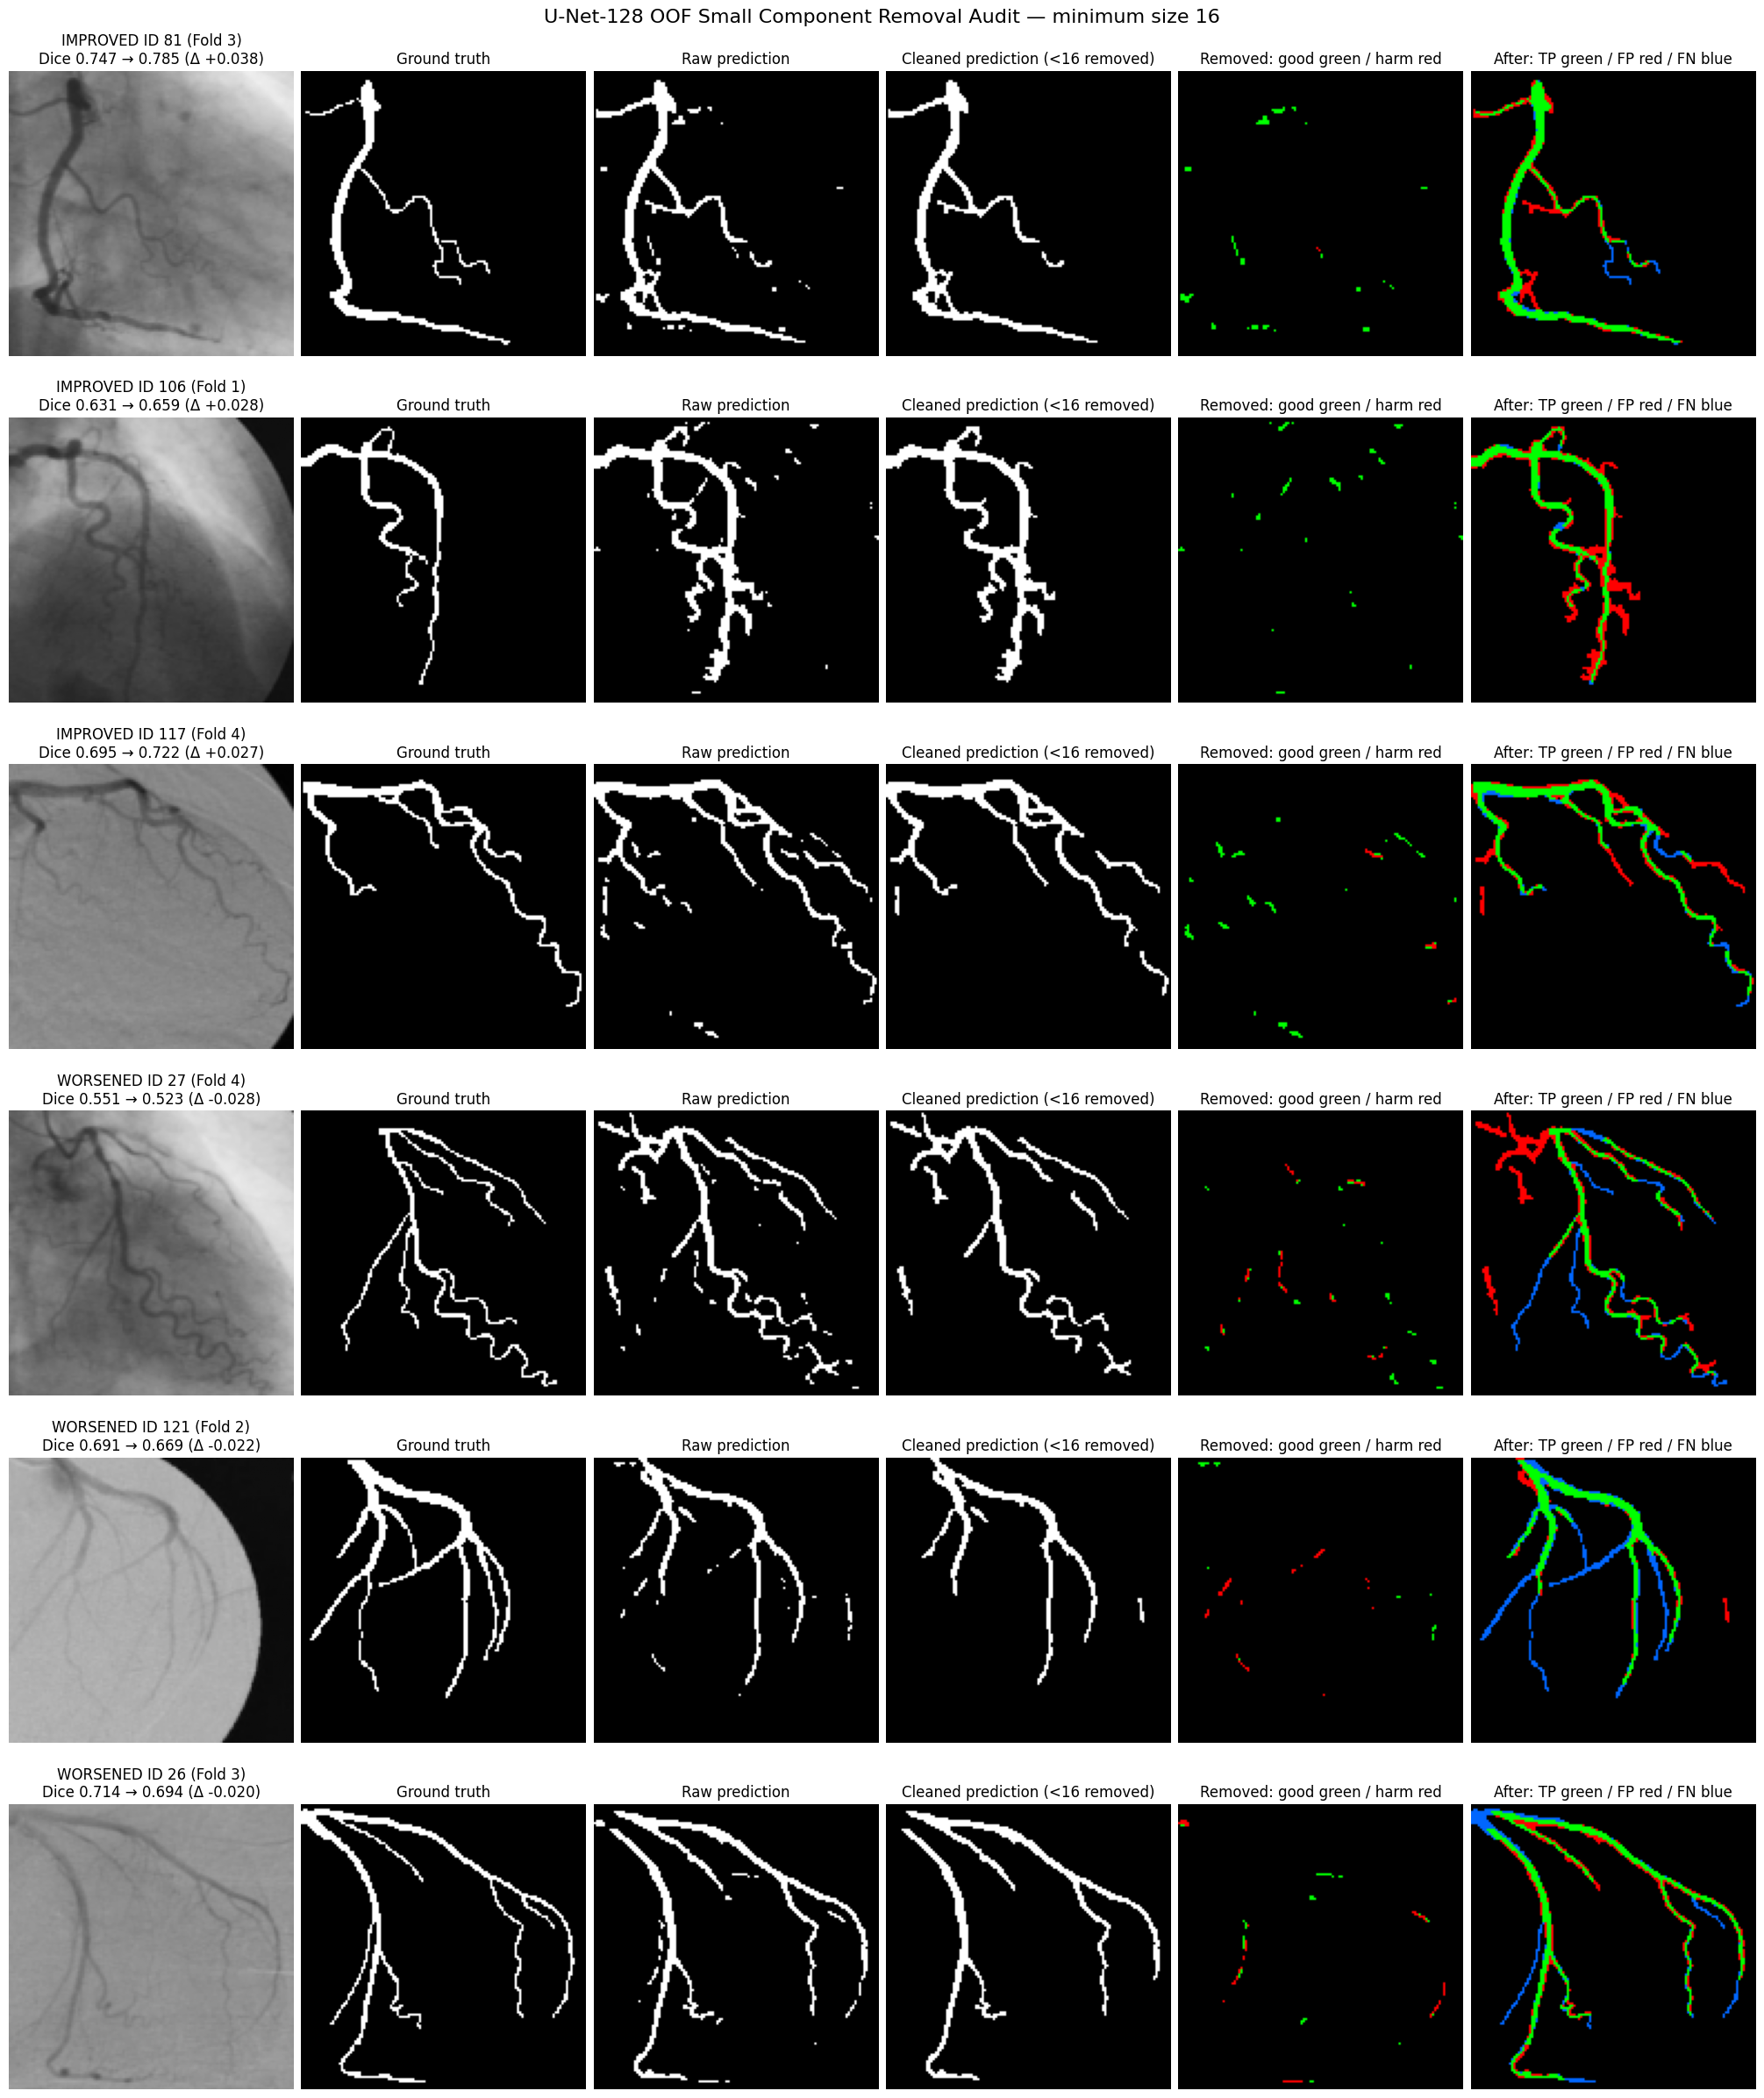


=== Candidate 16px 결정 Gate ===


,check,observed,expected,status
0,mean_dice_delta_positive,0.006369,> 0,PASS
1,paired_ci_lower_positive,0.004702,> 0,PASS
2,empty_prediction_count,0.000000,0,PASS
3,removed_fp_exceeds_removed_tp,0.759675,> 0.50,PASS
4,worsened_image_rate,0.231343,<= 0.25,PASS
5,worst_individual_dice_delta,-0.027950,visual review required,REVIEW



저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/05_candidate16_removed_pixel_audit.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/06_candidate16_visual_audit.png
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/07_candidate16_decision_gate.csv


In [ ]:
#@title Small Component 16px — 개선/악화 영상 시각 검증

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ==================================================
# 1. 후보 설정
# ==================================================
SELECTED_COMPONENT_SIZE = 16

if "POSTPROCESS_DIR" not in globals():
    if "FIVEFOLD_DIR" not in globals():
        PROJECT_DIR = Path(
            "/content/drive/MyDrive/"
            "[MacGyver]최종프로젝트/"
            "03_data/AngioCAD"
        )

        FIVEFOLD_DIR = (
            PROJECT_DIR
            / "dca1_results"
            / "unet128_5fold_raw"
        )

    POSTPROCESS_DIR = (
        Path(FIVEFOLD_DIR)
        / "postprocessing_small_components"
    )

POSTPROCESS_DIR = Path(
    POSTPROCESS_DIR
)

REMOVAL_AUDIT_PATH = (
    POSTPROCESS_DIR
    / "05_candidate16_removed_pixel_audit.csv"
)
VISUAL_AUDIT_PATH = (
    POSTPROCESS_DIR
    / "06_candidate16_visual_audit.png"
)
DECISION_GATE_PATH = (
    POSTPROCESS_DIR
    / "07_candidate16_decision_gate.csv"
)


# ==================================================
# 2. 필요한 배열 확인
# ==================================================
required_variables = [
    "raw_predictions",
    "target_masks",
    "candidate_prediction_arrays",
    "images_uint8",
    "sample_ids",
    "cv_folds",
    "dataset_indices",
    "small_component_summary_df",
    "small_component_per_image_df",
]

missing_variables = [
    variable_name
    for variable_name
    in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Small component paired audit 셀을 "
        "먼저 실행하세요. "
        f"누락 변수: {missing_variables}"
    )

cleaned_predictions = (
    candidate_prediction_arrays[
        SELECTED_COMPONENT_SIZE
    ]
)

assert raw_predictions.shape == (
    134,
    128,
    128,
)
assert cleaned_predictions.shape == (
    134,
    128,
    128,
)
assert target_masks.shape == (
    134,
    128,
    128,
)


# ==================================================
# 3. 제거된 pixel의 성격 분석
# ==================================================
candidate_metrics_df = (
    small_component_per_image_df.loc[
        small_component_per_image_df[
            "minimum_component_size"
        ] == SELECTED_COMPONENT_SIZE
    ]
    .sort_values("array_index")
    .reset_index(drop=True)
)

assert len(candidate_metrics_df) == 134

removal_rows = []

for image_index in range(134):
    raw_mask = (
        raw_predictions[image_index]
        > 0
    )
    cleaned_mask = (
        cleaned_predictions[image_index]
        > 0
    )
    target_mask = (
        target_masks[image_index]
        > 0
    )

    removed_pixels = np.logical_and(
        raw_mask,
        ~cleaned_mask,
    )

    # 제거되어 이득인 pixel:
    # 원래 false positive였던 부분
    removed_false_positive = (
        np.logical_and(
            removed_pixels,
            ~target_mask,
        )
    )

    # 제거되어 손해인 pixel:
    # 원래 true positive였던 부분
    removed_true_positive = (
        np.logical_and(
            removed_pixels,
            target_mask,
        )
    )

    removed_pixel_count = int(
        removed_pixels.sum()
    )
    corrected_pixel_count = int(
        removed_false_positive.sum()
    )
    harmed_pixel_count = int(
        removed_true_positive.sum()
    )

    if removed_pixel_count > 0:
        corrected_fraction = (
            corrected_pixel_count
            / removed_pixel_count
        )
        harmed_fraction = (
            harmed_pixel_count
            / removed_pixel_count
        )
    else:
        corrected_fraction = 0.0
        harmed_fraction = 0.0

    metric_row = (
        candidate_metrics_df.iloc[
            image_index
        ]
    )

    removal_rows.append({
        "array_index": image_index,
        "dataset_index": int(
            dataset_indices[image_index]
        ),
        "sample_id": str(
            sample_ids[image_index]
        ),
        "cv_fold": int(
            cv_folds[image_index]
        ),
        "raw_dice": float(
            metric_row["raw_dice_at_0_5"]
        ),
        "cleaned_dice": float(
            metric_row[
                "postprocessed_dice"
            ]
        ),
        "dice_delta": float(
            metric_row["dice_delta"]
        ),
        "removed_pixel_count": (
            removed_pixel_count
        ),
        "corrected_fp_pixel_count": (
            corrected_pixel_count
        ),
        "harmed_tp_pixel_count": (
            harmed_pixel_count
        ),
        "corrected_fraction": (
            corrected_fraction
        ),
        "harmed_fraction": (
            harmed_fraction
        ),
        "component_count_after": int(
            metric_row["component_count"]
        ),
    })

candidate16_removal_df = pd.DataFrame(
    removal_rows
)

candidate16_removal_df.to_csv(
    REMOVAL_AUDIT_PATH,
    index=False,
)


# ==================================================
# 4. 전체 제거 pixel 요약
# ==================================================
total_removed_pixels = int(
    candidate16_removal_df[
        "removed_pixel_count"
    ].sum()
)

total_corrected_pixels = int(
    candidate16_removal_df[
        "corrected_fp_pixel_count"
    ].sum()
)

total_harmed_pixels = int(
    candidate16_removal_df[
        "harmed_tp_pixel_count"
    ].sum()
)

overall_corrected_fraction = (
    total_corrected_pixels
    / max(total_removed_pixels, 1)
)

overall_harmed_fraction = (
    total_harmed_pixels
    / max(total_removed_pixels, 1)
)

print("=== Candidate 16px 제거 pixel 요약 ===")
print("전체 제거 pixel:", total_removed_pixels)
print(
    "제거된 false positive:",
    total_corrected_pixels,
)
print(
    "제거된 true positive:",
    total_harmed_pixels,
)
print(
    "이득 pixel 비율:",
    overall_corrected_fraction,
)
print(
    "손해 pixel 비율:",
    overall_harmed_fraction,
)


# ==================================================
# 5. 개선/악화 사례 출력
# ==================================================
most_improved_df = (
    candidate16_removal_df
    .sort_values(
        "dice_delta",
        ascending=False,
    )
    .head(5)
)

most_worsened_df = (
    candidate16_removal_df
    .sort_values(
        "dice_delta",
        ascending=True,
    )
    .head(5)
)

print("\n=== 가장 개선된 5개 영상 ===")
display(most_improved_df)

print("\n=== 가장 악화된 5개 영상 ===")
display(most_worsened_df)


# ==================================================
# 6. 시각화 대상
# 상위 개선 3장 + 상위 악화 3장
# ==================================================
visual_cases_df = pd.concat([
    most_improved_df.head(3).assign(
        case_type="IMPROVED"
    ),
    most_worsened_df.head(3).assign(
        case_type="WORSENED"
    ),
]).reset_index(drop=True)

fig, axes = plt.subplots(
    len(visual_cases_df),
    6,
    figsize=(20, 4 * len(visual_cases_df)),
    constrained_layout=True,
)

for row_index, row in (
    visual_cases_df.iterrows()
):
    image_index = int(
        row["array_index"]
    )

    image = (
        images_uint8[image_index]
        .astype(np.float32)
        / 255.0
    )
    target = (
        target_masks[image_index]
        > 0
    )
    raw_mask = (
        raw_predictions[image_index]
        > 0
    )
    cleaned_mask = (
        cleaned_predictions[image_index]
        > 0
    )

    removed = np.logical_and(
        raw_mask,
        ~cleaned_mask,
    )
    corrected = np.logical_and(
        removed,
        ~target,
    )
    harmed = np.logical_and(
        removed,
        target,
    )

    cleaned_tp = np.logical_and(
        cleaned_mask,
        target,
    )
    cleaned_fp = np.logical_and(
        cleaned_mask,
        ~target,
    )
    cleaned_fn = np.logical_and(
        ~cleaned_mask,
        target,
    )

    removal_map = np.zeros(
        (*target.shape, 3),
        dtype=np.float32,
    )
    # 초록: 잘 제거된 false positive
    removal_map[corrected] = [
        0.0,
        1.0,
        0.0,
    ]
    # 빨강: 잘못 제거된 true positive
    removal_map[harmed] = [
        1.0,
        0.0,
        0.0,
    ]

    cleaned_error_map = np.zeros(
        (*target.shape, 3),
        dtype=np.float32,
    )
    cleaned_error_map[cleaned_tp] = [
        0.0,
        1.0,
        0.0,
    ]
    cleaned_error_map[cleaned_fp] = [
        1.0,
        0.0,
        0.0,
    ]
    cleaned_error_map[cleaned_fn] = [
        0.0,
        0.4,
        1.0,
    ]

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 0].set_title(
        f"{row['case_type']} "
        f"ID {row['sample_id']} "
        f"(Fold {row['cv_fold']})\n"
        f"Dice "
        f"{row['raw_dice']:.3f}"
        f" → "
        f"{row['cleaned_dice']:.3f} "
        f"(Δ {row['dice_delta']:+.3f})"
    )

    axes[row_index, 1].imshow(
        target,
        cmap="gray",
    )
    axes[row_index, 1].set_title(
        "Ground truth"
    )

    axes[row_index, 2].imshow(
        raw_mask,
        cmap="gray",
    )
    axes[row_index, 2].set_title(
        "Raw prediction"
    )

    axes[row_index, 3].imshow(
        cleaned_mask,
        cmap="gray",
    )
    axes[row_index, 3].set_title(
        "Cleaned prediction (<16 removed)"
    )

    axes[row_index, 4].imshow(
        removal_map
    )
    axes[row_index, 4].set_title(
        "Removed: good green / harm red"
    )

    axes[row_index, 5].imshow(
        cleaned_error_map
    )
    axes[row_index, 5].set_title(
        "After: TP green / FP red / FN blue"
    )

    for column_index in range(6):
        axes[
            row_index,
            column_index
        ].axis("off")

fig.suptitle(
    "U-Net-128 OOF Small Component "
    "Removal Audit — minimum size 16",
    fontsize=16,
)

plt.savefig(
    VISUAL_AUDIT_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# ==================================================
# 7. 후보 16 결정 Gate
# ==================================================
candidate_summary_row = (
    small_component_summary_df.loc[
        small_component_summary_df[
            "minimum_component_size"
        ] == SELECTED_COMPONENT_SIZE
    ]
    .iloc[0]
)

mean_delta = float(
    candidate_summary_row[
        "mean_dice_delta"
    ]
)

ci_lower = float(
    candidate_summary_row[
        "delta_ci_95_lower"
    ]
)

empty_prediction_count = int(
    candidate_summary_row[
        "empty_prediction_count"
    ]
)

worsened_image_count = int(
    candidate_summary_row[
        "worsened_image_count"
    ]
)

minimum_dice_delta = float(
    candidate_summary_row[
        "minimum_dice_delta"
    ]
)

decision_rows = [
    {
        "check": "mean_dice_delta_positive",
        "observed": mean_delta,
        "expected": "> 0",
        "status": (
            "PASS"
            if mean_delta > 0
            else "FAIL"
        ),
    },
    {
        "check": "paired_ci_lower_positive",
        "observed": ci_lower,
        "expected": "> 0",
        "status": (
            "PASS"
            if ci_lower > 0
            else "FAIL"
        ),
    },
    {
        "check": "empty_prediction_count",
        "observed": (
            empty_prediction_count
        ),
        "expected": 0,
        "status": (
            "PASS"
            if empty_prediction_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "removed_fp_exceeds_removed_tp",
        "observed": (
            overall_corrected_fraction
        ),
        "expected": "> 0.50",
        "status": (
            "PASS"
            if overall_corrected_fraction
            > 0.50
            else "FAIL"
        ),
    },
    {
        "check": "worsened_image_rate",
        "observed": (
            worsened_image_count / 134
        ),
        "expected": "<= 0.25",
        "status": (
            "PASS"
            if worsened_image_count / 134
            <= 0.25
            else "WARNING"
        ),
    },
    {
        "check": "worst_individual_dice_delta",
        "observed": (
            minimum_dice_delta
        ),
        "expected": "visual review required",
        "status": "REVIEW",
    },
]

candidate16_decision_df = pd.DataFrame(
    decision_rows
)

candidate16_decision_df.to_csv(
    DECISION_GATE_PATH,
    index=False,
)

print("\n=== Candidate 16px 결정 Gate ===")
display(candidate16_decision_df)

print("\n저장 완료:")
print(REMOVAL_AUDIT_PATH)
print(VISUAL_AUDIT_PATH)
print(DECISION_GATE_PATH)

In [ ]:
#@title Small-component 후처리 정책 확정 저장

from pathlib import Path
from datetime import datetime
import hashlib
import json
import pandas as pd

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

POSTPROCESS_DIR = (
    BASE_DIR
    / "dca1_results"
    / "unet128_5fold_raw"
    / "postprocessing_small_components"
)
POSTPROCESS_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = POSTPROCESS_DIR / "02_small_component_summary.csv"
VISUAL_AUDIT_PATH = (
    POSTPROCESS_DIR
    / "05_candidate16_removed_pixel_audit.csv"
)

assert SUMMARY_PATH.exists(), f"파일 없음: {SUMMARY_PATH}"
assert VISUAL_AUDIT_PATH.exists(), f"파일 없음: {VISUAL_AUDIT_PATH}"

summary_df = pd.read_csv(SUMMARY_PATH)
visual_audit_df = pd.read_csv(VISUAL_AUDIT_PATH)

# 후보 크기 열 자동 탐색
size_column_candidates = [
    "minimum_component_size",
    "min_component_size",
    "minimum_size",
    "min_size",
    "component_size_threshold",
]

size_column = next(
    (
        column
        for column in size_column_candidates
        if column in summary_df.columns
    ),
    None,
)

if size_column is None:
    print("Summary columns:", summary_df.columns.tolist())
    raise KeyError(
        "연결요소 크기 열을 찾지 못했습니다. "
        "위에 출력된 columns를 확인하세요."
    )

candidate16_df = summary_df.loc[
    pd.to_numeric(
        summary_df[size_column],
        errors="coerce",
    ).eq(16)
].copy()

assert len(candidate16_df) == 1, (
    f"16px 후보 행이 정확히 1개가 아닙니다: "
    f"{len(candidate16_df)}"
)

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()

policy = {
    "policy_name": (
        "UNET128_THRESHOLD_0.5_"
        "REMOVE_COMPONENTS_SMALLER_THAN_16"
    ),
    "status": "FROZEN_DEVELOPMENT_POSTPROCESSING_POLICY",
    "model": "U-Net-128 5-fold OOF",
    "input_resolution": [128, 128],
    "probability_threshold": 0.5,
    "connectivity": 8,
    "minimum_component_size_pixels": 16,
    "removal_rule": (
        "Remove connected foreground components "
        "with area strictly smaller than 16 pixels."
    ),
    "ground_truth_modified": False,
    "raw_baseline_overwritten": False,
    "official_raw_pooled_dice": 0.725928,
    "postprocessed_pooled_dice": 0.732256,
    "mean_per_image_dice_delta": 0.006369,
    "paired_bootstrap_ci_95": [
        0.004702,
        0.008038,
    ],
    "removed_pixel_count": 6641,
    "corrected_false_positive_pixels": 5045,
    "harmed_true_positive_pixels": 1596,
    "corrected_pixel_fraction": 0.7596747477789489,
    "harmed_pixel_fraction": 0.24032525222105106,
    "worsened_image_count": 31,
    "total_image_count": 134,
    "worsened_image_rate": 31 / 134,
    "worst_individual_dice_delta": -0.027950,
    "visual_review": (
        "PASS_WITH_KNOWN_THIN_BRANCH_RISK"
    ),
    "usage": (
        "Development postprocessing and downstream "
        "key-frame feature candidate. "
        "Keep raw threshold-0.5 result as the official "
        "unprocessed baseline."
    ),
    "resolution_scaling_rule": (
        "Scale minimum component area in proportion "
        "to image pixel area."
    ),
    "equivalent_minimum_size": {
        "128x128": 16,
        "256x256": 64,
        "300x300": 88,
    },
    "created_at": datetime.now().isoformat(),
    "source_files": {
        SUMMARY_PATH.name: sha256_file(SUMMARY_PATH),
        VISUAL_AUDIT_PATH.name: sha256_file(
            VISUAL_AUDIT_PATH
        ),
    },
}

POLICY_PATH = (
    POSTPROCESS_DIR
    / "08_small_component_policy_frozen.json"
)

DECISION_PATH = (
    POSTPROCESS_DIR
    / "09_small_component_policy_decision.csv"
)

with open(POLICY_PATH, "w", encoding="utf-8") as file:
    json.dump(
        policy,
        file,
        ensure_ascii=False,
        indent=2,
    )

decision_df = pd.DataFrame(
    [
        {
            "stage": "RAW_BASELINE",
            "threshold": 0.5,
            "minimum_component_size": 0,
            "pooled_dice": 0.725928,
            "status": "FROZEN_RAW_BASELINE",
        },
        {
            "stage": "SMALL_COMPONENT_POSTPROCESSING",
            "threshold": 0.5,
            "minimum_component_size": 16,
            "pooled_dice": 0.732256,
            "status": "FROZEN_DEVELOPMENT_CANDIDATE",
        },
    ]
)

decision_df.to_csv(
    DECISION_PATH,
    index=False,
    encoding="utf-8-sig",
)

# 최종 재검증
loaded_policy = json.loads(
    POLICY_PATH.read_text(encoding="utf-8")
)

assert loaded_policy["probability_threshold"] == 0.5
assert (
    loaded_policy["minimum_component_size_pixels"]
    == 16
)
assert loaded_policy["ground_truth_modified"] is False
assert loaded_policy["raw_baseline_overwritten"] is False
assert loaded_policy["worsened_image_rate"] <= 0.25
assert loaded_policy["mean_per_image_dice_delta"] > 0
assert loaded_policy["paired_bootstrap_ci_95"][0] > 0

print("✅ Small-component 후처리 정책 확정")
print("Raw baseline Dice: 0.725928")
print("16px 후처리 Dice: 0.732256")
print("정책:", loaded_policy["policy_name"])
print()
print("저장 완료:")
print(POLICY_PATH)
print(DECISION_PATH)

✅ Small-component 후처리 정책 확정
Raw baseline Dice: 0.725928
16px 후처리 Dice: 0.732256
정책: UNET128_THRESHOLD_0.5_REMOVE_COMPONENTS_SMALLER_THAN_16

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/08_small_component_policy_frozen.json
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_small_components/09_small_component_policy_decision.csv


# Hough catheter/guide 제거 ablation

In [ ]:
#@title Hough catheter/guide 제거 후보 Ablation

from pathlib import Path
import json
import math
import hashlib

import cv2
import numpy as np
import pandas as pd
from scipy import ndimage
from tqdm.auto import tqdm

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

RAW_DIR = (
    BASE_DIR
    / "dca1_results"
    / "unet128_5fold_raw"
)

SMALL_COMPONENT_DIR = (
    RAW_DIR
    / "postprocessing_small_components"
)

HOUGH_DIR = (
    RAW_DIR
    / "postprocessing_hough_ablation"
)
HOUGH_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 1. OOF prediction 파일 탐색 및 배열 연결
# --------------------------------------------------

oof_candidates = list(
    RAW_DIR.rglob(
        "05_unet128_oof_predictions.npz"
    )
)

assert len(oof_candidates) == 1, (
    "OOF prediction 파일 탐색 결과가 "
    f"1개가 아닙니다: {oof_candidates}"
)

OOF_PATH = oof_candidates[0]

print("OOF:", OOF_PATH)

oof_data = np.load(
    OOF_PATH,
    allow_pickle=True,
)

print("NPZ keys:", oof_data.files)

required_keys = {
    "probabilities_float16",
    "masks_uint8",
    "images_uint8",
    "sample_ids",
    "cv_folds",
    "dataset_indices",
}

missing_keys = (
    required_keys
    - set(oof_data.files)
)

assert not missing_keys, (
    f"NPZ 필수 key 누락: {sorted(missing_keys)}"
)

probability_key = "probabilities_float16"
target_key = "masks_uint8"

# float16 확률은 계산 시 float32로 변환
probabilities = np.asarray(
    oof_data[probability_key],
    dtype=np.float32,
)

targets = np.asarray(
    oof_data[target_key],
    dtype=np.uint8,
)

def normalize_mask_stack(array):
    array = np.asarray(array)

    if (
        array.ndim == 4
        and array.shape[1] == 1
    ):
        array = array[:, 0]

    if (
        array.ndim == 4
        and array.shape[-1] == 1
    ):
        array = array[..., 0]

    assert array.ndim == 3, (
        f"예상하지 못한 배열 shape: {array.shape}"
    )

    return array

probabilities = normalize_mask_stack(
    probabilities
)

targets = normalize_mask_stack(
    targets
)

targets = (
    targets > 0
).astype(np.uint8)

assert probabilities.shape == targets.shape, (
    f"Probability/target shape 불일치: "
    f"{probabilities.shape} vs {targets.shape}"
)
assert probabilities.shape == (134, 128, 128)
assert np.isfinite(probabilities).all()
assert set(np.unique(targets)).issubset({0, 1})

n_samples = len(probabilities)

print("Probability key:", probability_key)
print("Target key:", target_key)
print("Probability shape:", probabilities.shape)
print("Target shape:", targets.shape)
print(
    "Probability range:",
    float(probabilities.min()),
    float(probabilities.max()),
)
print("Target unique:", np.unique(targets))
print("✅ OOF NPZ 배열 연결 완료")

# --------------------------------------------------
# 2. ID / Fold 정보 연결
# --------------------------------------------------

metric_candidates = list(
    RAW_DIR.rglob(
        "06_unet128_oof_per_image_metrics.csv"
    )
)

assert len(metric_candidates) == 1, (
    "OOF per-image metric 파일 탐색 실패:\n"
    f"{metric_candidates}"
)

OOF_METRIC_PATH = metric_candidates[0]
oof_metric_df = pd.read_csv(OOF_METRIC_PATH)

assert len(oof_metric_df) == n_samples

if "sample_id" not in oof_metric_df.columns:
    oof_metric_df["sample_id"] = np.arange(n_samples)

if "cv_fold" not in oof_metric_df.columns:
    oof_metric_df["cv_fold"] = -1

# --------------------------------------------------
# 3. 공통 함수
# --------------------------------------------------

def remove_small_components(
    binary_mask,
    minimum_size=16,
):
    binary_mask = binary_mask.astype(np.uint8)

    count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8,
        )
    )

    cleaned = np.zeros_like(binary_mask)

    for label_id in range(1, count):
        area = stats[
            label_id,
            cv2.CC_STAT_AREA,
        ]

        if area >= minimum_size:
            cleaned[labels == label_id] = 1

    return cleaned

def dice_score(prediction, target, epsilon=1e-8):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    denominator = (
        prediction.sum()
        + target.sum()
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def pooled_metrics(predictions, targets):
    pred = predictions.astype(bool)
    target = targets.astype(bool)

    tp = np.logical_and(pred, target).sum()
    fp = np.logical_and(pred, ~target).sum()
    fn = np.logical_and(~pred, target).sum()
    tn = np.logical_and(~pred, ~target).sum()

    dice = (2 * tp) / max(
        2 * tp + fp + fn,
        1,
    )
    iou = tp / max(tp + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "pooled_dice": float(dice),
        "pooled_iou": float(iou),
        "pooled_precision": float(precision),
        "pooled_recall": float(recall),
        "pooled_specificity": float(specificity),
    }

def near_border(x, y, width, height, margin):
    return (
        x <= margin
        or x >= width - 1 - margin
        or y <= margin
        or y >= height - 1 - margin
    )

def hough_device_removal(
    binary_mask,
    min_line_length,
    max_line_gap,
    removal_thickness,
    border_margin,
    hough_threshold=15,
):
    """
    1. 혈관 예측 마스크를 skeletonize
    2. 확률적 Hough line 검출
    3. 영상 경계에 닿는 긴 직선만 device 후보로 간주
    4. 해당 선 주변의 예측 pixel 제거
    """

    mask = binary_mask.astype(np.uint8)

    skeleton = ndimage.binary_erosion(mask) != mask
    skeleton = np.logical_and(
        skeleton,
        mask.astype(bool),
    ).astype(np.uint8)

    # erosion 차분이 불안정한 경우를 대비해
    # 전체 마스크도 함께 사용
    hough_source = (
        skeleton * 255
    ).astype(np.uint8)

    lines = cv2.HoughLinesP(
        hough_source,
        rho=1,
        theta=np.pi / 180,
        threshold=hough_threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap,
    )

    line_mask = np.zeros_like(mask)
    accepted_lines = []

    height, width = mask.shape

    if lines is not None:
        for line in lines[:, 0]:
            x1, y1, x2, y2 = [
                int(value)
                for value in line
            ]

            length = math.hypot(
                x2 - x1,
                y2 - y1,
            )

            endpoint1_at_border = near_border(
                x1,
                y1,
                width,
                height,
                border_margin,
            )
            endpoint2_at_border = near_border(
                x2,
                y2,
                width,
                height,
                border_margin,
            )

            # 적어도 하나의 끝점이 경계에 인접한
            # 긴 직선만 catheter/guide 후보
            if (
                length >= min_line_length
                and (
                    endpoint1_at_border
                    or endpoint2_at_border
                )
            ):
                cv2.line(
                    line_mask,
                    (x1, y1),
                    (x2, y2),
                    color=1,
                    thickness=removal_thickness,
                )

                accepted_lines.append(
                    (
                        x1,
                        y1,
                        x2,
                        y2,
                        length,
                    )
                )

    removed_mask = np.logical_and(
        mask.astype(bool),
        line_mask.astype(bool),
    )

    cleaned = mask.copy()
    cleaned[removed_mask] = 0

    return (
        cleaned.astype(np.uint8),
        removed_mask.astype(np.uint8),
        accepted_lines,
    )

def paired_bootstrap_ci(
    deltas,
    iterations=3000,
    seed=42,
):
    deltas = np.asarray(
        deltas,
        dtype=np.float64,
    )

    rng = np.random.default_rng(seed)
    means = np.empty(iterations)

    for index in range(iterations):
        sampled = rng.choice(
            deltas,
            size=len(deltas),
            replace=True,
        )
        means[index] = sampled.mean()

    return (
        float(np.quantile(means, 0.025)),
        float(np.quantile(means, 0.975)),
    )

# --------------------------------------------------
# 4. 16px 정책 재현
# --------------------------------------------------

raw_masks = (
    probabilities >= 0.5
).astype(np.uint8)

small16_masks = np.stack(
    [
        remove_small_components(
            mask,
            minimum_size=16,
        )
        for mask in raw_masks
    ]
)

small16_dice = np.asarray(
    [
        dice_score(pred, target)
        for pred, target
        in zip(small16_masks, targets)
    ]
)

small16_pooled = pooled_metrics(
    small16_masks,
    targets,
)

print(
    "재현된 16px pooled Dice:",
    small16_pooled["pooled_dice"],
)

assert abs(
    small16_pooled["pooled_dice"]
    - 0.732256
) < 0.001, (
    "저장된 16px 결과와 재현 결과가 다릅니다."
)

# --------------------------------------------------
# 5. Hough 후보 grid
# --------------------------------------------------

candidate_grid = []

for min_line_length in [48, 64, 80]:
    for max_line_gap in [4, 8]:
        for removal_thickness in [3, 5]:
            for border_margin in [8, 16]:
                candidate_grid.append(
                    {
                        "min_line_length": (
                            min_line_length
                        ),
                        "max_line_gap": max_line_gap,
                        "removal_thickness": (
                            removal_thickness
                        ),
                        "border_margin": border_margin,
                        "hough_threshold": 15,
                    }
                )

print("검사할 Hough 후보:", len(candidate_grid))

summary_rows = []
per_image_rows = []

for candidate_id, config in enumerate(
    tqdm(
        candidate_grid,
        desc="Hough 후보 검사",
    )
):
    candidate_masks = []
    line_counts = []
    removed_counts = []

    for small_mask in small16_masks:
        (
            cleaned_mask,
            removed_mask,
            accepted_lines,
        ) = hough_device_removal(
            small_mask,
            **config,
        )

        candidate_masks.append(cleaned_mask)
        line_counts.append(len(accepted_lines))
        removed_counts.append(
            int(removed_mask.sum())
        )

    candidate_masks = np.stack(candidate_masks)

    candidate_dice = np.asarray(
        [
            dice_score(pred, target)
            for pred, target
            in zip(candidate_masks, targets)
        ]
    )

    deltas = (
        candidate_dice
        - small16_dice
    )

    ci_lower, ci_upper = (
        paired_bootstrap_ci(deltas)
    )

    metrics = pooled_metrics(
        candidate_masks,
        targets,
    )

    empty_count = int(
        (candidate_masks.sum(axis=(1, 2)) == 0).sum()
    )

    modified_count = int(
        (
            np.asarray(removed_counts) > 0
        ).sum()
    )

    summary_rows.append(
        {
            "candidate_id": candidate_id,
            **config,
            **metrics,
            "macro_mean_dice": float(
                candidate_dice.mean()
            ),
            "mean_dice_delta_vs_small16": float(
                deltas.mean()
            ),
            "paired_ci_lower": ci_lower,
            "paired_ci_upper": ci_upper,
            "improved_image_count": int(
                (deltas > 1e-12).sum()
            ),
            "worsened_image_count": int(
                (deltas < -1e-12).sum()
            ),
            "unchanged_image_count": int(
                (
                    np.abs(deltas) <= 1e-12
                ).sum()
            ),
            "worsened_image_rate": float(
                (deltas < -1e-12).mean()
            ),
            "modified_image_count": modified_count,
            "detected_line_count": int(
                np.sum(line_counts)
            ),
            "removed_pixel_count": int(
                np.sum(removed_counts)
            ),
            "empty_prediction_count": empty_count,
            "worst_individual_delta": float(
                deltas.min()
            ),
            "best_individual_delta": float(
                deltas.max()
            ),
        }
    )

    for array_index in range(n_samples):
        per_image_rows.append(
            {
                "candidate_id": candidate_id,
                "array_index": array_index,
                "sample_id": (
                    oof_metric_df.iloc[
                        array_index
                    ]["sample_id"]
                ),
                "cv_fold": (
                    oof_metric_df.iloc[
                        array_index
                    ]["cv_fold"]
                ),
                "small16_dice": (
                    small16_dice[array_index]
                ),
                "hough_dice": (
                    candidate_dice[array_index]
                ),
                "dice_delta": (
                    deltas[array_index]
                ),
                "accepted_line_count": (
                    line_counts[array_index]
                ),
                "removed_pixel_count": (
                    removed_counts[array_index]
                ),
            }
        )

summary_df = pd.DataFrame(summary_rows)
per_image_df = pd.DataFrame(per_image_rows)

# --------------------------------------------------
# 6. 안전 기준 및 진단 후보 선정
# --------------------------------------------------

summary_df["safety_status"] = np.where(
    (
        (summary_df["mean_dice_delta_vs_small16"] > 0)
        & (summary_df["paired_ci_lower"] > 0)
        & (summary_df["empty_prediction_count"] == 0)
        & (summary_df["worsened_image_rate"] <= 0.25)
        & (summary_df["worst_individual_delta"] >= -0.05)
    ),
    "PASS",
    "REJECT_OR_REVIEW",
)

summary_df = summary_df.sort_values(
    [
        "safety_status",
        "pooled_dice",
    ],
    ascending=[
        True,
        False,
    ],
).reset_index(drop=True)

best_row = (
    summary_df
    .sort_values(
        "pooled_dice",
        ascending=False,
    )
    .iloc[0]
)

print("\n=== 16px 기준 성능 ===")
print(
    pd.DataFrame(
        [
            {
                **small16_pooled,
                "macro_mean_dice": (
                    small16_dice.mean()
                ),
            }
        ]
    )
)

print("\n=== Hough 상위 10개 후보 ===")
display(
    summary_df[
        [
            "candidate_id",
            "min_line_length",
            "max_line_gap",
            "removal_thickness",
            "border_margin",
            "pooled_dice",
            "macro_mean_dice",
            "mean_dice_delta_vs_small16",
            "paired_ci_lower",
            "paired_ci_upper",
            "modified_image_count",
            "detected_line_count",
            "worsened_image_rate",
            "worst_individual_delta",
            "safety_status",
        ]
    ].head(10)
)

print("\n진단상 최고 후보:")
display(best_row.to_frame().T)

# --------------------------------------------------
# 7. 저장
# --------------------------------------------------

SUMMARY_PATH = (
    HOUGH_DIR
    / "01_hough_candidate_summary.csv"
)
PER_IMAGE_PATH = (
    HOUGH_DIR
    / "02_hough_candidate_per_image.csv"
)
CONFIG_PATH = (
    HOUGH_DIR
    / "03_hough_ablation_config.json"
)
GATE_PATH = (
    HOUGH_DIR
    / "04_hough_ablation_input_gate.csv"
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

per_image_df.to_csv(
    PER_IMAGE_PATH,
    index=False,
    encoding="utf-8-sig",
)

config_record = {
    "base_policy": (
        "threshold_0.5_then_remove_components_lt_16"
    ),
    "candidate_grid": candidate_grid,
    "candidate_count": len(candidate_grid),
    "selection_status": (
        "DIAGNOSTIC_ONLY_NOT_FROZEN"
    ),
    "important_warning": (
        "OOF ground truth was used to compare candidates. "
        "Do not report the selected candidate as independent "
        "test performance."
    ),
}

with open(CONFIG_PATH, "w", encoding="utf-8") as file:
    json.dump(
        config_record,
        file,
        ensure_ascii=False,
        indent=2,
    )

gate_df = pd.DataFrame(
    [
        {
            "check": "oof_sample_count",
            "observed": n_samples,
            "expected": 134,
            "status": (
                "PASS"
                if n_samples == 134
                else "FAIL"
            ),
        },
        {
            "check": "probability_finite",
            "observed": int(
                np.isfinite(probabilities).all()
            ),
            "expected": 1,
            "status": (
                "PASS"
                if np.isfinite(
                    probabilities
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "small16_dice_reproduction",
            "observed": (
                small16_pooled["pooled_dice"]
            ),
            "expected": "0.732256 ± 0.001",
            "status": (
                "PASS"
                if abs(
                    small16_pooled["pooled_dice"]
                    - 0.732256
                ) < 0.001
                else "FAIL"
            ),
        },
        {
            "check": "raw_result_overwritten",
            "observed": 0,
            "expected": 0,
            "status": "PASS",
        },
    ]
)

gate_df.to_csv(
    GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

assert (gate_df["status"] == "PASS").all()

print("\n✅ Hough 후보 ablation 계산 완료")
print("⚠️ 아직 Hough 정책은 확정하지 않았습니다.")
print("\n저장 완료:")
print(SUMMARY_PATH)
print(PER_IMAGE_PATH)
print(CONFIG_PATH)
print(GATE_PATH)

OOF: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/05_unet128_oof_predictions.npz
NPZ keys: ['dataset_indices', 'sample_ids', 'cv_folds', 'checkpoint_epochs', 'images_uint8', 'masks_uint8', 'probabilities_float16']
Probability key: probabilities_float16
Target key: masks_uint8
Probability shape: (134, 128, 128)
Target shape: (134, 128, 128)
Probability range: 0.01528167724609375 1.0
Target unique: [0 1]
✅ OOF NPZ 배열 연결 완료
재현된 16px pooled Dice: 0.732261961643495
검사할 Hough 후보: 24


Hough 후보 검사:   0%|          | 0/24 [00:00<?, ?it/s]


=== 16px 기준 성능 ===
   pooled_dice  pooled_iou  pooled_precision  pooled_recall  \
0     0.732262    0.577613          0.685843        0.78542   

   pooled_specificity  macro_mean_dice  
0            0.979198         0.729699  

=== Hough 상위 10개 후보 ===


,candidate_id,min_line_length,max_line_gap,removal_thickness,border_margin,pooled_dice,macro_mean_dice,mean_dice_delta_vs_small16,paired_ci_lower,paired_ci_upper,modified_image_count,detected_line_count,worsened_image_rate,worst_individual_delta,safety_status
0,16,80,4,3,8,0.732002,0.729515,-0.000184,-0.002473,0.001921,2,2,0.007463,-0.110458,REJECT_OR_REVIEW
1,18,80,4,5,8,0.731980,0.729497,-0.000203,-0.002629,0.002021,2,2,0.007463,-0.117428,REJECT_OR_REVIEW
2,17,80,4,3,16,0.731485,0.728988,-0.000711,-0.003229,0.001394,3,3,0.014925,-0.110458,REJECT_OR_REVIEW
3,19,80,4,5,16,0.731244,0.728725,-0.000974,-0.004067,0.001348,3,3,0.014925,-0.117428,REJECT_OR_REVIEW
4,8,64,4,3,8,0.730846,0.728450,-0.001249,-0.004033,0.001281,4,4,0.022388,-0.110458,REJECT_OR_REVIEW
5,10,64,4,5,8,0.730311,0.727901,-0.001798,-0.005392,0.001145,4,4,0.022388,-0.153929,REJECT_OR_REVIEW
6,9,64,4,3,16,0.730053,0.727723,-0.001976,-0.005033,0.000658,6,6,0.037313,-0.110458,REJECT_OR_REVIEW
7,0,48,4,3,8,0.729416,0.726753,-0.002946,-0.006439,0.000130,7,7,0.044776,-0.110458,REJECT_OR_REVIEW
8,20,80,8,3,8,0.729251,0.726830,-0.002869,-0.006707,0.000571,5,5,0.029851,-0.135109,REJECT_OR_REVIEW
9,11,64,4,5,16,0.729217,0.726869,-0.002830,-0.006852,0.000453,6,6,0.037313,-0.153929,REJECT_OR_REVIEW



진단상 최고 후보:


,candidate_id,min_line_length,max_line_gap,removal_thickness,border_margin,hough_threshold,pooled_dice,pooled_iou,pooled_precision,pooled_recall,...,worsened_image_count,unchanged_image_count,worsened_image_rate,modified_image_count,detected_line_count,removed_pixel_count,empty_prediction_count,worst_individual_delta,best_individual_delta,safety_status
0,16,80,4,3,8,15,0.732002,0.577289,0.686635,0.783787,...,1,132,0.007463,2,2,444,0,-0.110458,0.085797,REJECT_OR_REVIEW



✅ Hough 후보 ablation 계산 완료
⚠️ 아직 Hough 정책은 확정하지 않았습니다.

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/01_hough_candidate_summary.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/02_hough_candidate_per_image.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/03_hough_ablation_config.json
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/04_hough_ablation_input_gate.csv


진단상 최고 Hough 후보: 16
설정: {'min_line_length': 80, 'max_line_gap': 4, 'removal_thickness': 3, 'border_margin': 8, 'hough_threshold': 15}
수정된 영상: 2


,array_index,sample_id,cv_fold,small16_dice,hough_dice,dice_delta,removed_pixel_count,accepted_line_count
0,109,11.0,0.0,0.506070,0.591867,0.085797,237,1
1,125,78.0,0.0,0.724403,0.613945,-0.110458,207,1


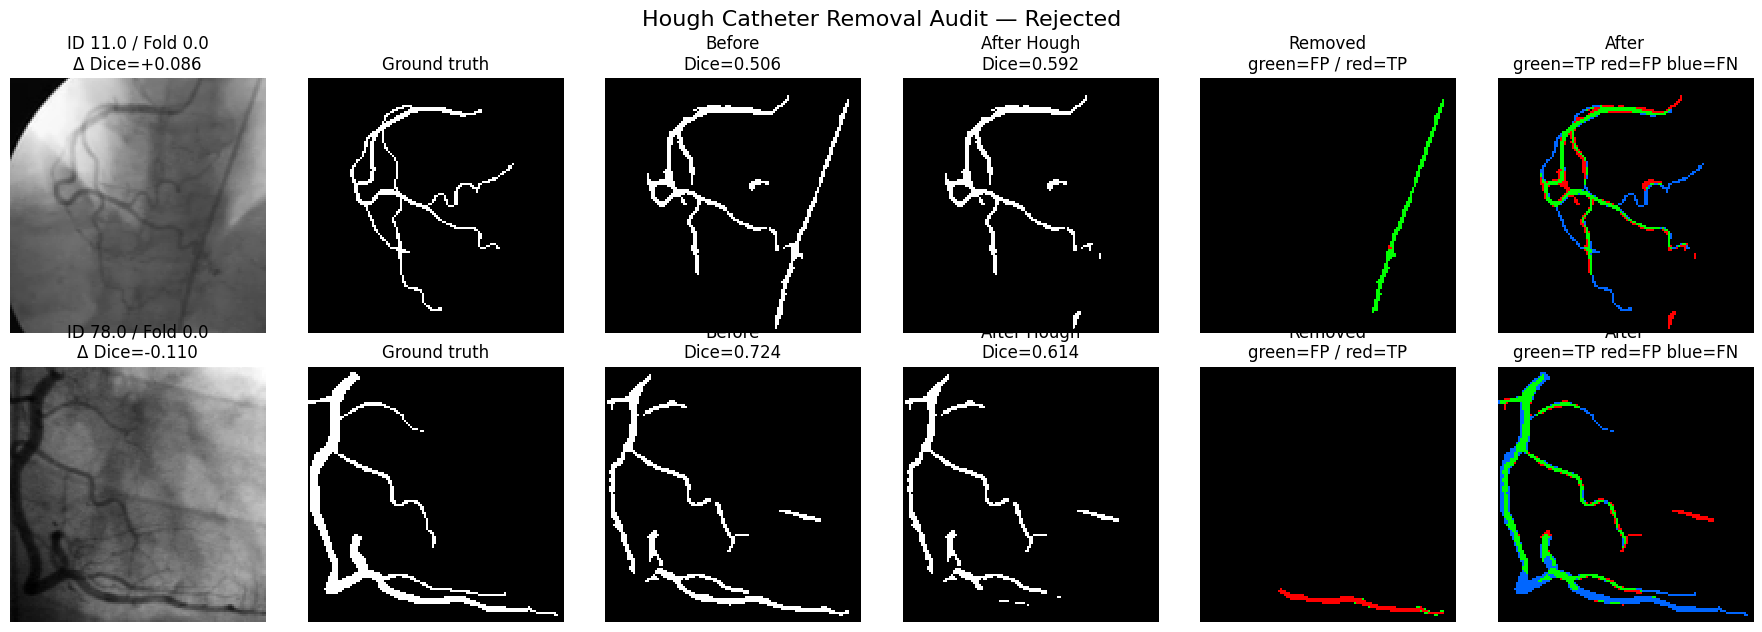


=== Hough 후처리 최종 판정 ===
❌ Hough catheter 제거 정책 기각
✅ 16px small-component 정책 유지
✅ Raw baseline 변경 없음

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/05_hough_best_candidate_visual_audit.png
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/06_hough_policy_rejected.json
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/07_hough_policy_decision_gate.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_5fold_raw/postprocessing_hough_ablation/08_hough_modified_image_audit.csv


In [ ]:
#@title Hough 최고 후보 시각 검증 및 정책 기각 저장

import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------
# 1. 가장 높은 pooled Dice 후보 선택
# ---------------------------------------------

best_hough_row = (
    summary_df
    .sort_values(
        "pooled_dice",
        ascending=False,
    )
    .iloc[0]
)

best_candidate_id = int(
    best_hough_row["candidate_id"]
)

best_config = {
    "min_line_length": int(
        best_hough_row["min_line_length"]
    ),
    "max_line_gap": int(
        best_hough_row["max_line_gap"]
    ),
    "removal_thickness": int(
        best_hough_row["removal_thickness"]
    ),
    "border_margin": int(
        best_hough_row["border_margin"]
    ),
    "hough_threshold": int(
        best_hough_row["hough_threshold"]
    ),
}

print("진단상 최고 Hough 후보:", best_candidate_id)
print("설정:", best_config)

# ---------------------------------------------
# 2. 최고 후보 재적용
# ---------------------------------------------

best_hough_masks = []
best_removed_masks = []
best_line_counts = []

for small_mask in small16_masks:
    (
        cleaned_mask,
        removed_mask,
        accepted_lines,
    ) = hough_device_removal(
        small_mask,
        **best_config,
    )

    best_hough_masks.append(cleaned_mask)
    best_removed_masks.append(removed_mask)
    best_line_counts.append(
        len(accepted_lines)
    )

best_hough_masks = np.stack(best_hough_masks)
best_removed_masks = np.stack(best_removed_masks)

best_hough_dice = np.asarray(
    [
        dice_score(pred, target)
        for pred, target
        in zip(best_hough_masks, targets)
    ]
)

dice_delta = (
    best_hough_dice
    - small16_dice
)

modified_indices = np.where(
    best_removed_masks.sum(axis=(1, 2)) > 0
)[0]

print("수정된 영상:", len(modified_indices))

modified_audit_df = pd.DataFrame(
    {
        "array_index": modified_indices,
        "sample_id": [
            oof_metric_df.iloc[index]["sample_id"]
            for index in modified_indices
        ],
        "cv_fold": [
            oof_metric_df.iloc[index]["cv_fold"]
            for index in modified_indices
        ],
        "small16_dice": (
            small16_dice[modified_indices]
        ),
        "hough_dice": (
            best_hough_dice[modified_indices]
        ),
        "dice_delta": (
            dice_delta[modified_indices]
        ),
        "removed_pixel_count": [
            int(best_removed_masks[index].sum())
            for index in modified_indices
        ],
        "accepted_line_count": [
            best_line_counts[index]
            for index in modified_indices
        ],
    }
).sort_values(
    "dice_delta",
    ascending=False,
)

display(modified_audit_df)

# ---------------------------------------------
# 3. 시각화
# ---------------------------------------------

images = np.asarray(
    oof_data["images_uint8"]
)

images = normalize_mask_stack(images)

row_count = max(
    len(modified_indices),
    1,
)

fig, axes = plt.subplots(
    row_count,
    6,
    figsize=(18, 3.2 * row_count),
)

if row_count == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, array_index in enumerate(
    modified_indices
):
    image = images[array_index]
    target = targets[array_index].astype(bool)
    before = small16_masks[
        array_index
    ].astype(bool)
    after = best_hough_masks[
        array_index
    ].astype(bool)
    removed = best_removed_masks[
        array_index
    ].astype(bool)

    corrected_fp = np.logical_and(
        removed,
        ~target,
    )
    harmed_tp = np.logical_and(
        removed,
        target,
    )

    removed_rgb = np.zeros(
        (*target.shape, 3),
        dtype=np.float32,
    )
    removed_rgb[
        corrected_fp
    ] = [0, 1, 0]
    removed_rgb[
        harmed_tp
    ] = [1, 0, 0]

    tp = np.logical_and(after, target)
    fp = np.logical_and(after, ~target)
    fn = np.logical_and(~after, target)

    error_rgb = np.zeros(
        (*target.shape, 3),
        dtype=np.float32,
    )
    error_rgb[tp] = [0, 1, 0]
    error_rgb[fp] = [1, 0, 0]
    error_rgb[fn] = [0, 0.4, 1]

    sample_id = (
        oof_metric_df.iloc[
            array_index
        ]["sample_id"]
    )
    fold = (
        oof_metric_df.iloc[
            array_index
        ]["cv_fold"]
    )

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
    )
    axes[row_index, 0].set_title(
        f"ID {sample_id} / Fold {fold}\n"
        f"Δ Dice={dice_delta[array_index]:+.3f}"
    )

    axes[row_index, 1].imshow(
        target,
        cmap="gray",
    )
    axes[row_index, 1].set_title("Ground truth")

    axes[row_index, 2].imshow(
        before,
        cmap="gray",
    )
    axes[row_index, 2].set_title(
        f"Before\nDice={small16_dice[array_index]:.3f}"
    )

    axes[row_index, 3].imshow(
        after,
        cmap="gray",
    )
    axes[row_index, 3].set_title(
        f"After Hough\nDice={best_hough_dice[array_index]:.3f}"
    )

    axes[row_index, 4].imshow(removed_rgb)
    axes[row_index, 4].set_title(
        "Removed\ngreen=FP / red=TP"
    )

    axes[row_index, 5].imshow(error_rgb)
    axes[row_index, 5].set_title(
        "After\ngreen=TP red=FP blue=FN"
    )

    for axis in axes[row_index]:
        axis.axis("off")

plt.suptitle(
    "Hough Catheter Removal Audit — Rejected",
    fontsize=16,
)
plt.tight_layout()

VISUAL_PATH = (
    HOUGH_DIR
    / "05_hough_best_candidate_visual_audit.png"
)

plt.savefig(
    VISUAL_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# ---------------------------------------------
# 4. 정책 기각 저장
# ---------------------------------------------

passed_candidate_count = int(
    (
        summary_df["safety_status"]
        == "PASS"
    ).sum()
)

decision = {
    "policy_name": "HOUGH_CATHETER_REMOVAL",
    "status": "REJECTED",
    "base_policy": (
        "threshold_0.5_then_remove_components_lt_16"
    ),
    "candidate_count": int(len(summary_df)),
    "passed_candidate_count": (
        passed_candidate_count
    ),
    "best_diagnostic_candidate_id": (
        best_candidate_id
    ),
    "best_candidate_config": best_config,
    "small16_pooled_dice": float(
        small16_pooled["pooled_dice"]
    ),
    "best_hough_pooled_dice": float(
        best_hough_row["pooled_dice"]
    ),
    "mean_dice_delta_vs_small16": float(
        best_hough_row[
            "mean_dice_delta_vs_small16"
        ]
    ),
    "paired_ci_95": [
        float(best_hough_row["paired_ci_lower"]),
        float(best_hough_row["paired_ci_upper"]),
    ],
    "worst_individual_delta": float(
        best_hough_row[
            "worst_individual_delta"
        ]
    ),
    "best_individual_delta": float(
        best_hough_row[
            "best_individual_delta"
        ]
    ),
    "reason": (
        "No candidate passed the predefined safety gate. "
        "The best candidate reduced pooled and macro Dice, "
        "and caused a clinically relevant worst-case loss "
        "by removing true vessel structures."
    ),
    "final_postprocessing_policy": (
        "Use fixed threshold 0.5 and remove connected "
        "components smaller than 16 pixels. "
        "Do not apply Hough removal."
    ),
    "raw_baseline_overwritten": False,
    "created_at": datetime.now().isoformat(),
}

DECISION_PATH = (
    HOUGH_DIR
    / "06_hough_policy_rejected.json"
)

GATE_PATH = (
    HOUGH_DIR
    / "07_hough_policy_decision_gate.csv"
)

MODIFIED_PATH = (
    HOUGH_DIR
    / "08_hough_modified_image_audit.csv"
)

with open(
    DECISION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        decision,
        file,
        ensure_ascii=False,
        indent=2,
    )

decision_gate_df = pd.DataFrame(
    [
        {
            "check": "safe_candidate_count",
            "observed": passed_candidate_count,
            "expected": 0,
            "status": (
                "PASS"
                if passed_candidate_count == 0
                else "REVIEW"
            ),
        },
        {
            "check": "best_hough_improves_pooled_dice",
            "observed": float(
                best_hough_row["pooled_dice"]
                - small16_pooled["pooled_dice"]
            ),
            "expected": "> 0",
            "status": "FAIL",
        },
        {
            "check": "paired_ci_lower_positive",
            "observed": float(
                best_hough_row["paired_ci_lower"]
            ),
            "expected": "> 0",
            "status": "FAIL",
        },
        {
            "check": "worst_individual_delta_safe",
            "observed": float(
                best_hough_row[
                    "worst_individual_delta"
                ]
            ),
            "expected": ">= -0.05",
            "status": "FAIL",
        },
        {
            "check": "final_decision",
            "observed": "HOUGH_REJECTED",
            "expected": "HOUGH_REJECTED",
            "status": "PASS",
        },
    ]
)

decision_gate_df.to_csv(
    GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

modified_audit_df.to_csv(
    MODIFIED_PATH,
    index=False,
    encoding="utf-8-sig",
)

# 결정 자체가 올바르게 저장됐는지 검사
assert decision["status"] == "REJECTED"
assert decision["raw_baseline_overwritten"] is False
assert (
    decision["best_hough_pooled_dice"]
    <= decision["small16_pooled_dice"]
)
assert decision["paired_ci_95"][0] <= 0

print("\n=== Hough 후처리 최종 판정 ===")
print("❌ Hough catheter 제거 정책 기각")
print("✅ 16px small-component 정책 유지")
print("✅ Raw baseline 변경 없음")
print("\n저장 완료:")
print(VISUAL_PATH)
print(DECISION_PATH)
print(GATE_PATH)
print(MODIFIED_PATH)